# Compare AI vs Human Research Proposals

This notebook implements the diversity analysis comparing AI-generated proposals against human-written proposals.

## Analysis Overview:
- **2.1.1**: Within-group pairwise diversity
- **2.1.2**: Centroid dispersion metric
- **2.1.3**: Nearest-neighbor outlier detection

Each analysis includes statistical tests (Mann-Whitney U, Cliff's delta, permutation tests) and visualizations.

# Setup and Imports

In [88]:
import sys
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# NLP and embeddings
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from scipy.spatial.distance import cdist
from tqdm import tqdm

# Statistics
from scipy import stats
from scipy.stats import mannwhitneyu
import itertools

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

# Visualization: 2D Embedding Space with UMAP
# Install umap-learn if not already installed
try:
    import umap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap

✓ Imports successful
✓ Working directory: /Users/eveyhuang/Documents/NICO/human-AI-proposal
✓ PyTorch version: 2.9.1
✓ CUDA available: False


## Helper Functions

In [89]:
# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-5': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

In [90]:
def retrieve_embeddings(path_to_embeddings):
    with open(path_to_embeddings, 'rb') as f:
        embeddings_data = pickle.load(f)
    return embeddings_data

In [91]:
def cliffs_delta(group1, group2):
    """
    Calculate Cliff's Delta effect size.
    
    Interpretation:
    - |δ| < 0.147: negligible
    - |δ| < 0.33: small
    - |δ| < 0.474: medium
    - |δ| ≥ 0.474: large
    """
    n1, n2 = len(group1), len(group2)
    
    # Count pairs where group1 > group2 and group1 < group2
    dominance = 0
    for x in group1:
        for y in group2:
            if x > y:
                dominance += 1
            elif x < y:
                dominance -= 1
    
    delta = dominance / (n1 * n2)
    return delta

def interpret_cliffs_delta(delta):
    """Interpret Cliff's Delta magnitude"""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    elif abs_delta < 0.33:
        return "small"
    elif abs_delta < 0.474:
        return "medium"
    else:
        return "large"

def permutation_test(group1, group2, n_permutations=10000, random_state=42):
    """
    Perform permutation test for difference in means.
    """
    np.random.seed(random_state)
    
    # Observed difference
    obs_diff = np.mean(group1) - np.mean(group2)
    
    # Combine groups
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    
    # Permutation distribution
    perm_diffs = []
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_group1 = combined[:n1]
        perm_group2 = combined[n1:]
        perm_diff = np.mean(perm_group1) - np.mean(perm_group2)
        perm_diffs.append(perm_diff)
    
    perm_diffs = np.array(perm_diffs)
    
    # Two-tailed p-value
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
    
    return p_value, obs_diff, perm_diffs

print("✓ Helper functions defined")

✓ Helper functions defined


## Load Data

In [92]:
# Load AI proposals
ai_proposals_path = Path('data/ai-proposals/baseline')
ai_files = sorted(ai_proposals_path.glob('ai_proposals_baseline_complete_*.csv'))

if not ai_files:
    raise FileNotFoundError("No AI proposal files found. Run gen_proposals.ipynb first.")

# Use the most recent file
ai_df = pd.read_csv(ai_files[-1])
print(f"✓ Loaded AI proposals from: {ai_files[-1].name}")
print(f"  Shape: {ai_df.shape}")
print(f"  Models: {ai_df['model'].value_counts().to_dict()}")

# Load human proposals
human_proposals_path = Path('data/human-proposals')
human_files = list(human_proposals_path.glob('*.json'))

human_proposals = []
for file in human_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        # Handle different JSON structures
        if isinstance(data, list):
            # Case 1: JSON is a flat list of proposals
            for proposal in data:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        elif 'proposals' in data:
            # Case 2: JSON has a 'proposals' key (most common structure)
            for proposal in data['proposals']:
                proposal['source_file'] = file.name
                human_proposals.append(proposal)
        else:
            # Case 3: JSON is a single proposal object
            data['source_file'] = file.name
            human_proposals.append(data)

human_df = pd.DataFrame(human_proposals)
print(f"\n✓ Loaded human proposals from {len(human_files)} files")
print(f"  Total proposals: {len(human_df)}")
print(f"  Source files: {human_df['source_file'].unique().tolist()}")

✓ Loaded AI proposals from: ai_proposals_baseline_complete_20260209_205423.csv
  Shape: (69, 10)
  Models: {'gpt-5.2': 23, 'gemini-3-pro-preview': 23, 'claude-opus-4-5': 23}

✓ Loaded human proposals from 2 files
  Total proposals: 23
  Source files: ['human-proposals-y1.json', 'human-proposals-y2.json']


## Prepare Proposal Texts

Combine all sections of proposals into full text for embedding.

In [93]:
def create_full_text(row, is_ai=True):
    """
    Create full proposal text from components.
    """
    if is_ai:
        # AI proposals structure
        sections = [
            f"Title: {row.get('title', '')}",
            f"Abstract: {row.get('abstract', '')}",
            f"Background: {row.get('background_and_significance', '')}",
            f"Research Questions: {row.get('research_questions_and_hypotheses', '')}",
            f"Methods: {row.get('methods_and_approach', '')}",
            f"Outcomes: {row.get('expected_outcomes_and_impact', '')}",
            f"Open Science: {row.get('open_science_and_reproducibility', '')}",
            f"Budget: {row.get('budget_and_resources', '')}"
        ]
    else:
        # Human proposals structure (based on actual JSON structure)
        sections = [
            f"Title: {row.get('proposal_title', row.get('title', ''))}",
            f"Abstract: {row.get('abstract', '')}",
            f"Full Proposal: {row.get('full_draft', row.get('full_text', row.get('full_proposal', '')))}"
        ]
    
    # Filter out empty sections and join
    text = " ".join([s for s in sections if s.split(': ', 1)[1].strip()])
    return text

# Create full texts
ai_df['full_text'] = ai_df.apply(lambda row: create_full_text(row, is_ai=True), axis=1)
human_df['full_text'] = human_df.apply(lambda row: create_full_text(row, is_ai=False), axis=1)

# Add group labels
ai_df['group'] = 'AI'
human_df['group'] = 'Human'

print(f"✓ Created full proposal texts")
print(f"  AI avg length: {ai_df['full_text'].str.len().mean():.0f} characters")
print(f"  Human avg length: {human_df['full_text'].str.len().mean():.0f} characters")

✓ Created full proposal texts
  AI avg length: 20276 characters
  Human avg length: 15009 characters


## Generate Embeddings with BioLinkBERT (ONLY RUN ONCE; retrieve saved embedding for repeated analysis)

Using **BioLinkBERT-large** (state-of-the-art biomedical model) with chunking to handle long proposals.

**Why BioLinkBERT?**
- Pretrained on PubMed with citation links
- State-of-the-art on biomedical NLP benchmarks
- Outperforms PubMedBERT on all tasks

**Why Chunking?**
- Proposals are ~15-20k characters (but BioLinkBERT max is 512 tokens ≈ 2.5k chars)
- Without chunking: only first 15% of proposal is embedded
- With chunking: 100% of proposal text is embedded and averaged

In [94]:
# Load BioLinkBERT model (state-of-the-art for biomedical tasks)
# BioLinkBERT was pretrained on PubMed with citation links
# Paper: https://arxiv.org/abs/2203.15827
# GitHub: https://github.com/michiyasunaga/LinkBERT
model_name = "michiyasunaga/BioLinkBERT-large"  # 340M params, best performance

print(f"Loading BioLinkBERT model: {model_name}")
print("Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks")
tokenizer = AutoTokenizer.from_pretrained(model_name)
# Use 'embedding_model' so loops like "for model in ai_models" don't overwrite it
embedding_model = AutoModel.from_pretrained(model_name)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
embedding_model = embedding_model.to(device)
embedding_model.eval()

print(f"✓ Model loaded on: {device}")
print(f"✓ Model parameters: {sum(p.numel() for p in embedding_model.parameters()):,}")

Loading BioLinkBERT model: michiyasunaga/BioLinkBERT-large
Note: BioLinkBERT outperforms PubMedBERT on all biomedical benchmarks


tokenizer_config.json:   0%|          | 0.00/379 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [ ]:
def get_embeddings_with_chunking(texts, chunk_size=400, overlap=50, batch_size=8):
    """
    Generate embeddings for long texts using chunking approach.
    
    This handles proposals that are longer than the 512 token limit by:
    1. Splitting each proposal into overlapping chunks (~400 words each)
    2. Embedding each chunk with BioLinkBERT
    3. Averaging chunk embeddings to get one embedding per proposal
    
    This ensures we use 100% of the proposal text, not just the first 15%.
    
    Args:
        texts: List of text strings (full proposals)
        chunk_size: Number of words per chunk (default: 400 ≈ 500 tokens)
        overlap: Number of overlapping words between chunks (default: 50)
        batch_size: Batch size for processing chunks
    
    Returns:
        numpy array of embeddings (shape: [n_texts, embedding_dim])
    """
    from tqdm import tqdm
    all_doc_embeddings = []
    
    for text in tqdm(texts, desc="Embedding proposals"):
        # Split text into words
        words = text.split()
        
        # Create overlapping chunks
        chunks = []
        for i in range(0, len(words), chunk_size - overlap):
            chunk_words = words[i:i + chunk_size]
            if len(chunk_words) > 10:  # Skip very small chunks
                chunks.append(' '.join(chunk_words))
        
        if not chunks:  # Handle empty text
            chunks = [text if text else "empty"]
        
        # Embed each chunk in batches
        chunk_embeddings = []
        with torch.no_grad():
            for j in range(0, len(chunks), batch_size):
                batch_chunks = chunks[j:j+batch_size]
                
                # Tokenize
                encoded = tokenizer(
                    batch_chunks,
                    padding=True,
                    truncation=True,
                    max_length=512,
                    return_tensors='pt'
                ).to(device)
                
                # Get embeddings
                outputs = embedding_model(**encoded)
                
                # Use [CLS] token embedding (first token)
                cls_embeddings = outputs.last_hidden_state[:, 0, :]
                chunk_embeddings.append(cls_embeddings.cpu().numpy())
        
        # Average all chunk embeddings for this document
        all_chunk_embeds = np.vstack(chunk_embeddings)
        doc_embedding = all_chunk_embeds.mean(axis=0)
        all_doc_embeddings.append(doc_embedding)
    
    return np.vstack(all_doc_embeddings)

print("✓ Chunked embedding function defined")
print("  Splits each proposal into ~400-word chunks with 50-word overlap")
print("  Embeds each chunk, then averages to get one embedding per proposal")
print("  This uses 100% of proposal text instead of just 15%!")

✓ Chunked embedding function defined
  Splits each proposal into ~400-word chunks with 50-word overlap
  Embeds each chunk, then averages to get one embedding per proposal
  This uses 100% of proposal text instead of just 15%!


In [ ]:
# Generate embeddings using chunking approach
print("="*70)
print("GENERATING EMBEDDINGS WITH BIOLINKBERT + CHUNKING")
print("="*70)
print(f"Proposals are ~{ai_df['full_text'].str.len().mean():.0f} chars (AI) and ~{human_df['full_text'].str.len().mean():.0f} chars (human)")
print("Chunking ensures we use 100% of text, not just first 15%")
print()

# Generate embeddings for AI proposals
print("Embedding AI proposals (this may take a few minutes)...")
ai_embeddings = get_embeddings_with_chunking(ai_df['full_text'].tolist())
print(f"✓ AI embeddings shape: {ai_embeddings.shape}")

# Generate embeddings for human proposals
print("\nEmbedding human proposals...")
human_embeddings = get_embeddings_with_chunking(human_df['full_text'].tolist())
print(f"✓ Human embeddings shape: {human_embeddings.shape}")

print("\n✓ All embeddings generated successfully!")
print("="*70)

GENERATING EMBEDDINGS WITH BIOLINKBERT + CHUNKING
Proposals are ~20276 chars (AI) and ~15009 chars (human)
Chunking ensures we use 100% of text, not just first 15%

Embedding AI proposals (this may take a few minutes)...


Embedding proposals: 100%|██████████| 69/69 [04:04<00:00,  3.54s/it]


✓ AI embeddings shape: (69, 1024)

Embedding human proposals...


Embedding proposals: 100%|██████████| 23/23 [01:08<00:00,  2.99s/it]

✓ Human embeddings shape: (23, 1024)

✓ All embeddings generated successfully!


## Save Embeddings

Save embeddings for easy access in future analyses.

In [ ]:
# Create output directory
embeddings_dir = Path('data/embeddings')
embeddings_dir.mkdir(parents=True, exist_ok=True)

# Save embeddings with timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

embeddings_data = {
    'ai_embeddings': ai_embeddings,
    'human_embeddings': human_embeddings,
    'ai_metadata': ai_df[['model', 'title', 'group']].to_dict('records'),
    'human_metadata': human_df[['proposal_title', 'group', 'source_file']].to_dict('records'),
    'model_name': model_name,
    'timestamp': timestamp
}

embeddings_file = embeddings_dir / f'proposal_embeddings_{timestamp}.pkl'
with open(embeddings_file, 'wb') as f:
    pickle.dump(embeddings_data, f)

print(f"✓ Saved embeddings to: {embeddings_file}")
print(f"  File size: {embeddings_file.stat().st_size / 1024 / 1024:.2f} MB")

✓ Saved embeddings to: data/embeddings/proposal_embeddings_20260210_113543.pkl
  File size: 0.37 MB


## Retrieve saved embeddings

In [ ]:
# embeddings_data = retrieve_embeddings('/Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/full_proposals/proposal_embeddings_human_ai_baseline.pkl')

# ai_embeddings = embeddings_data['ai_embeddings']
# human_embeddings = embeddings_data['human_embeddings']
# ai_metadata = embeddings_data['ai_metadata']
# human_metadata = embeddings_data['human_metadata']



# PART I: DIVERSITY

---

## Analysis 1.1: Within-Group Pairwise Diversity

Compare pairwise cosine distances within each group:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**

This analysis reveals which AI models produce more diverse proposals and how each compares to human diversity.

In [ ]:
def compute_pairwise_distances(embeddings):
    """
    Compute pairwise cosine distances within a group.
    Returns upper triangle (excluding diagonal) as 1D array.
    """
    # Cosine distance matrix
    dist_matrix = cosine_distances(embeddings)
    
    # Extract upper triangle (excluding diagonal)
    n = len(embeddings)
    indices = np.triu_indices(n, k=1)
    pairwise_dists = dist_matrix[indices]
    
    return pairwise_dists

# Compute pairwise distances for all groups
print("="*85)
print("COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS")
print("="*85)

# Overall groups
ai_pairwise = compute_pairwise_distances(ai_embeddings)
human_pairwise = compute_pairwise_distances(human_embeddings)

# Individual AI models - split by model
ai_models = sorted(ai_df['model'].unique())
model_pairwise = {}
model_embeddings_dict = {}

for model in ai_models:
    model_mask = ai_df['model'] == model
    model_embeds = ai_embeddings[model_mask]
    model_embeddings_dict[model] = model_embeds
    
    if len(model_embeds) > 1:  # Need at least 2 proposals for pairwise comparison
        model_pairwise[model] = compute_pairwise_distances(model_embeds)
    else:
        model_pairwise[model] = np.array([])

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Pairs':<10} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-"*85)

# Human baseline
print(f"{'Human':<35} {len(human_embeddings):<8} {len(human_pairwise):<10} {human_pairwise.mean():<10.4f} {np.median(human_pairwise):<10.4f} {human_pairwise.std():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        n_proposals = len(model_embeddings_dict[model])
        n_pairs = len(model_pairwise[model])
        mean_dist = model_pairwise[model].mean()
        median_dist = np.median(model_pairwise[model])
        std_dist = model_pairwise[model].std()
        print(f"{model:<35} {n_proposals:<8} {n_pairs:<10} {mean_dist:<10.4f} {median_dist:<10.4f} {std_dist:<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {len(ai_pairwise):<10} {ai_pairwise.mean():<10.4f} {np.median(ai_pairwise):<10.4f} {ai_pairwise.std():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - MEAN: Average distance (affected by outliers)")
print("   - MEDIAN: Typical distance (robust to outliers)")
print("   - Higher median = more consistently diverse proposals")
print("   - Mean > Median = distribution has high outliers")
print("\n💡 INTERPRETATION:")
print("   - Higher mean distance = more diverse proposals within group")
print("   - Compare each AI model to Human to see which produces human-like diversity")
print("="*85)
print("\n💡 INTERPRETATION:")
print("   - MEAN: Average distance (affected by outliers)")
print("   - MEDIAN: Typical distance (robust to outliers)")
print("   - Higher median = more consistently diverse proposals")
print("   - Mean > Median = distribution has high outliers")

COMPUTING PAIRWISE DISTANCES FOR ALL GROUPS

GROUP                               N        Pairs      Mean       Median     Std       
-------------------------------------------------------------------------------------
Human                               23       253        0.0661     0.0639     0.0175    

claude-opus-4-5                     23       253        0.3401     0.0724     0.3341    
gemini-3-pro-preview                23       253        0.0964     0.0372     0.1964    
gpt-5.2                             23       253        0.0215     0.0213     0.0047    

All AI (combined)                   69       2346       0.1733     0.0495     0.2664    

💡 INTERPRETATION:
   - MEAN: Average distance (affected by outliers)
   - MEDIAN: Typical distance (robust to outliers)
   - Higher median = more consistently diverse proposals
   - Mean > Median = distribution has high outliers

💡 INTERPRETATION:
   - Higher mean distance = more diverse proposals within group
   - Compare each AI

In [ ]:
# DIAGNOSTIC: Verify pairwise distance calculations and Cliff's Delta
print("="*85)
print("DIAGNOSTIC CHECK: Pairwise Distances and Statistical Tests")
print("="*85)

# Show actual mean values
print("\n1. ACTUAL MEAN PAIRWISE DISTANCES:")
print("-"*85)
print(f"Human:                         {human_pairwise.mean():.6f}")
for model in ai_models:
    if model in model_pairwise and len(model_pairwise[model]) > 0:
        print(f"{model:<30} {model_pairwise[model].mean():.6f}")
print(f"All AI (combined):             {ai_pairwise.mean():.6f}")

# Manually verify Cliff's Delta calculation for gemini
print("\n2. MANUAL CLIFF'S DELTA VERIFICATION (gemini vs human):")
print("-"*85)
if 'gemini-3-pro-preview' in model_pairwise:
    gemini_dist = model_pairwise['gemini-3-pro-preview']
    
    # Calculate Cliff's Delta manually
    n1, n2 = len(gemini_dist), len(human_pairwise)
    dominance = 0
    for x in gemini_dist:
        for y in human_pairwise:
            if x > y:
                dominance += 1
            elif x < y:
                dominance -= 1
    
    delta_manual = dominance / (n1 * n2)
    
    print(f"Gemini pairwise distances: n={len(gemini_dist)}, mean={gemini_dist.mean():.6f}")
    print(f"Human pairwise distances:  n={len(human_pairwise)}, mean={human_pairwise.mean():.6f}")
    print(f"\nDifference in means: {gemini_dist.mean() - human_pairwise.mean():.6f}")
    print(f"Cliff's Delta (manual calculation): {delta_manual:.4f}")
    print(f"\nInterpretation:")
    if delta_manual > 0:
        print(f"  → Positive δ means Gemini values tend to be HIGHER than Human")
        print(f"  → Gemini proposals are MORE diverse")
    else:
        print(f"  → Negative δ means Human values tend to be HIGHER than Gemini")
        print(f"  → Human proposals are MORE diverse")
    
    # Show distribution statistics
    print(f"\n3. DISTRIBUTION DETAILS:")
    print("-"*85)
    print(f"Gemini: min={gemini_dist.min():.6f}, max={gemini_dist.max():.6f}, "
          f"q25={np.percentile(gemini_dist, 25):.6f}, q75={np.percentile(gemini_dist, 75):.6f}")
    print(f"Human:  min={human_pairwise.min():.6f}, max={human_pairwise.max():.6f}, "
          f"q25={np.percentile(human_pairwise, 25):.6f}, q75={np.percentile(human_pairwise, 75):.6f}")
    
    # Count how many pairs fall into different ranges
    print(f"\n4. DISTRIBUTION OVERLAP:")
    print("-"*85)
    gemini_above_human_mean = (gemini_dist > human_pairwise.mean()).sum()
    human_above_gemini_mean = (human_pairwise > gemini_dist.mean()).sum()
    print(f"Gemini pairs above human mean: {gemini_above_human_mean}/{len(gemini_dist)} ({gemini_above_human_mean/len(gemini_dist)*100:.1f}%)")
    print(f"Human pairs above gemini mean: {human_above_gemini_mean}/{len(human_pairwise)} ({human_above_gemini_mean/len(human_pairwise)*100:.1f}%)")
    
print("\n" + "="*85)
print("KEY INSIGHT:")
print("Cliff's Delta looks at ALL pairwise comparisons, not just means.")
print("A negative δ means the MAJORITY of individual comparisons favor the second group.")
print("="*85)

print("\n" + "="*85)
print("EXPLANATION OF THE PARADOX:")
print("="*85)
if "gemini-3-pro-preview" in model_pairwise:
    gemini_dist = model_pairwise["gemini-3-pro-preview"]
    print(f"\nGemini mean ({gemini_dist.mean():.4f}) > Human mean ({human_pairwise.mean():.4f})")
    print(f"BUT Gemini median ({np.median(gemini_dist):.4f}) < Human median ({np.median(human_pairwise):.4f})")
    print(f"\nThis means:")
    print(f"  ✓ Gemini has extreme outliers (max={gemini_dist.max():.3f}) pulling mean UP")
    print(f"  ✓ But MOST Gemini pairs have LOW distances (Q75={np.percentile(gemini_dist, 75):.3f})")
    print(f"  ✓ Human pairs are more CONSISTENTLY diverse (Q25-Q75: {np.percentile(human_pairwise, 25):.3f}-{np.percentile(human_pairwise, 75):.3f})")
    print(f"\n  → Cliffs Delta correctly identifies that TYPICAL Gemini pairs are less diverse")
    print(f"  → The few outliers do not represent typical diversity")
print("="*85)

print("\n" + "="*85)
print("EXPLANATION OF THE PARADOX:")
print("="*85)
if "gemini-3-pro-preview" in model_pairwise:
    gemini_dist = model_pairwise["gemini-3-pro-preview"]
    print(f"\nGemini mean ({gemini_dist.mean():.4f}) > Human mean ({human_pairwise.mean():.4f})")
    print(f"BUT Gemini median ({np.median(gemini_dist):.4f}) < Human median ({np.median(human_pairwise):.4f})")
    print(f"\nThis means:")
    print(f"  ✓ Gemini has extreme outliers (max={gemini_dist.max():.3f}) pulling mean UP")
    print(f"  ✓ But MOST Gemini pairs have LOW distances (Q75={np.percentile(gemini_dist, 75):.3f})")
    print(f"  ✓ Human pairs are more CONSISTENTLY diverse (Q25-Q75: {np.percentile(human_pairwise, 25):.3f}-{np.percentile(human_pairwise, 75):.3f})")
    print(f"\n  → Cliffs Delta correctly identifies that TYPICAL Gemini pairs are less diverse")
    print(f"  → The few outliers do not represent typical diversity")
print("="*85)


DIAGNOSTIC CHECK: Pairwise Distances and Statistical Tests

1. ACTUAL MEAN PAIRWISE DISTANCES:
-------------------------------------------------------------------------------------
Human:                         0.066062
claude-opus-4-5                0.340114
gemini-3-pro-preview           0.096440
gpt-5.2                        0.021549
All AI (combined):             0.173280

2. MANUAL CLIFF'S DELTA VERIFICATION (gemini vs human):
-------------------------------------------------------------------------------------
Gemini pairwise distances: n=253, mean=0.096440
Human pairwise distances:  n=253, mean=0.066062

Difference in means: 0.030377
Cliff's Delta (manual calculation): -0.7256

Interpretation:
  → Negative δ means Human values tend to be HIGHER than Gemini
  → Human proposals are MORE diverse

3. DISTRIBUTION DETAILS:
-------------------------------------------------------------------------------------
Gemini: min=0.014817, max=0.773963, q25=0.029260, q75=0.046637
Human:  min=

In [ ]:
# Statistical tests - Compare each group to Human
print("\n" + "="*85)
print("STATISTICAL TESTS: Pairwise Diversity (All Groups vs Human)")
print("="*85)

# Store all results
comparison_results = []

# Compare All AI vs Human
print("\n" + "-"*85)
print("Comparison: All AI (combined) vs Human")
print("-"*85)

u_stat, p_value_mw = mannwhitneyu(ai_pairwise, human_pairwise, alternative='two-sided')
delta = cliffs_delta(ai_pairwise, human_pairwise)
delta_interp = interpret_cliffs_delta(delta)
p_value_perm, obs_diff, perm_diffs = permutation_test(ai_pairwise, human_pairwise)

print(f"\nMann-Whitney U Test:")
print(f"  U-statistic: {u_stat:,.0f}, p-value: {p_value_mw:.4e}")
print(f"\nCliff's Delta:")
print(f"  δ = {delta:.4f} ({delta_interp} effect)")
if delta > 0:
    print(f"  → All AI proposals are MORE diverse than human proposals")
else:
    print(f"  → Human proposals are MORE diverse than all AI proposals")
print(f"\nPermutation Test (10,000 permutations):")
print(f"  Observed difference: {obs_diff:.4f}, p-value: {p_value_perm:.4f}")

comparison_results.append({
    'group': 'All AI',
    'u_stat': u_stat,
    'p_value_mw': p_value_mw,
    'delta': delta,
    'delta_interp': delta_interp,
    'p_value_perm': p_value_perm
})

# Compare each individual AI model vs Human
for model in ai_models:
    if len(model_pairwise[model]) > 0:
        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human")
        print("-"*85)
        
        u_stat_model, p_value_mw_model = mannwhitneyu(model_pairwise[model], human_pairwise, alternative='two-sided')
        delta_model = cliffs_delta(model_pairwise[model], human_pairwise)
        delta_interp_model = interpret_cliffs_delta(delta_model)
        p_value_perm_model, obs_diff_model, _ = permutation_test(model_pairwise[model], human_pairwise)
        
        print(f"\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
        print(f"\nCliff's Delta:")
        print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
        if delta_model > 0:
            print(f"  → {model} proposals are MORE diverse than human proposals")
        else:
            print(f"  → Human proposals are MORE diverse than {model} proposals")
        print(f"\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")
        
        comparison_results.append({
            'group': model,
            'u_stat': u_stat_model,
            'p_value_mw': p_value_mw_model,
            'delta': delta_model,
            'delta_interp': delta_interp_model,
            'p_value_perm': p_value_perm_model
        })

# Summary table
print("\n" + "="*85)
print("SUMMARY: Effect Sizes (Cliff's Delta) - All Groups vs Human")
print("="*85)
print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
print("-"*85)
for result in comparison_results:
    print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
print("="*85)
print("\nIMPORTANT NOTE:")
print("  Cliff's Delta measures TYPICAL diversity (distribution-based), not mean.")
print("  A group can have higher mean due to outliers but lower typical diversity.")
print("  Check both mean AND median in the summary table above.")
print("\nIMPORTANT NOTE:")
print("  Cliffs Delta measures TYPICAL diversity (distribution-based), not mean.")
print("  A group can have higher mean due to outliers but lower typical diversity.")
print("  Check both mean AND median in the summary table above.")

print("\n💡 Positive δ = AI more diverse; Negative δ = Human more diverse")
print("="*85)



STATISTICAL TESTS: Pairwise Diversity (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 210,665, p-value: 3.1313e-14

Cliff's Delta:
  δ = -0.2901 (small effect)
  → Human proposals are MORE diverse than all AI proposals

Permutation Test (10,000 permutations):
  Observed difference: 0.1072, p-value: 0.0000

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 39,951, p-value: 1.3526e-06

Cliff's Delta:
  δ = 0.2483 (small effect)
  → claude-opus-4-5 proposals are MORE diverse than human proposals

Permutation Test (10,000 permutations):
  Observed difference: 0.2741, p-value: 0

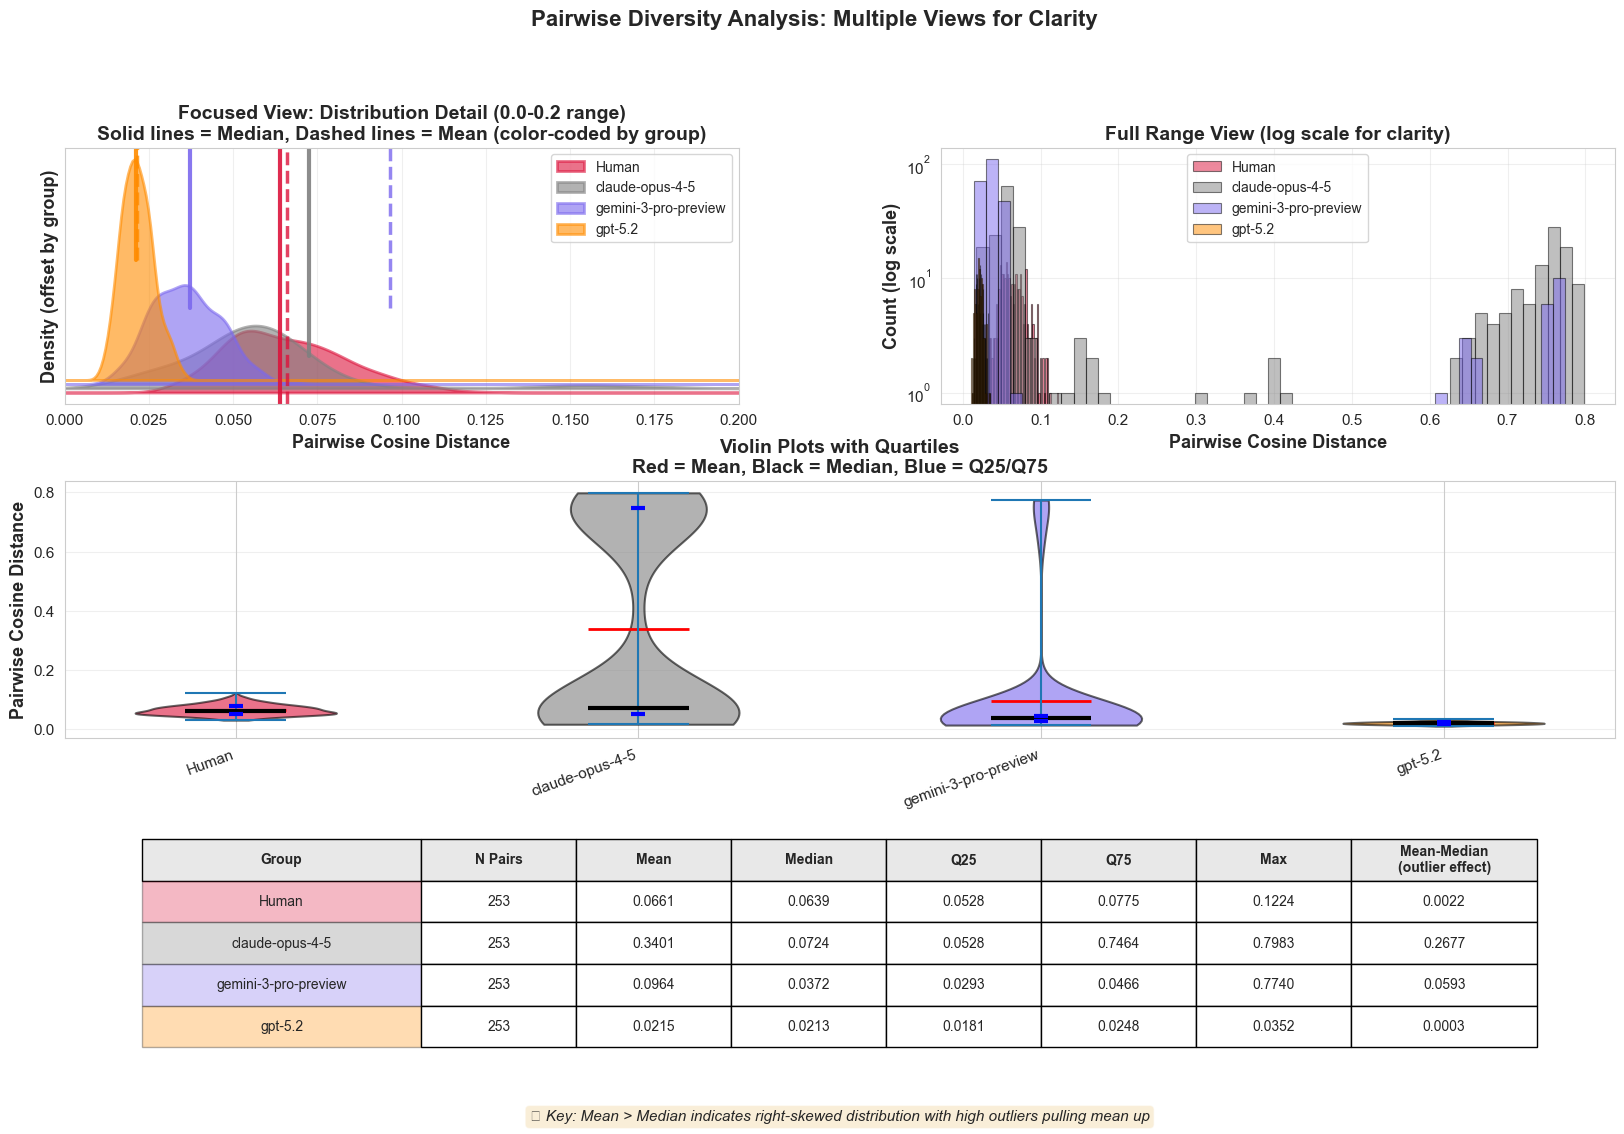

✓ Figure saved to: results/figures/pairwise_diversity_by_model.png

📊 Visualization improvements:
  1. Ridge plot with FOCUSED 0.0-0.2 range (where 90%+ of data is)
  2. Distinct colors: RED (Human - prominent!), Blue (Claude), Purple (Gemini), Orange (GPT)
  3. Log-scale histogram for full range context
  4. Violin plots with quartile markers
  5. Statistical summary table highlighting mean-median differences


In [ ]:
# Visualization: Improved distribution comparison for all groups
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Create a 2x2 grid for better readability
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Define DISTINCT colors for each group
colors = {
    'Human': '#DC143C',  # Crimson red (PROMINENT)
    'claude-opus-4-6': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

group_order = ['Human'] + [m for m in ai_models if len(model_pairwise[m]) > 0]

# PANEL 1 (Top Left): Ridge plot / Stacked distributions - FOCUSED VIEW (0.0-0.2)
ax1 = fig.add_subplot(gs[0, 0])
offset = 0
max_density = 0

for idx, group in enumerate(group_order):
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    # Only plot data in 0.0-0.2 range for clarity
    data_filtered = data[data <= 0.2]
    
    # Create density
    from scipy.stats import gaussian_kde
    if len(data_filtered) > 1:
        kde = gaussian_kde(data_filtered)
        x_range = np.linspace(0, 0.2, 300)
        density = kde(x_range)
        max_density = max(max_density, density.max())
        
        # Plot filled curve with offset
        ax1.fill_between(x_range, offset + density, offset, 
                         color=colors.get(group, 'gray'), alpha=0.6, 
                         edgecolor=colors.get(group, 'gray'), linewidth=2, label=group)
        
        # Add median line (solid, in group color)
        median_val = np.median(data)
        if median_val <= 0.2:
            ax1.axvline(median_val, ymin=offset/(len(group_order)*2), 
                       ymax=(offset + density.max())/(len(group_order)*2),
                       color=colors.get(group, 'gray'), linestyle='-', linewidth=3, alpha=0.9)
        
        # Add mean line (dashed, in group color)
        mean_val = data.mean()
        if mean_val <= 0.2:
            ax1.axvline(mean_val, ymin=offset/(len(group_order)*2), 
                       ymax=(offset + density.max())/(len(group_order)*2),
                       color=colors.get(group, 'gray'), linestyle='--', linewidth=2.5, alpha=0.8)
        
        offset += 1.5

ax1.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax1.set_ylabel('Density (offset by group)', fontsize=13, fontweight='bold')
ax1.set_title('Focused View: Distribution Detail (0.0-0.2 range)\nSolid lines = Median, Dashed lines = Mean (color-coded by group)', 
              fontsize=14, fontweight='bold')
ax1.set_xlim(0, 0.2)
ax1.set_yticks([])
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(alpha=0.3, axis='x')

# PANEL 2 (Top Right): Full range view with log scale on y-axis
ax2 = fig.add_subplot(gs[0, 1])
for group in group_order:
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    ax2.hist(data, bins=50, alpha=0.5, label=group, 
            color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)

ax2.set_xlabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Full Range View (log scale for clarity)', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# PANEL 3 (Middle): Violin plots with quartile annotations
ax3 = fig.add_subplot(gs[1, :])

box_data = []
for dist, label in [(human_pairwise, 'Human')] + [(model_pairwise[m], m) for m in ai_models if len(model_pairwise[m]) > 0]:
    for val in dist:
        box_data.append({'Distance': val, 'Group': label})

box_df = pd.DataFrame(box_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

# Create violin plot
parts = ax3.violinplot([box_df[box_df['Group']==g]['Distance'].values for g in group_order],
                       positions=range(len(group_order)),
                       showmeans=True, showmedians=True, showextrema=True)

# Color the violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Enhance median and mean lines
parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

# Add quartile markers
for idx, group in enumerate(group_order):
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    q25, q75 = np.percentile(data, [25, 75])
    ax3.scatter([idx, idx], [q25, q75], color='blue', s=100, zorder=3, marker='_', linewidths=3)

ax3.set_xticks(range(len(group_order)))
ax3.set_xticklabels(group_order, fontsize=11, rotation=20, ha='right')
ax3.set_ylabel('Pairwise Cosine Distance', fontsize=13, fontweight='bold')
ax3.set_title('Violin Plots with Quartiles\nRed = Mean, Black = Median, Blue = Q25/Q75', 
              fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3, axis='y')

# PANEL 4 (Bottom): Statistical summary table
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

# Create summary statistics
summary_data = []
for group in group_order:
    if group == 'Human':
        data = human_pairwise
    else:
        data = model_pairwise[group]
    
    summary_data.append([
        group,
        f"{len(data)}",
        f"{data.mean():.4f}",
        f"{np.median(data):.4f}",
        f"{np.percentile(data, 25):.4f}",
        f"{np.percentile(data, 75):.4f}",
        f"{data.max():.4f}",
        f"{data.mean() - np.median(data):.4f}"
    ])

# Create table
table = ax4.table(cellText=summary_data,
                 colLabels=['Group', 'N Pairs', 'Mean', 'Median', 'Q25', 'Q75', 'Max', 'Mean-Median\n(outlier effect)'],
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.18, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.12])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color code the header
for i in range(8):
    table[(0, i)].set_facecolor('#E8E8E8')
    table[(0, i)].set_text_props(weight='bold')

# Color code the groups
for i, group in enumerate(group_order):
    table[(i+1, 0)].set_facecolor(colors.get(group, 'gray'))
    table[(i+1, 0)].set_alpha(0.3)

ax4.text(0.5, -0.15, 
         '💡 Key: Mean > Median indicates right-skewed distribution with high outliers pulling mean up',
         ha='center', va='top', transform=ax4.transAxes, fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Pairwise Diversity Analysis: Multiple Views for Clarity', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('results/figures/pairwise_diversity_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/pairwise_diversity_by_model.png")
print("\n📊 Visualization improvements:")
print("  1. Ridge plot with FOCUSED 0.0-0.2 range (where 90%+ of data is)")
print("  2. Distinct colors: RED (Human - prominent!), Blue (Claude), Purple (Gemini), Orange (GPT)")
print("  3. Log-scale histogram for full range context")
print("  4. Violin plots with quartile markers")
print("  5. Statistical summary table highlighting mean-median differences")


---

## Analysis 1.2: Centroid Dispersion Metric

Measure how scattered proposals are from their group center.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [ ]:
def compute_centroid_distances(embeddings):
    """
    Compute distances from each proposal to its group centroid.
    """
    # Compute centroid (mean embedding)
    centroid = embeddings.mean(axis=0, keepdims=True)
    
    # Compute cosine distances to centroid
    distances = cosine_distances(embeddings, centroid).flatten()
    
    return distances, centroid

# Compute centroid distances for all groups
print("="*85)
print("COMPUTING CENTROID DISPERSION FOR ALL GROUPS")
print("="*85)

# Overall groups
ai_centroid_dists, ai_centroid = compute_centroid_distances(ai_embeddings)
human_centroid_dists, human_centroid = compute_centroid_distances(human_embeddings)

# Individual AI models
model_centroid_dists = {}
model_centroids = {}

for model in ai_models:
    if len(model_embeddings_dict[model]) > 0:
        dists, centroid = compute_centroid_distances(model_embeddings_dict[model])
        model_centroid_dists[model] = dists
        model_centroids[model] = centroid

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Std':<10} {'Variance':<10}")
print("-"*90)

# Human baseline
print(f"{'Human':<35} {len(human_embeddings):<8} {human_centroid_dists.mean():<10.4f} {np.median(human_centroid_dists):<10.4f} {human_centroid_dists.std():<10.4f} {human_centroid_dists.var():<10.4f}")

print()  # Blank line separator

# Individual AI models
for model in ai_models:
    if model in model_centroid_dists:
        dists = model_centroid_dists[model]
        n_proposals = len(model_embeddings_dict[model])
        print(f"{model:<35} {n_proposals:<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.std():<10.4f} {dists.var():<10.4f}")

print()  # Blank line separator

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_embeddings):<8} {ai_centroid_dists.mean():<10.4f} {np.median(ai_centroid_dists):<10.4f} {ai_centroid_dists.std():<10.4f} {ai_centroid_dists.var():<10.4f}")

print("="*90)
print("\n💡 INTERPRETATION:")
print("   - Higher variance = more dispersed proposals (higher diversity)")
print("   - Lower variance = proposals cluster tightly around center")
print("="*90)


COMPUTING CENTROID DISPERSION FOR ALL GROUPS

GROUP                               N        Mean       Median     Std        Variance  
------------------------------------------------------------------------------------------
Human                               23       0.0321     0.0294     0.0092     0.0001    

claude-opus-4-5                     23       0.1789     0.0736     0.1845     0.0340    
gemini-3-pro-preview                23       0.0473     0.0178     0.1348     0.0182    
gpt-5.2                             23       0.0104     0.0101     0.0023     0.0000    

All AI (combined)                   69       0.0894     0.0268     0.1836     0.0337    

💡 INTERPRETATION:
   - Higher variance = more dispersed proposals (higher diversity)
   - Lower variance = proposals cluster tightly around center


In [ ]:
# Statistical tests - Compare each group to Human
print("\n" + "="*85)
print("STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)")
print("="*85)

# Store all results
centroid_comparison_results = []

# Compare All AI vs Human
print("\n" + "-"*85)
print("Comparison: All AI (combined) vs Human")
print("-"*85)

u_stat_cent, p_value_cent = mannwhitneyu(ai_centroid_dists, human_centroid_dists, alternative='two-sided')
delta_cent = cliffs_delta(ai_centroid_dists, human_centroid_dists)
delta_cent_interp = interpret_cliffs_delta(delta_cent)
p_value_perm_cent, obs_diff_cent, _ = permutation_test(ai_centroid_dists, human_centroid_dists)

print(f"\nMann-Whitney U Test:")
print(f"  U-statistic: {u_stat_cent:,.0f}, p-value: {p_value_cent:.4e}")
print(f"\nCliff's Delta:")
print(f"  δ = {delta_cent:.4f} ({delta_cent_interp} effect)")
if delta_cent > 0:
    print(f"  → All AI proposals are MORE dispersed from center")
else:
    print(f"  → Human proposals are MORE dispersed from center")
print(f"\nPermutation Test (10,000 permutations):")
print(f"  Observed difference: {obs_diff_cent:.4f}, p-value: {p_value_perm_cent:.4f}")

centroid_comparison_results.append({
    'group': 'All AI',
    'u_stat': u_stat_cent,
    'p_value_mw': p_value_cent,
    'delta': delta_cent,
    'delta_interp': delta_cent_interp,
    'p_value_perm': p_value_perm_cent
})

# Compare each individual AI model vs Human
for model in ai_models:
    if model in model_centroid_dists:
        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human")
        print("-"*85)
        
        u_stat_model, p_value_mw_model = mannwhitneyu(model_centroid_dists[model], human_centroid_dists, alternative='two-sided')
        delta_model = cliffs_delta(model_centroid_dists[model], human_centroid_dists)
        delta_interp_model = interpret_cliffs_delta(delta_model)
        p_value_perm_model, obs_diff_model, _ = permutation_test(model_centroid_dists[model], human_centroid_dists)
        
        print(f"\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
        print(f"\nCliff's Delta:")
        print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
        if delta_model > 0:
            print(f"  → {model} proposals are MORE dispersed from center")
        else:
            print(f"  → Human proposals are MORE dispersed from center")
        print(f"\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")
        
        centroid_comparison_results.append({
            'group': model,
            'u_stat': u_stat_model,
            'p_value_mw': p_value_mw_model,
            'delta': delta_model,
            'delta_interp': delta_interp_model,
            'p_value_perm': p_value_perm_model
        })

# Summary table
print("\n" + "="*85)
print("SUMMARY: Effect Sizes (Cliff's Delta) - Centroid Dispersion")
print("="*85)
print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
print("-"*85)
for result in centroid_comparison_results:
    print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
print("="*85)
print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed")
print("="*85)



STATISTICAL TESTS: Centroid Dispersion (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 657, p-value: 2.2008e-01

Cliff's Delta:
  δ = -0.1720 (small effect)
  → Human proposals are MORE dispersed from center

Permutation Test (10,000 permutations):
  Observed difference: 0.0573, p-value: 0.1747

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 527, p-value: 8.6168e-09

Cliff's Delta:
  δ = 0.9924 (large effect)
  → claude-opus-4-5 proposals are MORE dispersed from center

Permutation Test (10,000 permutations):
  Observed difference: 0.1467, p-value: 0.0000

--------------

NameError: name 'human_centroid_dists' is not defined

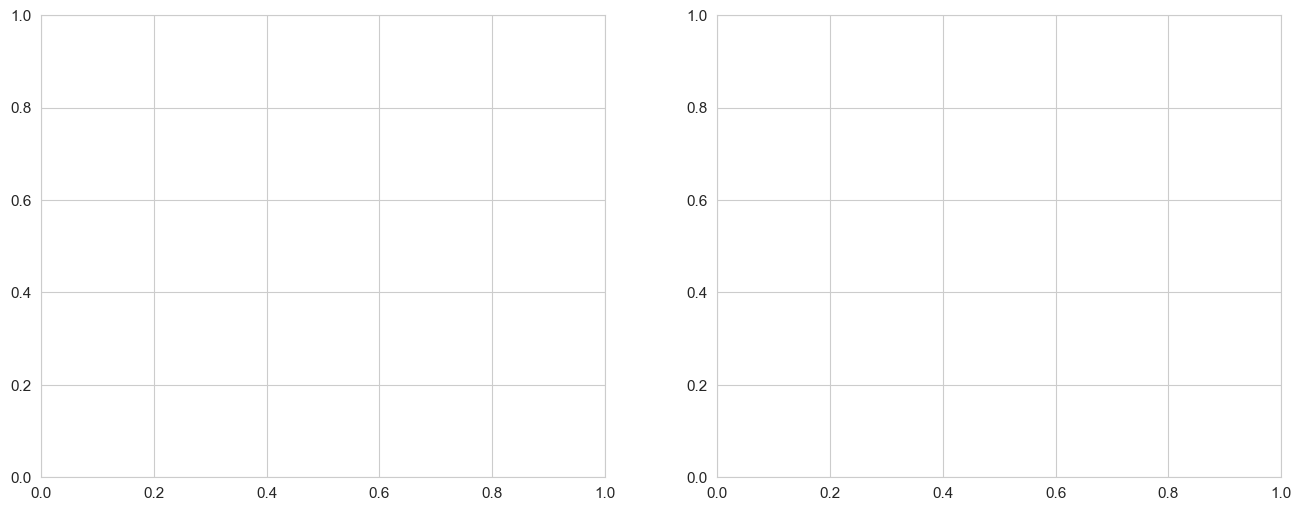

In [ ]:
# Visualization: Centroid dispersion for all groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



# LEFT PANEL: Violin plots
violin_data = []
for dist, label in [(human_centroid_dists, 'Human')] + [(model_centroid_dists[m], m) for m in ai_models if m in model_centroid_dists]:
    for val in dist:
        violin_data.append({'Distance to Centroid': val, 'Group': label})

violin_df = pd.DataFrame(violin_data)
group_order = ['Human'] + [m for m in ai_models if m in model_centroid_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=violin_df, x='Group', y='Distance to Centroid', ax=axes[0], palette=palette_list, order=group_order)
axes[0].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[0].set_xlabel('Group', fontsize=13)
axes[0].set_title('Centroid Dispersion by Group', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')

# RIGHT PANEL: Scatter plot showing individual proposals
offset = 0
x_positions = {}

# Human
x_positions['Human'] = 0
axes[1].scatter([0]*len(human_centroid_dists), human_centroid_dists, 
               alpha=0.5, label='Human', color=colors['Human'], s=50, edgecolors='black', linewidth=0.5)
axes[1].axhline(human_centroid_dists.mean(), xmin=0/len(group_order), xmax=1/len(group_order), 
               color=colors['Human'], linestyle='--', linewidth=2, alpha=0.8)

offset = 1
# Individual AI models
for i, model in enumerate([m for m in ai_models if m in model_centroid_dists]):
    x_positions[model] = offset
    axes[1].scatter([offset]*len(model_centroid_dists[model]), model_centroid_dists[model], 
                   alpha=0.5, label=model, color=colors.get(model, 'gray'), s=50, edgecolors='black', linewidth=0.5)
    axes[1].axhline(model_centroid_dists[model].mean(), 
                   xmin=offset/len(group_order), xmax=(offset+1)/len(group_order),
                   color=colors.get(model, 'gray'), linestyle='--', linewidth=2, alpha=0.7)
    offset += 1

axes[1].set_xticks(range(len(group_order)))
axes[1].set_xticklabels(group_order, rotation=20, fontsize=10)
axes[1].set_ylabel('Distance to Group Centroid', fontsize=13)
axes[1].set_xlabel('Group', fontsize=13)
axes[1].set_title('Individual Proposal Dispersion (dashed = mean)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/figures/centroid_dispersion_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/centroid_dispersion_by_model.png")


---

## Analysis 1.3: Nearest-Neighbor Outlier Detection (Between Group)

Identify "lone wolf" ideas far from everything else.

Compares:
- **Human proposals** (baseline)
- **Individual AI models** (GPT, Gemini, Claude)
- **All AI combined**


In [ ]:
# Combine all embeddings for global nearest-neighbor analysis
all_embeddings = np.vstack([human_embeddings, ai_embeddings])
n_human = len(human_embeddings)
n_ai = len(ai_embeddings)

# Build per-row labels aligned to embedding order (avoid assuming contiguous blocks by model)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = [m for m in sorted(list(dict.fromkeys(ai_model_labels))) if m is not None]

# Compute full distance matrix
print("="*85)
print("COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
print("="*85)

all_distances = cosine_distances(all_embeddings)
np.fill_diagonal(all_distances, np.inf)
nn_distances = all_distances.min(axis=1)

# Split by group
human_nn_dists = nn_distances[labels == 'Human']
ai_nn_dists = nn_distances[labels != 'Human']

# Extract per-model NN distances using label masks
model_nn_dists = {m: nn_distances[labels == m] for m in ai_models_local}

# Print statistics table
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

print(f"{'Human':<35} {len(human_nn_dists):<8} {human_nn_dists.mean():<10.4f} {np.median(human_nn_dists):<10.4f} {human_nn_dists.min():<10.4f} {human_nn_dists.max():<10.4f}")
print()

for model in ai_models_local:
    dists = model_nn_dists[model]
    print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")

print()
print(f"{'All AI (combined)':<35} {len(ai_nn_dists):<8} {ai_nn_dists.mean():<10.4f} {np.median(ai_nn_dists):<10.4f} {ai_nn_dists.min():<10.4f} {ai_nn_dists.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher mean NN distance = more isolated proposals (outliers)")
print("   - Lower mean NN distance = proposals cluster together")
print("="*85)


COMPUTING NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.0372     0.0349     0.0236     0.0646    

claude-opus-4-5                     23       0.0563     0.0392     0.0144     0.3112    
gemini-3-pro-preview                23       0.0313     0.0230     0.0148     0.2322    
gpt-5.2                             23       0.0139     0.0138     0.0111     0.0191    

All AI (combined)                   69       0.0339     0.0191     0.0111     0.3112    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together


In [ ]:
# Identify outliers (top 10% of NN distances)
threshold = np.percentile(nn_distances, 90)
outliers = nn_distances > threshold

human_outliers = int(outliers[labels == 'Human'].sum())
ai_outliers = int(outliers[labels != 'Human'].sum())

# Per-model outlier detection (do NOT slice by contiguous blocks)
model_outliers = {m: int(outliers[labels == m].sum()) for m in ai_models_local}

print("\n" + "="*85)
print("OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)")
print("="*85)
print(f"Threshold distance: {threshold:.4f}")
print()

print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
print("-"*85)

print(f"{'Human':<35} {human_outliers:<15} {n_human:<10} {human_outliers/n_human*100:<15.1f}%")
print()

for model in ai_models_local:
    n_model = int((labels == model).sum())
    print(f"{model:<35} {model_outliers[model]:<15} {n_model:<10} {model_outliers[model]/n_model*100:<15.1f}%")

print()
print(f"{'All AI (combined)':<35} {ai_outliers:<15} {n_ai:<10} {ai_outliers/n_ai*100:<15.1f}%")

print("="*85)



OUTLIER DETECTION (Top 10% Nearest-Neighbor Distance)
Threshold distance: 0.0488

GROUP                               Outliers        Total      Percentage     
-------------------------------------------------------------------------------------
Human                               3               23         13.0           %

claude-opus-4-5                     6               23         26.1           %
gemini-3-pro-preview                1               23         4.3            %
gpt-5.2                             0               23         0.0            %

All AI (combined)                   7               69         10.1           %


In [ ]:
# Find nearest neighbor's group for each proposal
nn_indices = all_distances.argmin(axis=1)
nn_labels = labels[nn_indices]

# Determine if NN is from same or different group
human_nn_same_group = int((nn_labels[labels == 'Human'] == 'Human').sum())
human_nn_diff_group = int(n_human - human_nn_same_group)

ai_nn_same_group = int((nn_labels[labels != 'Human'] != 'Human').sum())
ai_nn_diff_group = int(n_ai - ai_nn_same_group)

# Per-model nearest neighbor group analysis (mask-based)
model_nn_analysis = {}
for model in ai_models_local:
    mask = labels == model
    total = int(mask.sum())
    nn_from_human = int((nn_labels[mask] == 'Human').sum())
    nn_from_same_model = int((nn_labels[mask] == model).sum())
    nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)

    model_nn_analysis[model] = {
        'from_human': nn_from_human,
        'from_same_model': nn_from_same_model,
        'from_other_ai': nn_from_other_ai,
        'total': total
    }

print("\n" + "="*85)
print("NEAREST NEIGHBOR GROUP ANALYSIS")
print("="*85)

print(f"\n{'Human proposals:':<50}")
print(f"  NN from same group (human): {human_nn_same_group} ({human_nn_same_group/n_human*100:.1f}%)")
print(f"  NN from different group (AI): {human_nn_diff_group} ({human_nn_diff_group/n_human*100:.1f}%)")

print(f"\n{'All AI proposals (combined):':<50}")
print(f"  NN from same group (AI): {ai_nn_same_group} ({ai_nn_same_group/n_ai*100:.1f}%)")
print(f"  NN from different group (human): {ai_nn_diff_group} ({ai_nn_diff_group/n_ai*100:.1f}%)")

print("\n" + "-"*85)
print("Per-Model NN Group Breakdown:")
print("-"*85)

for model in ai_models_local:
    data = model_nn_analysis[model]
    print(f"\n{model}:")
    print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
    print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
    print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

print("\n" + "="*85)
print("\n💡 INTERPRETATION:")
print("   - High 'NN from same model' = model produces similar proposals")
print("   - High 'NN from Human' = model proposals resemble human work")
print("="*85)



NEAREST NEIGHBOR GROUP ANALYSIS

Human proposals:                                  
  NN from same group (human): 10 (43.5%)
  NN from different group (AI): 13 (56.5%)

All AI proposals (combined):                      
  NN from same group (AI): 69 (100.0%)
  NN from different group (human): 0 (0.0%)

-------------------------------------------------------------------------------------
Per-Model NN Group Breakdown:
-------------------------------------------------------------------------------------

claude-opus-4-5:
  NN from Human: 0 (0.0%)
  NN from same model: 16 (69.6%)
  NN from other AI models: 7 (30.4%)

gemini-3-pro-preview:
  NN from Human: 0 (0.0%)
  NN from same model: 16 (69.6%)
  NN from other AI models: 7 (30.4%)

gpt-5.2:
  NN from Human: 0 (0.0%)
  NN from same model: 22 (95.7%)
  NN from other AI models: 1 (4.3%)


💡 INTERPRETATION:
   - High 'NN from same model' = model produces similar proposals
   - High 'NN from Human' = model proposals resemble human work


In [ ]:
# Statistical tests - Compare each group to Human
print("\n" + "="*85)
print("STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)")
print("="*85)

# Store all results
nn_comparison_results = []

# Compare All AI vs Human
print("\n" + "-"*85)
print("Comparison: All AI (combined) vs Human")
print("-"*85)

u_stat_nn, p_value_nn = mannwhitneyu(ai_nn_dists, human_nn_dists, alternative='two-sided')
delta_nn = cliffs_delta(ai_nn_dists, human_nn_dists)
delta_nn_interp = interpret_cliffs_delta(delta_nn)
p_value_perm_nn, obs_diff_nn, _ = permutation_test(ai_nn_dists, human_nn_dists)

print(f"\nMann-Whitney U Test:")
print(f"  U-statistic: {u_stat_nn:,.0f}, p-value: {p_value_nn:.4e}")
print(f"\nCliff's Delta:")
print(f"  δ = {delta_nn:.4f} ({delta_nn_interp} effect)")
if delta_nn > 0:
    print(f"  → All AI proposals have MORE unique/outlier ideas")
else:
    print(f"  → Human proposals have MORE unique/outlier ideas")
print(f"\nPermutation Test (10,000 permutations):")
print(f"  Observed difference: {obs_diff_nn:.4f}, p-value: {p_value_perm_nn:.4f}")

nn_comparison_results.append({
    'group': 'All AI',
    'u_stat': u_stat_nn,
    'p_value_mw': p_value_nn,
    'delta': delta_nn,
    'delta_interp': delta_nn_interp,
    'p_value_perm': p_value_perm_nn
})

# Compare each individual AI model vs Human
for model in ai_models:
    if model in model_nn_dists:
        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human")
        print("-"*85)
        
        u_stat_model, p_value_mw_model = mannwhitneyu(model_nn_dists[model], human_nn_dists, alternative='two-sided')
        delta_model = cliffs_delta(model_nn_dists[model], human_nn_dists)
        delta_interp_model = interpret_cliffs_delta(delta_model)
        p_value_perm_model, obs_diff_model, _ = permutation_test(model_nn_dists[model], human_nn_dists)
        
        print(f"\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
        print(f"\nCliff's Delta:")
        print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
        if delta_model > 0:
            print(f"  → {model} proposals have MORE unique/outlier ideas")
        else:
            print(f"  → Human proposals have MORE unique/outlier ideas")
        print(f"\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")
        
        nn_comparison_results.append({
            'group': model,
            'u_stat': u_stat_model,
            'p_value_mw': p_value_mw_model,
            'delta': delta_model,
            'delta_interp': delta_interp_model,
            'p_value_perm': p_value_perm_model
        })

# Summary table
print("\n" + "="*85)
print("SUMMARY: Effect Sizes (Cliff's Delta) - Nearest-Neighbor Distances")
print("="*85)
print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
print("-"*85)
for result in nn_comparison_results:
    print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
print("="*85)
print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone")
print("="*85)



STATISTICAL TESTS: Nearest-Neighbor Distances (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 344, p-value: 5.1476e-05

Cliff's Delta:
  δ = -0.5665 (large effect)
  → Human proposals have MORE unique/outlier ideas

Permutation Test (10,000 permutations):
  Observed difference: -0.0033, p-value: 0.8019

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 280, p-value: 7.4170e-01

Cliff's Delta:
  δ = 0.0586 (negligible effect)
  → claude-opus-4-5 proposals have MORE unique/outlier ideas

Permutation Test (10,000 permutations):
  Observed difference: 0.0191, p-value: 0.1223

-

In [ ]:
import numpy as np
import pandas as pd

print("\n" + "="*85)
print("UNADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers', 'threshold', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the unadjusted NN + outlier detection cells first.")
else:
    outlier_indices = np.where(outliers)[0]
    n_total = int(len(outliers))
    n_ai = int(n_total - n_human)

    # NN distances (unadjusted)
    nn_d = np.asarray(nn_distances) if 'nn_distances' in globals() else None

    # Prefer metadata saved alongside embeddings (aligned with embedding order)
    use_meta = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_meta:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df lookup.")
            use_meta = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_meta:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = int(idx - n_human)
            who = 'AI'
            if use_meta:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', 'AI')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



UNADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.0488
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
claude-opus-4-5         6
Human                   3
gemini-3-pro-preview    1


,global_index,who,model,nn_distance,title
0,89,AI,claude-opus-4-5,0.311175,Emergent Mechanics of Bacterial Microcompartments: Synthesizing Structural and Metabolic Data to Model Encapsulated Pathway Efficiency
1,48,AI,gemini-3-pro-preview,0.232178,The Emergence of Metabolic Channeling: Mapping Transient Metabolons via Integrated Interactomics
2,90,AI,claude-opus-4-5,0.113226,Emergent Receptor Clustering in Immune Synapses: Synthesizing Super-Resolution and Signaling Data to Model T Cell Activation Thresholds
3,85,AI,claude-opus-4-5,0.092681,Emergent Prion Strain Properties: Synthesizing Cryo-EM Structures with Clinical Data to Model How Fibril Architecture Determines Pathology
4,91,AI,claude-opus-4-5,0.092681,Emergent DNA Repair Pathway Choice: Synthesizing Damage Proteomics and Chromatin Data to Model Repair Mechanism Selection
5,82,AI,claude-opus-4-5,0.080993,"Emergent Cooperativity in Transcription Factor Clusters: Synthesizing ChIP-seq, Structural, and Imaging Data to Model Enhancer Activation"
6,86,AI,claude-opus-4-5,0.080993,Emergent Cell Polarity from Protein Localization Networks: Synthesizing Imaging and Interactome Data to Model Symmetry Breaking
7,0,Human,Human,0.064560,CYTOKINETIC BOTTLENECKS OF HEAT WAVES
8,3,Human,Human,0.053078,Synthesizing gene expression data to create an atlas of bacterial cell states
9,16,Human,Human,0.048998,Integrative Multi-Omics Synthesis to Identify Shared Molecular Mechanisms of Mammalian Hibernation


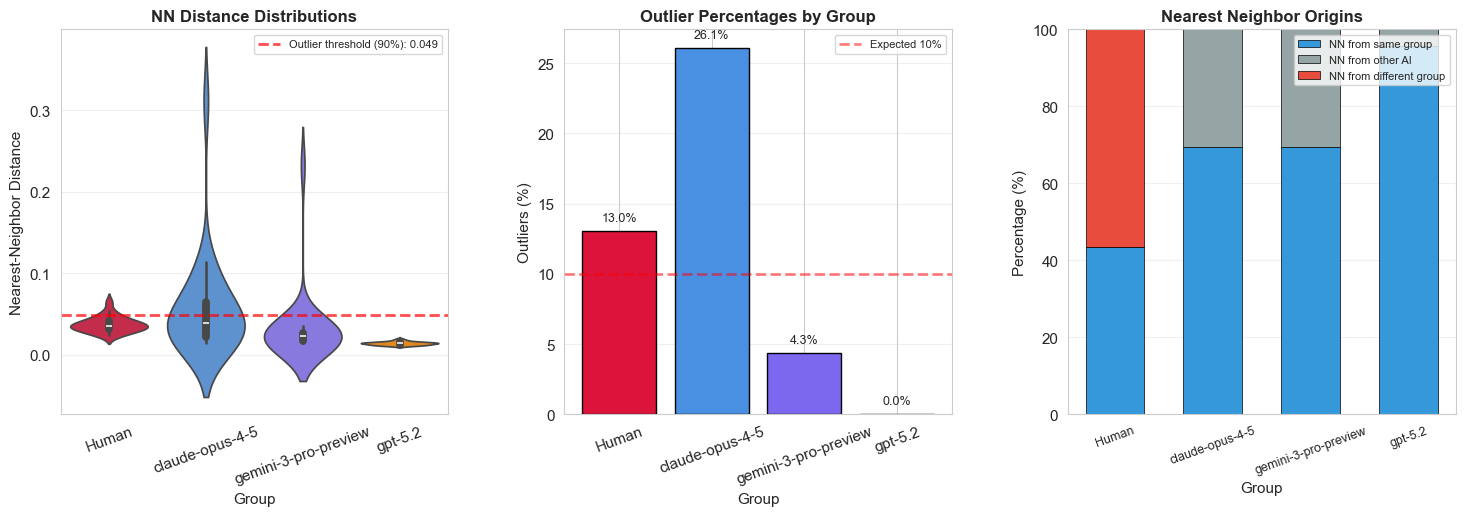

✓ Figure saved to: results/figures/nearest_neighbor_by_model.png


In [ ]:
# Visualization: Nearest-neighbor analysis by group
fig = plt.figure(figsize=(18, 5))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# # Color scheme
# colors = {
#     'Human': 'steelblue',
#     'claude-opus-4-6': '#E74C3C',
#     'gemini-3-pro-preview': '#9B59B6',
#     'gpt-5.2': '#F39C12',
#     'All AI': 'coral'
# }

# 1. NN distance distributions by group
ax1 = fig.add_subplot(gs[0, 0])
nn_data = []
for dist, label in [(human_nn_dists, 'Human')] + [(model_nn_dists[m], m) for m in ai_models if m in model_nn_dists]:
    for val in dist:
        nn_data.append({'NN Distance': val, 'Group': label})

nn_df = pd.DataFrame(nn_data)
group_order = ['Human'] + [m for m in ai_models if m in model_nn_dists]
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order)
ax1.axhline(threshold, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold:.3f}')
ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
ax1.set_xlabel('Group', fontsize=11)
ax1.set_title('NN Distance Distributions', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis='y')

# 2. Outlier counts by group
ax2 = fig.add_subplot(gs[0, 1])
outlier_data = []
outlier_data.append({'Group': 'Human', 'Outliers': human_outliers, 'Total': n_human, 'Percentage': human_outliers/n_human*100})

for model in ai_models:
    if model in model_outliers:
        n_model = len(model_embeddings_dict[model])
        outlier_data.append({
            'Group': model,
            'Outliers': model_outliers[model],
            'Total': n_model,
            'Percentage': model_outliers[model]/n_model*100
        })

outlier_df = pd.DataFrame(outlier_data)
bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors.get(g, 'gray') for g in outlier_df['Group']], 
               edgecolor='black', linewidth=1)
ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
ax2.set_ylabel('Outliers (%)', fontsize=11)
ax2.set_xlabel('Group', fontsize=11)
ax2.set_title('Outlier Percentages by Group', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=20)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (bar, pct) in enumerate(zip(bars, outlier_df['Percentage'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# 3. NN Group Analysis - Stacked bar chart
ax3 = fig.add_subplot(gs[0, 2])

# Prepare data for stacked bars
groups = ['Human'] + [m for m in ai_models if m in model_nn_analysis]
nn_from_human_pcts = [human_nn_diff_group/n_human*100]  # For human, this is NN from AI
nn_from_same_pcts = [human_nn_same_group/n_human*100]  # For human, this is NN from human
nn_from_other_ai_pcts = [0]  # Human doesn't have this category

for model in [m for m in ai_models if m in model_nn_analysis]:
    data = model_nn_analysis[model]
    nn_from_human_pcts.append(data['from_human']/data['total']*100)
    nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
    nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

x_pos = np.arange(len(groups))
width = 0.6

# Adjust labels for Human
p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax3.set_ylabel('Percentage (%)', fontsize=11)
ax3.set_xlabel('Group', fontsize=11)
ax3.set_title('Nearest Neighbor Origins', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(groups, rotation=20, fontsize=9)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3, axis='y')
ax3.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('results/figures/nearest_neighbor_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/nearest_neighbor_by_model.png")


### The Key Insight: Location vs. Distance

NN Group Analysis (Which group is closest):
Tells us WHERE proposals are in semantic space
0% of GPT have human NN → GPT proposals are in "AI territory"
Outlier Detection (How far from nearest neighbor):
Tells us HOW ISOLATED proposals are
26.1% of GPT are outliers → Some GPT proposals are very FAR from everything
These Are Compatible! 


What's happening:
Most GPT proposals (74%) cluster together in AI region
Some GPT proposals (26%) are VERY far from this cluster
BUT even these outliers are still closer to other AI than to humans
The outliers are "weird AI proposals" not "human-like proposals"
The Numbers Tell the Story:
Outlier threshold: 0.0488
This is the NN distance that defines top 10% most isolated proposals
GPT has 6 proposals with NN distance > 0.0488
BUT:

These 6 GPT outliers, despite being far from everything...
Are STILL closer to some AI proposal than to any human
The distance to nearest AI < distance to nearest human

What This Reveals About Each Model:

Claude (0% outliers, 95.7% same-model NN):
Highly consistent
All proposals tightly clustered
Strong model signature
"Conservative diversity"

Gemini (4.3% outliers, 69.6% same-model NN):
Moderately consistent
Mostly similar, few outliers
Some cross-model similarity with GPT
"Controlled diversity"

GPT-5.2 (26.1% outliers, 69.6% same-model NN):
Inconsistent/erratic
Produces both clustered AND isolated proposals
High variance in output
"Chaotic diversity"

Human (13.0% outliers, 43.5% same-group NN):
Naturally dispersed
Moderate outlier rate
Most diverse pattern: nearest neighbors include both human AND AI
"Authentic diversity"

### The Critical Distinction:
AI Outliers ≠ Human-like
GPT's outliers are:
✅ Far from other GPT proposals
✅ Far from other AI proposals
✅ Still in "AI semantic territory"
❌ NOT close to human proposals

This means GPT occasionally generates strange/unusual AI-style proposals, not human-like proposals.

### Why This Matters:
GPT-5.2's high outlier rate reveals:
Lower reliability - output is less predictable
Not escaping AI patterns - outliers still have AI characteristics
Different kind of diversity - variance within constraints, not breaking free
Contrast with Human:
Lower outlier rate (13% vs 26%)
But 56.5% of humans are closer to AI than to other humans
Humans span semantic space, not cluster with outliers
More natural variation, less extreme deviations
Reconciled Interpretation:
Both results together tell us:

GPT-5.2:
"I'll give you 23 proposals"
"17 will be very similar to each other"
"6 will be weird and different"
"But they'll ALL sound like AI proposals"

Humans:
"We'll each write our own proposal"
"Some will be somewhat similar"
"Some will be quite different"
"They'll be scattered across possibility space"
"A few might accidentally resemble AI patterns"

Bottom Line:
The results perfectly align: GPT has the most outliers (erratic), but even its outliers stay in AI semantic space (constrained). This is variance without true diversity - like a jazz musician who sometimes plays way off-key, but never leaves the jazz genre! 🎷

### Embedding Space Visualization

Visualize all proposals in 2D space using UMAP dimensionality reduction to see:
- **Clustering patterns**: How proposals group together
- **Outliers**: Unique proposals far from others (highlighted in magenta)
- **Group separation**: How Human vs AI proposals distribute in semantic space
- **Model characteristics**: Whether different AI models produce distinctly clustered proposals

**Color coding**: Human proposals in bright red for easy identification, AI models in muted colors.


VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE

Reducing embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


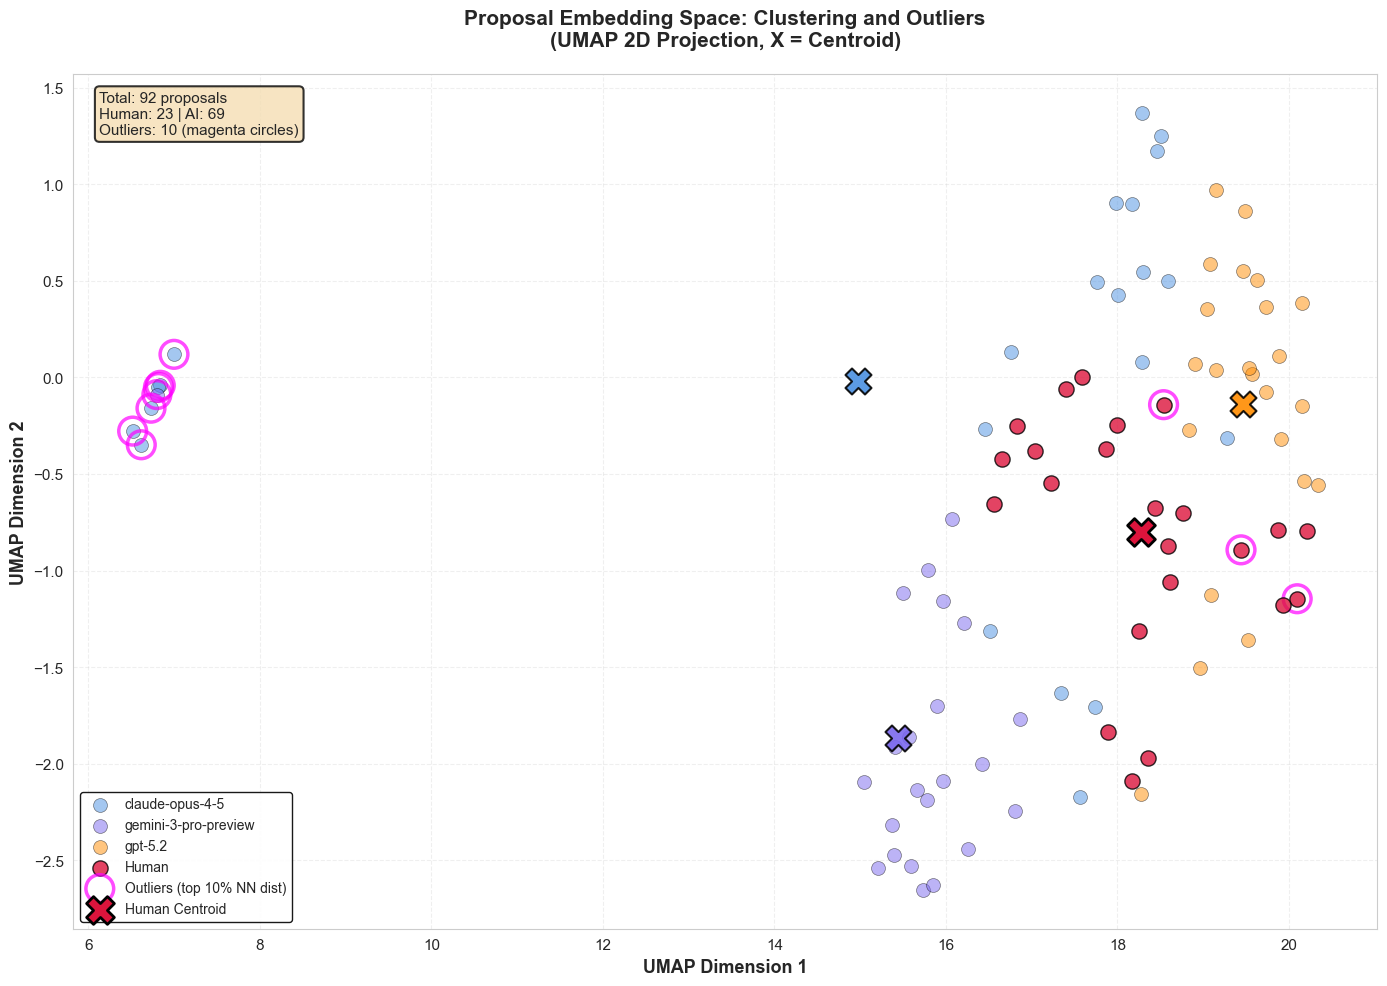


✓ Figure saved to: results/figures/embedding_space_2d.png

💡 INTERPRETATION:
   - Clusters = similar proposals
   - Outliers (magenta circles) = unique/distant proposals
   - X markers = group centroids
   - Distance between groups shows overall similarity


In [ ]:


print("\n" + "="*85)
print("VISUALIZING PROPOSALS IN 2D EMBEDDING SPACE")
print("="*85)

# Apply UMAP dimensionality reduction
print("\nReducing embeddings to 2D using UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# Combine all embeddings for UMAP
all_embeddings_umap = np.vstack([human_embeddings, ai_embeddings])
embeddings_2d = reducer.fit_transform(all_embeddings_umap)

# Split back into groups
human_2d = embeddings_2d[:n_human]
ai_2d = embeddings_2d[n_human:]

# Build labels aligned to embedding order (avoid assuming contiguous model blocks)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_umap = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

print(f"✓ UMAP completed: {len(embeddings_2d)} proposals reduced to 2D")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot AI models first (so human is on top) — mask-based by label
for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        pts = embeddings_2d[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Plot human proposals on top (bright red)
ax.scatter(human_2d[:, 0], human_2d[:, 1],
          c=colors['Human'],
          label='Human',
          s=120,
          alpha=0.8,
          edgecolors='black',
          linewidth=1.0,
          marker='o',
          zorder=10)  # Ensure human points are on top

# Highlight outliers with a circle
outlier_indices = np.where(outliers)[0]
outlier_coords = embeddings_2d[outlier_indices]

ax.scatter(outlier_coords[:, 0], outlier_coords[:, 1],
          s=400,
          facecolors='none',
          edgecolors='magenta',
          linewidth=2.5,
          alpha=0.7,
          label=f'Outliers (top 10% NN dist)',
          zorder=5)

# Calculate and plot centroids for each group
human_centroid_2d = human_2d.mean(axis=0)
ax.scatter(human_centroid_2d[0], human_centroid_2d[1],
          c=colors['Human'],
          s=400,
          marker='X',
          edgecolors='black',
          linewidth=2,
          alpha=1.0,
          zorder=15,
          label='Human Centroid')

for model in ai_models_local:
    mask = labels_umap == model
    if mask.any():
        model_centroid_2d = embeddings_2d[mask].mean(axis=0)
        ax.scatter(model_centroid_2d[0], model_centroid_2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=12)

# Labels and formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Proposal Embedding Space: Clustering and Outliers\n(UMAP 2D Projection, X = Centroid)',
            fontsize=15, fontweight='bold', pad=20)

# Legend
ax.legend(loc='best', fontsize=10, framealpha=0.9, edgecolor='black')

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text annotation with key insights
textstr = f'Total: {len(embeddings_2d)} proposals\n'
textstr += f'Human: {n_human} | AI: {n_ai}\n'
textstr += f'Outliers: {len(outlier_indices)} (magenta circles)'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('results/figures/embedding_space_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/embedding_space_2d.png")
print("\n💡 INTERPRETATION:")
print("   - Clusters = similar proposals")
print("   - Outliers (magenta circles) = unique/distant proposals")
print("   - X markers = group centroids")
print("   - Distance between groups shows overall similarity")
print("="*85)



ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)

Reducing embeddings to 2D using t-SNE...
(This may take a minute...)


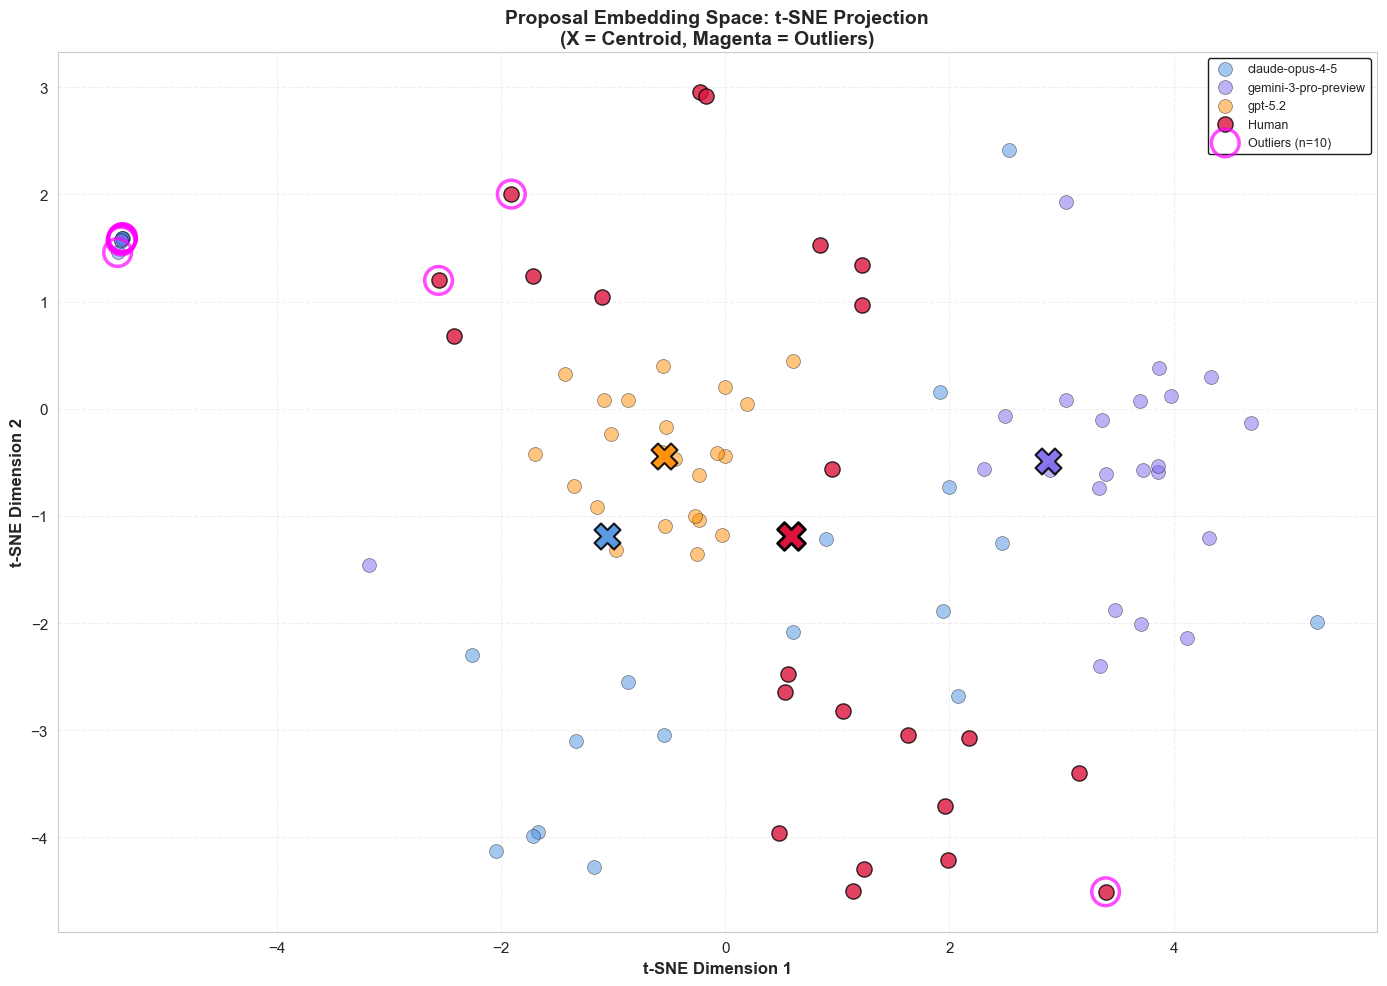


✓ Figure saved to: results/figures/embedding_space_tsne.png


In [ ]:
# Alternative visualization: t-SNE (complementary to UMAP)
from sklearn.manifold import TSNE

print("\n" + "="*85)
print("ALTERNATIVE VIEW: t-SNE Projection (metadata-aligned)")
print("="*85)

# Build labels aligned to embedding order (same approach as UMAP cell)
if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == len(ai_embeddings):
    ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
elif 'ai_df' in globals() and len(ai_df) == len(ai_embeddings) and 'model' in ai_df.columns:
    print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
    ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
else:
    raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

labels_tsne = np.array((['Human'] * n_human) + ai_model_labels)
ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

# Apply t-SNE dimensionality reduction
print("\nReducing embeddings to 2D using t-SNE...")
print("(This may take a minute...)")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    metric='cosine',
    random_state=42,
    n_iter=1000,
    verbose=0
)

embeddings_2d_tsne = tsne.fit_transform(all_embeddings_umap)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        pts = embeddings_2d_tsne[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=100,
                   alpha=0.5,
                   edgecolors='black',
                   linewidth=0.5)

# Human
mask_h = labels_tsne == 'Human'
pts_h = embeddings_2d_tsne[mask_h]
ax.scatter(pts_h[:, 0], pts_h[:, 1],
           c=colors['Human'],
           label='Human',
           s=120,
           alpha=0.8,
           edgecolors='black',
           linewidth=1.0,
           marker='o',
           zorder=10)

# Highlight the same outliers (computed from NN distances)
outlier_indices = np.where(outliers)[0]
outlier_coords_plot = embeddings_2d_tsne[outlier_indices]
ax.scatter(outlier_coords_plot[:, 0], outlier_coords_plot[:, 1],
           s=400,
           facecolors='none',
           edgecolors='magenta',
           linewidth=2.5,
           alpha=0.7,
           label=f'Outliers (n={len(outlier_indices)})',
           zorder=12)

# Centroids
centroid_h = pts_h.mean(axis=0)
ax.scatter(centroid_h[0], centroid_h[1],
           c=colors['Human'],
           s=400,
           marker='X',
           edgecolors='black',
           linewidth=2,
           alpha=1.0,
           zorder=15)

for model in ai_models_local:
    mask = labels_tsne == model
    if mask.any():
        c2d = embeddings_2d_tsne[mask].mean(axis=0)
        ax.scatter(c2d[0], c2d[1],
                   c=colors.get(model, '#808080'),
                   s=350,
                   marker='X',
                   edgecolors='black',
                   linewidth=1.5,
                   alpha=0.9,
                   zorder=14)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
ax.set_title('Proposal Embedding Space: t-SNE Projection\n(X = Centroid, Magenta = Outliers)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')

plt.tight_layout()
out_path = 'results/figures/embedding_space_tsne.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure saved to: {out_path}")
print("="*85)


---

# PART II: NOVELTY

Can AI create more novel proposals than teams of human scientists?

We'll compare how far proposals are from existing literature (PubMed corpus).

## Step 1: Load Literature Corpus

Load the 350 PubMed abstracts from `data/literature/call-relevant-corpus.json`.

In [ ]:
import json

# Load literature corpus
print("="*85)
print("LOADING LITERATURE CORPUS")
print("="*85)

with open('data/literature/call-relevant-corpus.json', 'r') as f:
    corpus_data = json.load(f)

articles = corpus_data['articles']
print(f"\n✓ Loaded {len(articles)} PubMed articles")
print(f"  Search queries: {len(corpus_data['search_queries'])}")

# Extract title and abstract for each article
corpus_texts = []
for article in articles:
    title = article.get('title', '')
    abstract = article.get('abstract', '')
    # Combine title and abstract (same format as we'll use for proposals)
    text = f"Title: {title}\n\nAbstract: {abstract}"
    corpus_texts.append(text)

print(f"\n✓ Prepared {len(corpus_texts)} literature texts")
print(f"  Average length: {np.mean([len(t) for t in corpus_texts]):.0f} characters")
print("="*85)

LOADING LITERATURE CORPUS

✓ Loaded 350 PubMed articles
  Search queries: 7

✓ Prepared 350 literature texts
  Average length: 1351 characters


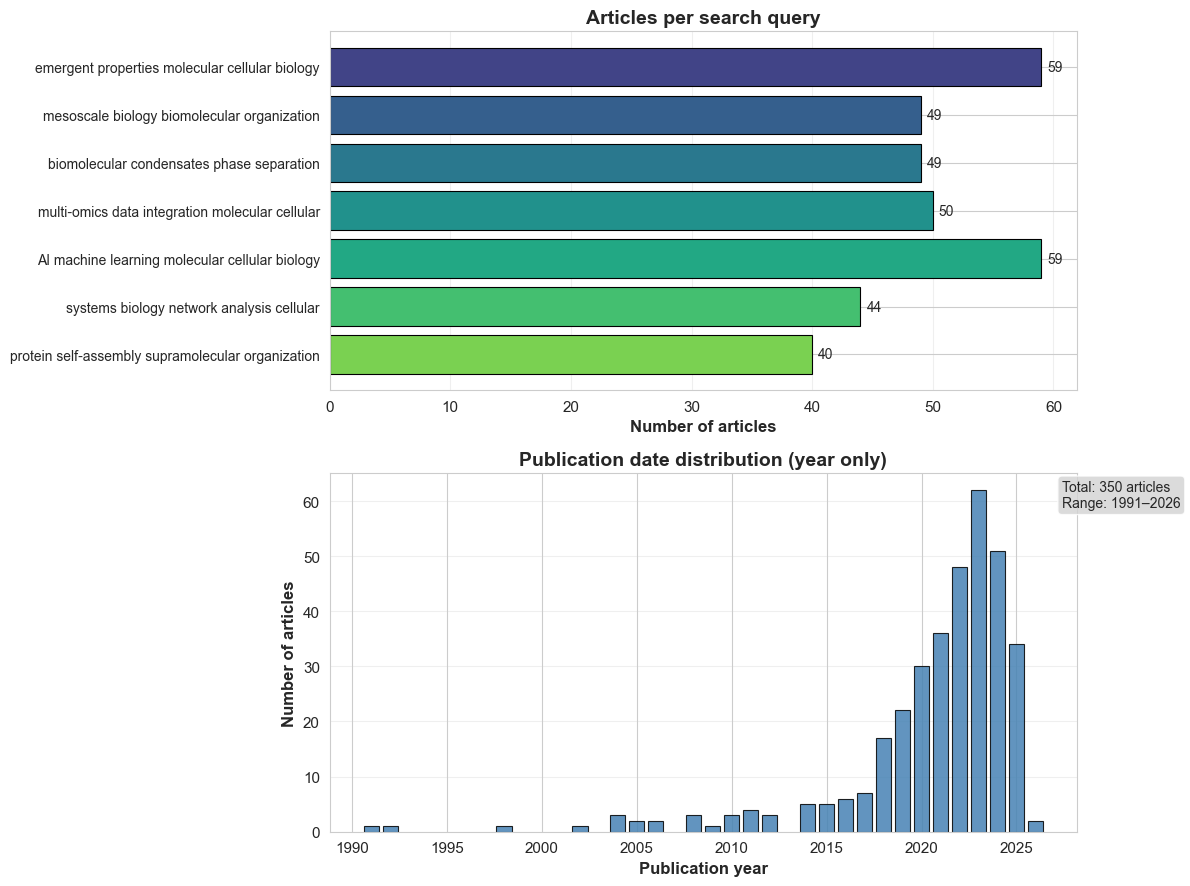

✓ Figure saved to: results/figures/literature_corpus_overview.png

SEARCH TERMS (QUERIES) USED PER CATEGORY

• emergent properties molecular cellular biology (n=59 articles):
  ("emergent properties" OR "emergence") AND ("molecular biology" OR "cellular biology" OR "cell biology")

• mesoscale biology biomolecular organization (n=49 articles):
  ("mesoscale" OR "mesoscopic") AND ("protein" OR "biomolecular" OR "cellular" OR "organelle")

• biomolecular condensates phase separation (n=49 articles):
  ("biomolecular condensates" OR "phase separation") AND ("cell biology" OR "molecular biology")

• multi-omics data integration molecular cellular (n=50 articles):
  ("multi-omics" OR "multiomics" OR "integrative omics") AND ("data integration" OR "data synthesis") AND ("molecular" OR "cellular")

• AI machine learning molecular cellular biology (n=59 articles):
  ("machine learning" OR "artificial intelligence" OR "deep learning") AND ("molecular biology" OR "cell biology" OR "proteomics" O

In [ ]:
# Visualize literature corpus: articles per query + publication year distribution
import re

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# --- Panel 1: Articles per search query ---
ax1 = axes[0]
queries = corpus_data['search_queries']
labels = [q['label'] for q in queries]
counts = [q['new_unique_added'] for q in queries]
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(labels)))
bars = ax1.barh(range(len(labels)), counts, color=colors_bar, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=10, ha='right')
ax1.set_xlabel('Number of articles', fontsize=12, fontweight='bold')
ax1.set_title('Articles per search query', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
for bar, c in zip(bars, counts):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(c), va='center', fontsize='10')

# --- Panel 2: Publication year distribution ---
ax2 = axes[1]
def parse_year(pub_date):
    if not pub_date or not isinstance(pub_date, str):
        return None
    m = re.match(r'(\d{4})', pub_date.strip())
    return int(m.group(1)) if m else None

years = [parse_year(a.get('publication_date')) for a in articles]
years = [y for y in years if y is not None]
year_counts = pd.Series(years).value_counts().sort_index()

ax2.bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_xlabel('Publication year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of articles', fontsize=12, fontweight='bold')
ax2.set_title('Publication date distribution (year only)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
if years:
    ax2.text(0.98, 0.98, f'Total: {len(years)} articles\nRange: {min(years)}–{max(years)}', transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='left',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.savefig('results/figures/literature_corpus_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figure saved to: results/figures/literature_corpus_overview.png')

# Print search terms (queries) used for each category
print('\n' + '='*85)
print('SEARCH TERMS (QUERIES) USED PER CATEGORY')
print('='*85)
for q in queries:
    print(f"\n• {q['label']} (n={q['new_unique_added']} articles):")
    print(f"  {q['query']}")
print('='*85)

## Step 2: Embed Literature Corpus 

Embed all 350 abstracts using BioLinkBERT-Large (same model used for proposals).

In [ ]:
# Embed literature corpus using the same chunking approach
print("="*85)
print("EMBEDDING LITERATURE CORPUS")
print("="*85)
print("Using BioLinkBERT-Large with chunking (same as proposals)")
print()

# Check if embeddings already exist
literature_embeddings_file = Path('data/embeddings/literature/relevant_literature_embeddings.pkl')

if literature_embeddings_file.exists():
    print(f"✓ Loading cached literature embeddings from {literature_embeddings_file}")
    with open(literature_embeddings_file, 'rb') as f:
        literature_data = pickle.load(f)
        literature_embeddings = literature_data['embeddings']
    print(f"✓ Loaded {len(literature_embeddings)} embeddings")
else:
    print("Embedding literature corpus (this will take a few minutes)...")
    literature_embeddings = get_embeddings_with_chunking(corpus_texts)
    print(f"✓ Literature embeddings shape: {literature_embeddings.shape}")
    
    # Cache for future use
    with open(literature_embeddings_file, 'wb') as f:
        pickle.dump({
            'embeddings': literature_embeddings,
            'model_name': model_name,
            'timestamp': datetime.now().isoformat()
        }, f)
    print(f"✓ Cached embeddings to: {literature_embeddings_file}")

print("="*85)

EMBEDDING LITERATURE CORPUS
Using BioLinkBERT-Large with chunking (same as proposals)

✓ Loading cached literature embeddings from data/embeddings/literature/relevant_literature_embeddings.pkl
✓ Loaded 350 embeddings


## Step 3: Re-embed Proposals (Title + Abstract Only)

For fair comparison with literature (which only has abstracts), re-embed proposals using only title and abstract.

In [ ]:
# Re-embed proposals using only title + abstract (for fair comparison with literature)
print("="*85)
print("RE-EMBEDDING PROPOSALS (TITLE + ABSTRACT ONLY)")
print("="*85)

# Create title+abstract text for AI proposals
ai_abstracts_only = []
for idx, row in ai_df.iterrows():
    title = row['title']
    abstract = row['abstract']
    text = f"Title: {title}\n\nAbstract: {abstract}"
    ai_abstracts_only.append(text)

# Create title+abstract text for Human proposals
human_abstracts_only = []
for idx, row in human_df.iterrows():
    title = row.get('proposal_title', row.get('title', ''))
    abstract = row.get('abstract', '')
    text = f"Title: {title}\n\nAbstract: {abstract}"
    human_abstracts_only.append(text)

print(f"\nPrepared {len(ai_abstracts_only)} AI abstracts")
print(f"Prepared {len(human_abstracts_only)} human abstracts")
print(f"Average length - AI: {np.mean([len(t) for t in ai_abstracts_only]):.0f} chars")
print(f"Average length - Human: {np.mean([len(t) for t in human_abstracts_only]):.0f} chars")

# Check if abstract-only embeddings already exist
abstract_embeddings_file = Path('data/embeddings/titles-abstracts/abstracts_embeddings_human_ai_baseline.pkl')

if abstract_embeddings_file.exists():
    print(f"\n✓ Loading cached abstract embeddings from {abstract_embeddings_file}")
    with open(abstract_embeddings_file, 'rb') as f:
        abstract_data = pickle.load(f)
        ai_embeddings_abstract = abstract_data['ai_embeddings']
        human_embeddings_abstract = abstract_data['human_embeddings']
    print(f"✓ Loaded embeddings: AI {ai_embeddings_abstract.shape}, Human {human_embeddings_abstract.shape}")
else:
    print("\nEmbedding AI abstracts...")
    ai_embeddings_abstract = get_embeddings_with_chunking(ai_abstracts_only)
    print(f"✓ AI abstract embeddings shape: {ai_embeddings_abstract.shape}")
    
    print("\nEmbedding human abstracts...")
    human_embeddings_abstract = get_embeddings_with_chunking(human_abstracts_only)
    print(f"✓ Human abstract embeddings shape: {human_embeddings_abstract.shape}")
    
    # Cache for future use
    with open(abstract_embeddings_file, 'wb') as f:
        pickle.dump({
            'ai_embeddings': ai_embeddings_abstract,
            'human_embeddings': human_embeddings_abstract,
            'model_name': model_name,
            'timestamp': datetime.now().isoformat()
        }, f)
    print(f"\n✓ Cached embeddings to: {abstract_embeddings_file}")

print("="*85)

RE-EMBEDDING PROPOSALS (TITLE + ABSTRACT ONLY)

Prepared 69 AI abstracts
Prepared 23 human abstracts
Average length - AI: 2122 chars
Average length - Human: 1663 chars

✓ Loading cached abstract embeddings from data/embeddings/titles-abstracts/abstracts_embeddings_human_ai_baseline.pkl
✓ Loaded embeddings: AI (69, 1024), Human (23, 1024)


## Step 4: Compute Novelty Scores

For each proposal, find k=10 nearest neighbors in literature corpus and compute novelty score.

In [ ]:
from sklearn.metrics.pairwise import cosine_distances

# Compute novelty scores
print("="*85)
print("COMPUTING NOVELTY SCORES")
print("="*85)
print("Novelty = Mean distance to 10 nearest neighbors in literature corpus")
print("Higher score = farther from existing work = more novel")
print()

k = 10  # Number of nearest neighbors

def compute_novelty_scores(proposal_embeddings, literature_embeddings, k=10):
    """
    Compute novelty score for each proposal as mean distance to k-NN in literature.
    
    Args:
        proposal_embeddings: Embeddings of proposals (n_proposals, embedding_dim)
        literature_embeddings: Embeddings of literature corpus (n_articles, embedding_dim)
        k: Number of nearest neighbors
        
    Returns:
        novelty_scores: Array of novelty scores (n_proposals,)
        nearest_neighbor_indices: Array of k-NN indices for each proposal (n_proposals, k)
    """
    # Compute distances from each proposal to all literature articles
    distances = cosine_distances(proposal_embeddings, literature_embeddings)
    
    # For each proposal, find k nearest neighbors
    nearest_neighbor_indices = np.argsort(distances, axis=1)[:, :k]
    
    # Novelty score = mean distance to k-NN
    novelty_scores = np.array([
        distances[i, nearest_neighbor_indices[i]].mean()
        for i in range(len(proposal_embeddings))
    ])
    
    return novelty_scores, nearest_neighbor_indices

# Compute novelty for AI proposals
print("Computing novelty scores for AI proposals...")
ai_novelty_scores, ai_nn_indices = compute_novelty_scores(
    ai_embeddings_abstract, literature_embeddings, k=k
)

# Compute novelty for Human proposals
print("Computing novelty scores for human proposals...")
human_novelty_scores, human_nn_indices = compute_novelty_scores(
    human_embeddings_abstract, literature_embeddings, k=k
)

# Split AI novelty by model (mask-based; do NOT assume contiguous blocks)
if 'ai_df' not in globals() or 'model' not in ai_df.columns:
    raise RuntimeError("ai_df with a 'model' column is required to split AI novelty scores by model")

ai_models = sorted(ai_df['model'].astype(str).unique().tolist())
ai_model_series = ai_df['model'].astype(str).values

model_novelty_scores = {m: ai_novelty_scores[ai_model_series == m] for m in ai_models}

# Display statistics
print(f"\n{'='*85}")
print("NOVELTY SCORE STATISTICS")
print(f"{'='*85}")
print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
print("-"*85)

# Human
print(f"{'Human':<35} {len(human_novelty_scores):<8} {human_novelty_scores.mean():<10.4f} {np.median(human_novelty_scores):<10.4f} {human_novelty_scores.min():<10.4f} {human_novelty_scores.max():<10.4f}")

print()  # Blank line

# Individual AI models
for model in ai_models:
    if model in model_novelty_scores:
        scores = model_novelty_scores[model]
        print(f"{model:<35} {len(scores):<8} {scores.mean():<10.4f} {np.median(scores):<10.4f} {scores.min():<10.4f} {scores.max():<10.4f}")

print()  # Blank line

# All AI combined
print(f"{'All AI (combined)':<35} {len(ai_novelty_scores):<8} {ai_novelty_scores.mean():<10.4f} {np.median(ai_novelty_scores):<10.4f} {ai_novelty_scores.min():<10.4f} {ai_novelty_scores.max():<10.4f}")

print("="*85)
print("\n💡 INTERPRETATION:")
print("   - Higher novelty score = more distant from existing literature")
print("   - Lower novelty score = more similar to published work")
print("="*85)

COMPUTING NOVELTY SCORES
Novelty = Mean distance to 10 nearest neighbors in literature corpus
Higher score = farther from existing work = more novel

Computing novelty scores for AI proposals...
Computing novelty scores for human proposals...

NOVELTY SCORE STATISTICS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.1512     0.1528     0.0742     0.2598    

claude-opus-4-5                     23       0.1100     0.0914     0.0815     0.1911    
gemini-3-pro-preview                23       0.1091     0.1045     0.0587     0.1773    
gpt-5.2                             23       0.1329     0.1000     0.0884     0.2774    

All AI (combined)                   69       0.1173     0.0981     0.0587     0.2774    

💡 INTERPRETATION:
   - Higher novelty score = more distant from existing literature
   - Lower novelty scor

## Step 5: Statistical Tests for Novelty

Compare novelty scores between groups using statistical tests.

In [ ]:
# Statistical tests - Compare each group to Human
print("="*85)
print("STATISTICAL TESTS: Novelty Scores (All Groups vs Human)")
print("="*85)

# Store all results
novelty_comparison_results = []

# Compare All AI vs Human
print("\n" + "-"*85)
print("Comparison: All AI (combined) vs Human")
print("-"*85)

u_stat_nov, p_value_nov = mannwhitneyu(ai_novelty_scores, human_novelty_scores, alternative='two-sided')
delta_nov = cliffs_delta(ai_novelty_scores, human_novelty_scores)
delta_interp_nov = interpret_cliffs_delta(delta_nov)
p_value_perm_nov, obs_diff_nov, _ = permutation_test(ai_novelty_scores, human_novelty_scores)

print(f"\nMann-Whitney U Test:")
print(f"  U-statistic: {u_stat_nov:,.0f}, p-value: {p_value_nov:.4e}")
print(f"\nCliff's Delta:")
print(f"  δ = {delta_nov:.4f} ({delta_interp_nov} effect)")
if delta_nov > 0:
    print(f"  → All AI proposals are MORE novel than human proposals")
else:
    print(f"  → Human proposals are MORE novel than all AI proposals")
print(f"\nPermutation Test (10,000 permutations):")
print(f"  Observed difference: {obs_diff_nov:.4f}, p-value: {p_value_perm_nov:.4f}")

novelty_comparison_results.append({
    'group': 'All AI',
    'u_stat': u_stat_nov,
    'p_value_mw': p_value_nov,
    'delta': delta_nov,
    'delta_interp': delta_interp_nov,
    'p_value_perm': p_value_perm_nov
})

# Compare each individual AI model vs Human
for model in ai_models:
    if model in model_novelty_scores:
        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human")
        print("-"*85)
        
        u_stat_model, p_value_mw_model = mannwhitneyu(model_novelty_scores[model], human_novelty_scores, alternative='two-sided')
        delta_model = cliffs_delta(model_novelty_scores[model], human_novelty_scores)
        delta_interp_model = interpret_cliffs_delta(delta_model)
        p_value_perm_model, obs_diff_model, _ = permutation_test(model_novelty_scores[model], human_novelty_scores)
        
        print(f"\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
        print(f"\nCliff's Delta:")
        print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
        if delta_model > 0:
            print(f"  → {model} proposals are MORE novel than human proposals")
        else:
            print(f"  → Human proposals are MORE novel than {model} proposals")
        print(f"\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")
        
        novelty_comparison_results.append({
            'group': model,
            'u_stat': u_stat_model,
            'p_value_mw': p_value_mw_model,
            'delta': delta_model,
            'delta_interp': delta_interp_model,
            'p_value_perm': p_value_perm_model
        })

# Summary table
print("\n" + "="*85)
print("SUMMARY: Effect Sizes (Cliff's Delta) - Novelty Scores")
print("="*85)
print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
print("-"*85)
for result in novelty_comparison_results:
    print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
print("="*85)
print("\n💡 Positive δ = AI more novel; Negative δ = Human more novel")
print("="*85)

STATISTICAL TESTS: Novelty Scores (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 520, p-value: 1.3831e-02

Cliff's Delta:
  δ = -0.3447 (medium effect)
  → Human proposals are MORE novel than all AI proposals

Permutation Test (10,000 permutations):
  Observed difference: -0.0339, p-value: 0.0057

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 208, p-value: 2.1859e-01

Cliff's Delta:
  δ = -0.2136 (small effect)
  → Human proposals are MORE novel than claude-opus-4-5 proposals

Permutation Test (10,000 permutations):
  Observed difference: -0.0183, p-value: 0.3369

-----

## Step 6: Visualize Novelty Results

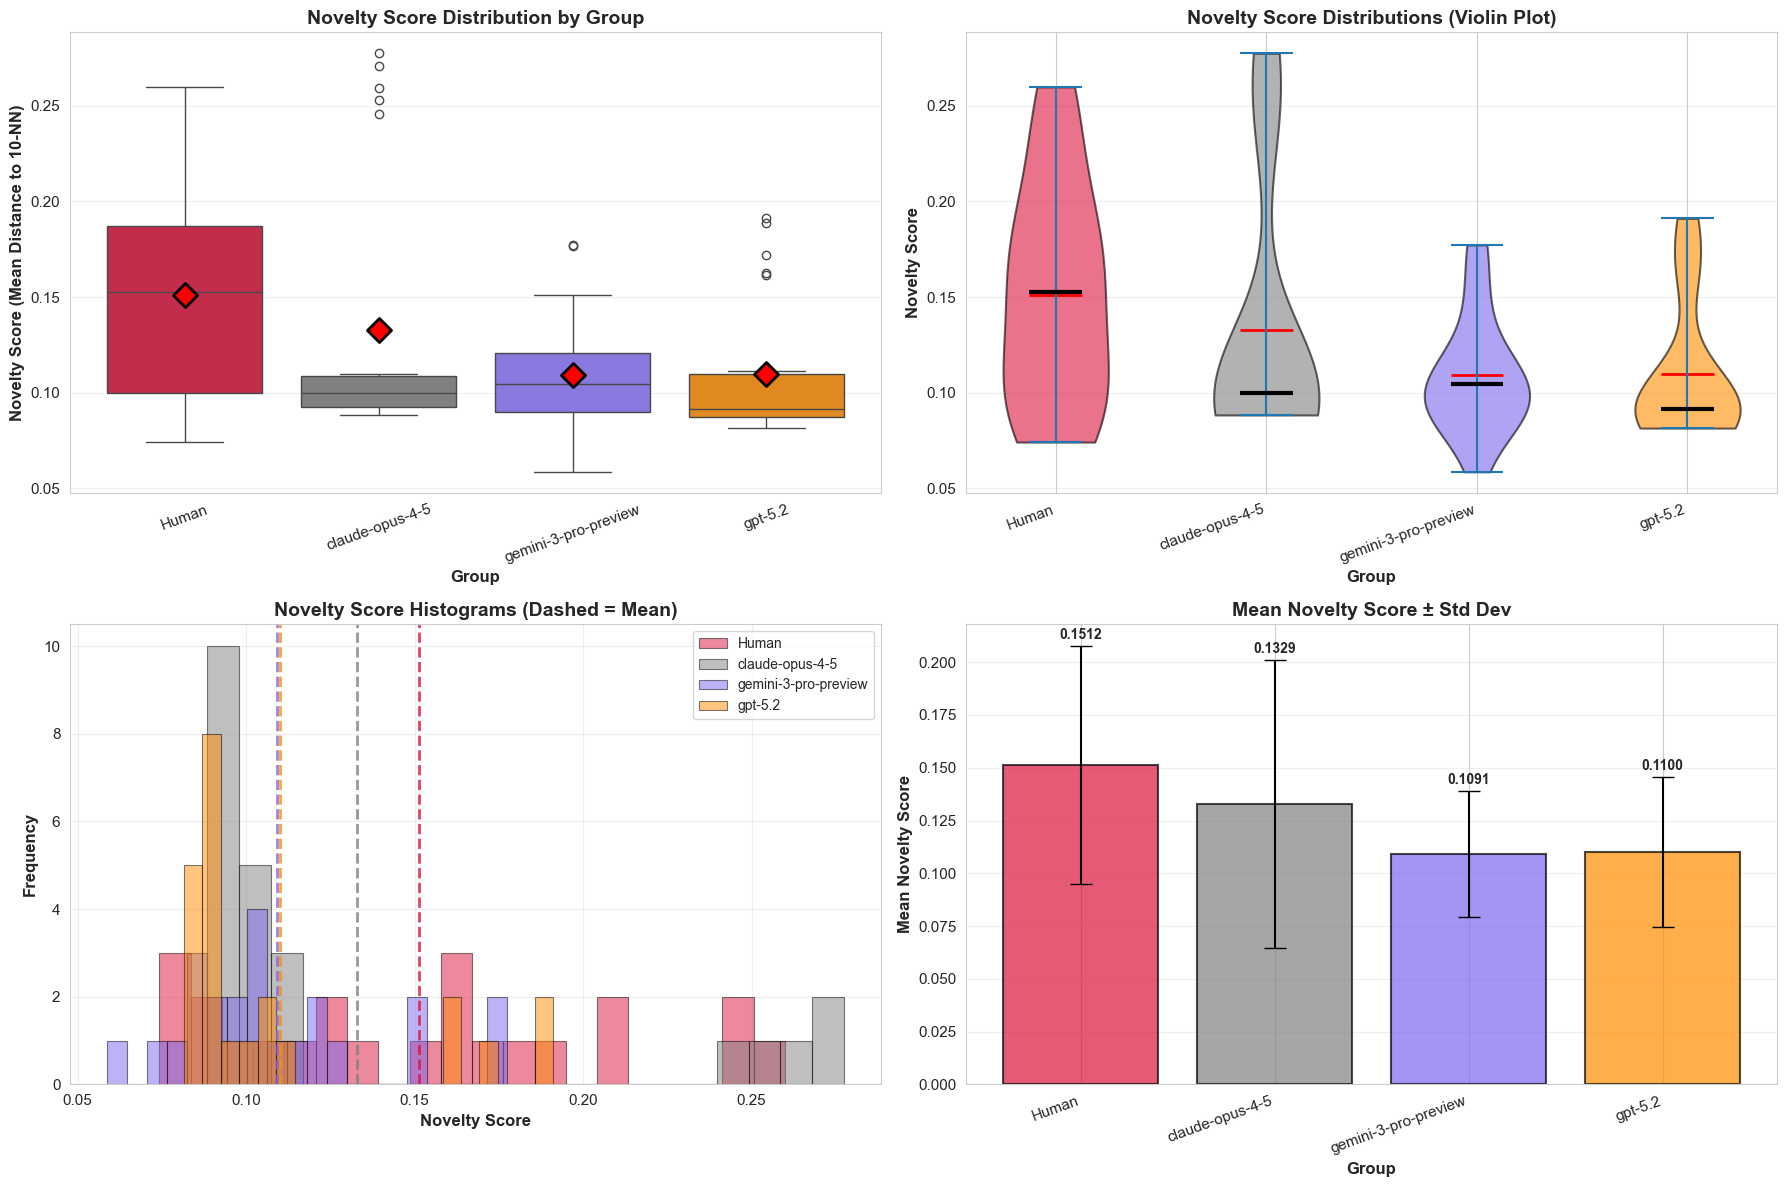


✓ Figure saved to: results/figures/novelty_analysis.png


In [ ]:
# Visualization: Novelty scores by group
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

group_order = ['Human'] + [m for m in ai_models if m in model_novelty_scores]

# PANEL 1: Box plots comparing novelty scores
ax1 = axes[0, 0]
novelty_data = []
for group in group_order:
    if group == 'Human':
        scores = human_novelty_scores
    else:
        scores = model_novelty_scores[group]
    
    for score in scores:
        novelty_data.append({'Novelty Score': score, 'Group': group})

novelty_df = pd.DataFrame(novelty_data)
palette_list = [colors.get(g, 'gray') for g in group_order]

sns.boxplot(data=novelty_df, x='Group', y='Novelty Score', ax=ax1, palette=palette_list, order=group_order)
ax1.set_ylabel('Novelty Score (Mean Distance to 10-NN)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Group', fontsize=12, fontweight='bold')
ax1.set_title('Novelty Score Distribution by Group', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
ax1.grid(alpha=0.3, axis='y')

# Add mean markers
for idx, group in enumerate(group_order):
    if group == 'Human':
        mean_val = human_novelty_scores.mean()
    else:
        mean_val = model_novelty_scores[group].mean()
    ax1.scatter(idx, mean_val, color='red', s=150, marker='D', zorder=10, edgecolors='black', linewidth=2)

# PANEL 2: Violin plots
ax2 = axes[0, 1]
parts = ax2.violinplot([novelty_df[novelty_df['Group']==g]['Novelty Score'].values for g in group_order],
                       positions=range(len(group_order)),
                       showmeans=True, showmedians=True, showextrema=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(palette_list[i])
    pc.set_alpha(0.6)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(3)
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)

ax2.set_xticks(range(len(group_order)))
ax2.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax2.set_ylabel('Novelty Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Group', fontsize=12, fontweight='bold')
ax2.set_title('Novelty Score Distributions (Violin Plot)', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# PANEL 3: Histogram of novelty scores
ax3 = axes[1, 0]
for group in group_order:
    if group == 'Human':
        scores = human_novelty_scores
    else:
        scores = model_novelty_scores[group]
    
    ax3.hist(scores, bins=20, alpha=0.5, label=group, 
            color=colors.get(group, 'gray'), edgecolor='black', linewidth=0.8)
    ax3.axvline(scores.mean(), color=colors.get(group, 'gray'), 
               linestyle='--', linewidth=2, alpha=0.8)

ax3.set_xlabel('Novelty Score', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Novelty Score Histograms (Dashed = Mean)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# PANEL 4: Bar chart with error bars
ax4 = axes[1, 1]
means = []
stds = []
for group in group_order:
    if group == 'Human':
        scores = human_novelty_scores
    else:
        scores = model_novelty_scores[group]
    means.append(scores.mean())
    stds.append(scores.std())

bars = ax4.bar(range(len(group_order)), means, yerr=stds, 
              color=[colors.get(g, 'gray') for g in group_order],
              edgecolor='black', linewidth=1.5, alpha=0.7, capsize=8)
ax4.set_xticks(range(len(group_order)))
ax4.set_xticklabels(group_order, rotation=20, ha='right', fontsize=11)
ax4.set_ylabel('Mean Novelty Score', fontsize=12, fontweight='bold')
ax4.set_xlabel('Group', fontsize=12, fontweight='bold')
ax4.set_title('Mean Novelty Score ± Std Dev', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean_val, std_val) in enumerate(zip(means, stds)):
    ax4.text(i, mean_val + std_val + 0.002, f'{mean_val:.4f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/novelty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/novelty_analysis.png")

## Step 7: Visualize Proposals in Literature Context

Show where proposals fall relative to existing literature in embedding space.

VISUALIZING PROPOSALS IN LITERATURE CONTEXT

Total embeddings: 442
  Literature: 350
  Human proposals: 23
  AI proposals: 69

Reducing to 2D using UMAP...
✓ UMAP completed


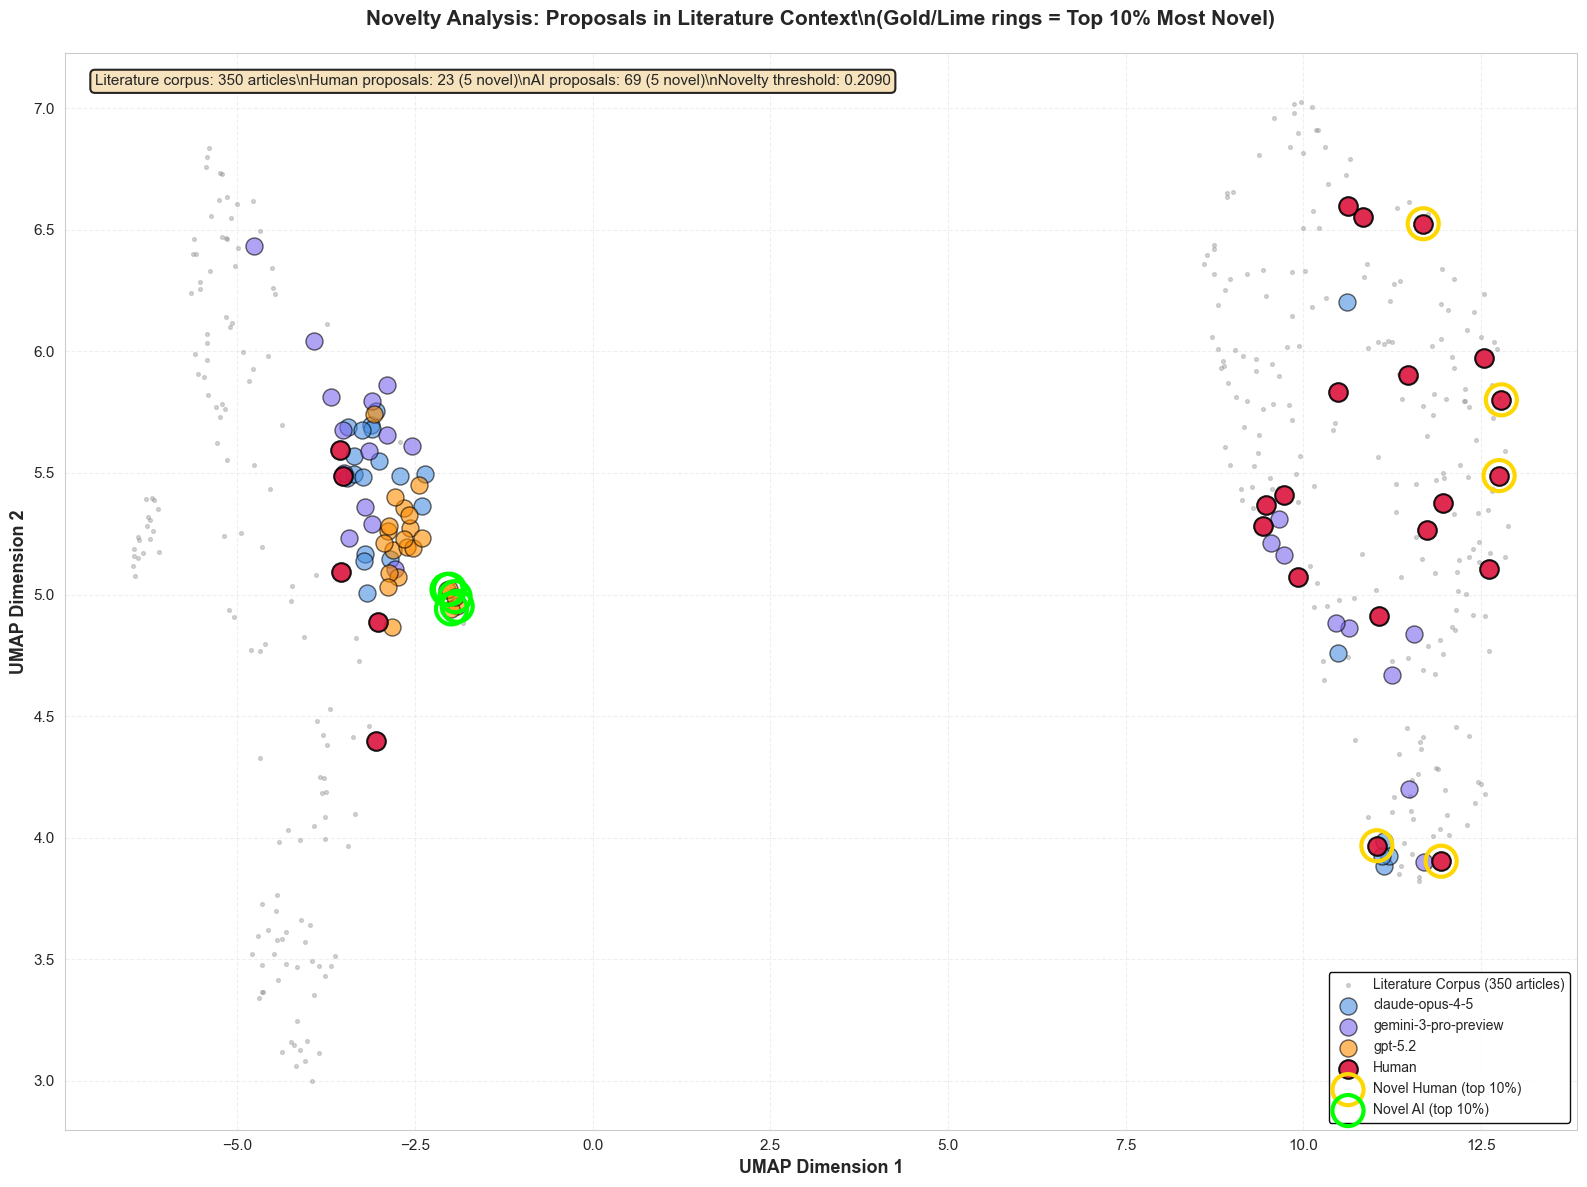


✓ Figure saved to: results/figures/novelty_embedding_space.png

💡 INTERPRETATION:
   - Gray dots = existing literature (context)
   - Colored points = proposals
   - Gold/Lime rings = top 10% most novel proposals
   - Proposals FAR from gray cloud = more novel
   - Proposals WITHIN gray cloud = building on existing work


In [ ]:
import umap
# Visualization: Embedding space with literature context
print("="*85)
print("VISUALIZING PROPOSALS IN LITERATURE CONTEXT")
print("="*85)

# Combine all embeddings: literature + proposals
all_combined = np.vstack([literature_embeddings, human_embeddings_abstract, ai_embeddings_abstract])
n_lit = len(literature_embeddings)
n_human_abs = len(human_embeddings_abstract)
n_ai_abs = len(ai_embeddings_abstract)

print(f"\nTotal embeddings: {len(all_combined)}")
print(f"  Literature: {n_lit}")
print(f"  Human proposals: {n_human_abs}")
print(f"  AI proposals: {n_ai_abs}")

# Apply UMAP to combined embeddings
print("\nReducing to 2D using UMAP...")
reducer_novelty = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_novelty = reducer_novelty.fit_transform(all_combined)

# Split back
literature_2d = embeddings_2d_novelty[:n_lit]
human_2d_abs = embeddings_2d_novelty[n_lit:n_lit+n_human_abs]
ai_2d_abs = embeddings_2d_novelty[n_lit+n_human_abs:]

# Split AI by model (mask-based; do NOT assume contiguous blocks)
if 'ai_df' not in globals() or 'model' not in ai_df.columns:
    raise RuntimeError("ai_df with a 'model' column is required for per-model plotting in abstract space")

ai_model_series = ai_df['model'].astype(str).values

print(f"✓ UMAP completed")

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

# Plot literature corpus first (as background context)
ax.scatter(literature_2d[:, 0], literature_2d[:, 1],
          c='#8A8A8A',
          label='Literature Corpus (350 articles)',
          s=30,
          alpha=0.35,
          marker='.',
          zorder=1)

# Plot AI models (mask-based)
for model in ai_models:
    mask = ai_model_series == str(model)
    if np.any(mask):
        pts = ai_2d_abs[mask]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=colors.get(model, '#808080'),
                   label=model,
                   s=150,
                   alpha=0.6,
                   edgecolors='black',
                   linewidth=1.0,
                   zorder=5)

# Plot human proposals on top (most prominent)
ax.scatter(human_2d_abs[:, 0], human_2d_abs[:, 1],
          c=colors['Human'],
          label='Human',
          s=180,
          alpha=0.9,
          edgecolors='black',
          linewidth=1.5,
          marker='o',
          zorder=10)

# Identify top 10% most novel proposals (highest novelty scores)
all_novelty_scores = np.concatenate([human_novelty_scores, ai_novelty_scores])
novelty_threshold = np.percentile(all_novelty_scores, 90)
novel_proposals = all_novelty_scores > novelty_threshold

# Split into human and AI novel proposals
novel_human = human_novelty_scores > novelty_threshold
novel_ai = ai_novelty_scores > novelty_threshold

# Highlight novel proposals
human_2d_novel = human_2d_abs[novel_human]
ai_2d_novel = ai_2d_abs[novel_ai]

if len(human_2d_novel) > 0:
    ax.scatter(human_2d_novel[:, 0], human_2d_novel[:, 1],
              s=500,
              facecolors='none',
              edgecolors='gold',
              linewidth=3,
              alpha=1.0,
              zorder=12,
              label=f'Novel Human (top 10%)')

if len(ai_2d_novel) > 0:
    ax.scatter(ai_2d_novel[:, 0], ai_2d_novel[:, 1],
              s=500,
              facecolors='none',
              edgecolors='lime',
              linewidth=3,
              alpha=1.0,
              zorder=12,
              label=f'Novel AI (top 10%)')

# Labels and formatting
ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax.set_title('Novelty Analysis: Proposals in Literature Context\\n(Gold/Lime rings = Top 10% Most Novel)',
            fontsize=15, fontweight='bold', pad=20)

# Legend
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add text annotation
textstr = f'Literature corpus: {n_lit} articles\\n'
textstr += f'Human proposals: {n_human_abs} ({novel_human.sum()} novel)\\n'
textstr += f'AI proposals: {n_ai_abs} ({novel_ai.sum()} novel)\\n'
textstr += f'Novelty threshold: {novelty_threshold:.4f}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('results/figures/novelty_embedding_space.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/novelty_embedding_space.png")
print("\n💡 INTERPRETATION:")
print("   - Gray dots = existing literature (context)")
print("   - Colored points = proposals")
print("   - Gold/Lime rings = top 10% most novel proposals")
print("   - Proposals FAR from gray cloud = more novel")
print("   - Proposals WITHIN gray cloud = building on existing work")
print("="*85)

## Additional Analysis: Examine Nearest Neighbors in Literature

For the most and least novel proposals, identify which literature articles are closest.

In [ ]:
# Examine most and least novel proposals
print("="*85)
print("EXAMINING MOST AND LEAST NOVEL PROPOSALS")
print("="*85)

# Find most novel human proposal
most_novel_human_idx = human_novelty_scores.argmax()
most_novel_human_score = human_novelty_scores[most_novel_human_idx]
most_novel_human_title = human_df.iloc[most_novel_human_idx]['proposal_title']

print(f"\n🏆 MOST NOVEL HUMAN PROPOSAL:")
print(f"  Title: {most_novel_human_title}")
print(f"  Novelty Score: {most_novel_human_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(human_nn_indices[most_novel_human_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([human_embeddings_abstract[most_novel_human_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find least novel human proposal
least_novel_human_idx = human_novelty_scores.argmin()
least_novel_human_score = human_novelty_scores[least_novel_human_idx]
least_novel_human_title = human_df.iloc[least_novel_human_idx]['proposal_title']

print(f"\n📚 LEAST NOVEL HUMAN PROPOSAL:")
print(f"  Title: {least_novel_human_title}")
print(f"  Novelty Score: {least_novel_human_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(human_nn_indices[least_novel_human_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([human_embeddings_abstract[least_novel_human_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find most novel AI proposal
most_novel_ai_idx = ai_novelty_scores.argmax()
most_novel_ai_score = ai_novelty_scores[most_novel_ai_idx]
most_novel_ai_title = ai_df.iloc[most_novel_ai_idx]['title']
most_novel_ai_model = ai_df.iloc[most_novel_ai_idx]['model']

print(f"\n🏆 MOST NOVEL AI PROPOSAL:")
print(f"  Model: {most_novel_ai_model}")
print(f"  Title: {most_novel_ai_title}")
print(f"  Novelty Score: {most_novel_ai_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(ai_nn_indices[most_novel_ai_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([ai_embeddings_abstract[most_novel_ai_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

# Find least novel AI proposal
least_novel_ai_idx = ai_novelty_scores.argmin()
least_novel_ai_score = ai_novelty_scores[least_novel_ai_idx]
least_novel_ai_title = ai_df.iloc[least_novel_ai_idx]['title']
least_novel_ai_model = ai_df.iloc[least_novel_ai_idx]['model']

print(f"\n📚 LEAST NOVEL AI PROPOSAL:")
print(f"  Model: {least_novel_ai_model}")
print(f"  Title: {least_novel_ai_title}")
print(f"  Novelty Score: {least_novel_ai_score:.4f}")
print(f"  Nearest neighbors in literature:")
for j, lit_idx in enumerate(ai_nn_indices[least_novel_ai_idx][:5]):
    lit_article = articles[lit_idx]
    dist = cosine_distances([ai_embeddings_abstract[least_novel_ai_idx]], [literature_embeddings[lit_idx]])[0][0]
    print(f"    {j+1}. [{lit_article['pmid']}] {lit_article['title'][:80]}...")
    print(f"       Distance: {dist:.4f}, Published: {lit_article['publication_date']}")

print("="*85)

EXAMINING MOST AND LEAST NOVEL PROPOSALS

🏆 MOST NOVEL HUMAN PROPOSAL:
  Title: CYTOKINETIC BOTTLENECKS OF HEAT WAVES
  Novelty Score: 0.2598
  Nearest neighbors in literature:
    1. [39389033] MX2 forms nucleoporin-comprising cytoplasmic biomolecular condensates that lure ...
       Distance: 0.2439, Published: 2024 Oct 9
    2. [32151949] Emergent properties of mitotic chromosomes....
       Distance: 0.2470, Published: 2020 Jun
    3. [31086336] Molecular recording of mammalian embryogenesis....
       Distance: 0.2541, Published: 2019 Jun
    4. [29937223] mTORC1 Controls Phase Separation and the Biophysical Properties of the Cytoplasm...
       Distance: 0.2565, Published: 2018 Jul 12
    5. [34850074] 3D mesoscopic architecture of a heterogeneous cellular network in the cementum-p...
       Distance: 0.2568, Published: 2022 Jan 29

📚 LEAST NOVEL HUMAN PROPOSAL:
  Title: Elucidating genome structure-function relationships in human brain cells
  Novelty Score: 0.0742
  Nearest nei

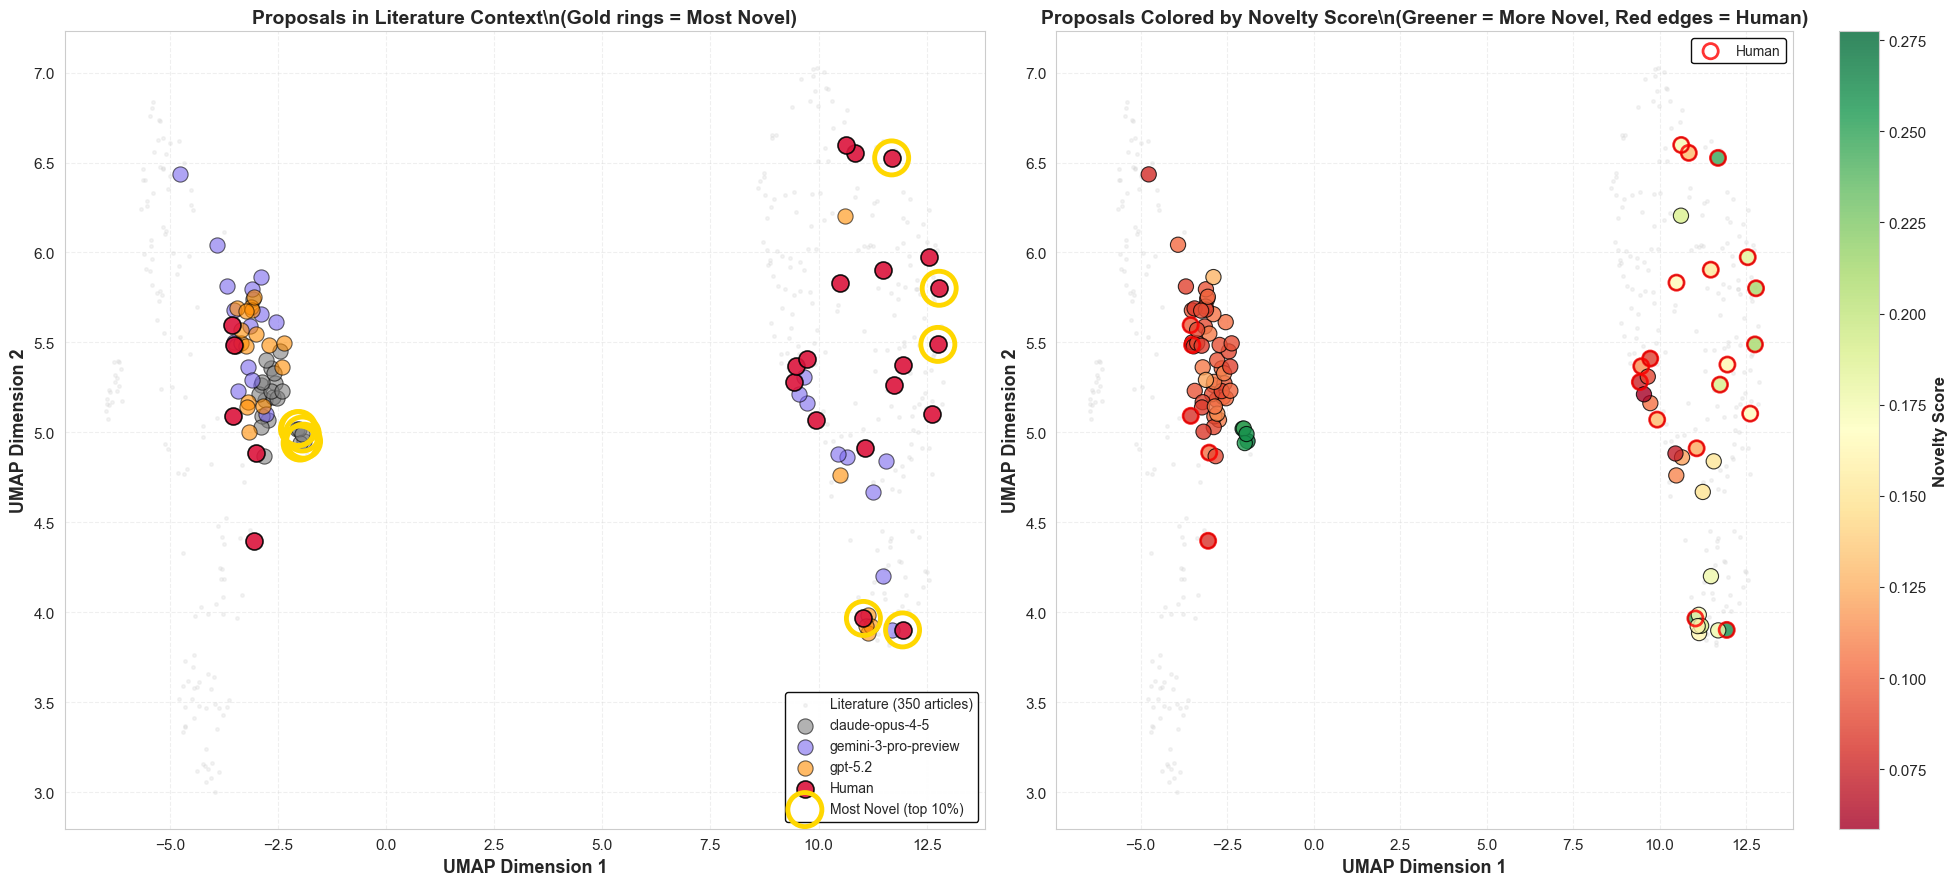


✓ Figure saved to: results/figures/novelty_embedding_space_detailed.png


In [ ]:
# Create detailed 2D visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Color scheme
colors_nov = {
    'Human': '#DC143C',  # Crimson red
    'claude-opus-4-6': '#4A90E2',  # Blue
    'gemini-3-pro-preview': '#7B68EE',  # Purple
    'gpt-5.2': '#FF8C00',  # Dark orange
}

# PANEL 1: Full view with literature context
ax1 = axes[0]

# Literature (gray background)
ax1.scatter(literature_2d[:, 0], literature_2d[:, 1],
          c='#8A8A8A',
          label='Literature (350 articles)',
          s=25,
          alpha=0.25,
          marker='.',
          zorder=1)

# AI proposals
for model in ai_models:
    if model in model_2d_abs:
        ax1.scatter(model_2d_abs[model][:, 0], model_2d_abs[model][:, 1],
                  c=colors_nov.get(model, '#808080'),
                  label=model,
                  s=120,
                  alpha=0.6,
                  edgecolors='black',
                  linewidth=0.8,
                  zorder=5)

# Human proposals (most prominent)
ax1.scatter(human_2d_abs[:, 0], human_2d_abs[:, 1],
          c=colors_nov['Human'],
          label='Human',
          s=150,
          alpha=0.9,
          edgecolors='black',
          linewidth=1.2,
          marker='o',
          zorder=10)

# Highlight most novel proposals
all_2d_proposals = np.vstack([human_2d_abs, ai_2d_abs])
novel_proposals_2d = all_2d_proposals[novel_proposals]

ax1.scatter(novel_proposals_2d[:, 0], novel_proposals_2d[:, 1],
          s=600,
          facecolors='none',
          edgecolors='gold',
          linewidth=3.5,
          alpha=1.0,
          zorder=15,
          label=f'Most Novel (top 10%)')

ax1.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax1.set_title('Proposals in Literature Context\\n(Gold rings = Most Novel)',
            fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax1.grid(True, alpha=0.3, linestyle='--')

# PANEL 2: Novelty score visualization (color-coded by score)
ax2 = axes[1]

# Literature (gray background)
ax2.scatter(literature_2d[:, 0], literature_2d[:, 1],
          c='#8A8A8A',
          s=25,
          alpha=0.25,
          marker='.',
          zorder=1)

# All proposals colored by novelty score
all_2d_proposals = np.vstack([human_2d_abs, ai_2d_abs])
all_novelty = np.concatenate([human_novelty_scores, ai_novelty_scores])

scatter = ax2.scatter(all_2d_proposals[:, 0], all_2d_proposals[:, 1],
                     c=all_novelty,
                     s=120,
                     alpha=0.8,
                     cmap='RdYlGn',
                     edgecolors='black',
                     linewidth=0.8,
                     zorder=5)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Novelty Score', fontsize=12, fontweight='bold')

# Highlight human vs AI with edge colors
ax2.scatter(human_2d_abs[:, 0], human_2d_abs[:, 1],
          s=120,
          facecolors='none',
          edgecolors='red',
          linewidth=2,
          alpha=0.8,
          zorder=8,
          label='Human')

ax2.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
ax2.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
ax2.set_title('Proposals Colored by Novelty Score\\n(Greener = More Novel, Red edges = Human)',
            fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='black')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('results/figures/novelty_embedding_space_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved to: results/figures/novelty_embedding_space_detailed.png")
print("="*85)

---

# PART III: THEMATIC AND CLUSTER ANALYSIS

Examine whether human and AI proposals cluster in distinct semantic regions and differ in thematic coverage.

**⚠️ Sample Size Note:** With n=23 human and n=69 AI proposals, we use conservative approaches with strong regularization and permutation-based validation.

## Analysis 3.1: Topic Modeling (LDA - Exploratory)

Use Latent Dirichlet Allocation with strong priors to identify thematic topics. LDA is more stable than BERTopic for small samples.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*85)
print("TOPIC MODELING WITH LDA (EXPLORATORY)")
print("="*85)

# Prepare FULL DRAFT for topic modeling
ai_abstracts = ai_df['full_text'].fillna('').tolist()
human_abstracts = human_df['full_text'].fillna('').tolist()
all_abstracts = human_abstracts + ai_abstracts

# Create source labels
source_labels = ['Human'] * len(human_abstracts) + ['AI'] * len(ai_abstracts)
model_labels = ['Human'] * len(human_abstracts) + ai_df['model'].tolist()

print(f"\n✓ Prepared {len(all_abstracts)} abstracts")
print(f"  Human: {len(human_abstracts)}, AI: {len(ai_abstracts)}")

# Create document-term matrix with CountVectorizer (LDA requires counts, not TF-IDF)
#
# NOTE: In biology abstracts, very common background words (e.g., "cell") often
# appear in many topics and reduce interpretability. To improve topic specificity,
# we (1) detect corpus-specific high document-frequency UNIGRAMS and (2) drop only
# those UNIGRAM features while keeping informative BIGRAMS like "single cell".

# 1) Detect high document-frequency unigrams in THIS corpus
_unigram_probe = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 1),
    min_df=2,
    max_df=1.0,
    max_features=5000
)
_unigram_X = _unigram_probe.fit_transform(all_abstracts)
_unigram_terms = _unigram_probe.get_feature_names_out()
_unigram_df = np.asarray((_unigram_X > 0).mean(axis=0)).ravel()  # fraction of docs containing term

# Auto-stopwords: appear in >= 50% of documents (tune threshold if needed)
auto_domain_unigram_stopwords = set(_unigram_terms[_unigram_df >= 0.50])

# Manual additions (keep small; auto list usually does most of the work)
manual_domain_unigram_stopwords = {
    'cell', 'cells',
    'protein', 'proteins',
    'project', 'using', 'nup', '000', 'nan', 'fg', 'npc', 'ii', 'et'
}

domain_unigram_stopwords = auto_domain_unigram_stopwords | manual_domain_unigram_stopwords

_top_common_idx = np.argsort(_unigram_df)[-20:][::-1]
print("\nMost common unigrams in corpus (doc frequency):")
for i in _top_common_idx:
    print(f"  {_unigram_terms[i]}: {_unigram_df[i]:.2f}")
print(f"\n✓ Domain unigram stopwords (auto+manual): {len(domain_unigram_stopwords)}")

# 2) Build unigram+bigram counts, then remove only stopword UNIGRAM features
print("\nCreating document-term matrix...")
vectorizer = CountVectorizer(
    max_features=2000,
    min_df=2,  # Minimum 2 documents
    max_df=0.7,  # Maximum 70% of documents
    stop_words='english',
    ngram_range=(1, 2)  # Unigrams and bigrams
)

_doc_term_matrix_full = vectorizer.fit_transform(all_abstracts)
_feature_names_full = np.array(vectorizer.get_feature_names_out())

_unigram_mask = np.array([' ' not in t for t in _feature_names_full])
_drop_mask = _unigram_mask & np.isin(_feature_names_full, list(domain_unigram_stopwords))
_keep_mask = ~_drop_mask

doc_term_matrix = _doc_term_matrix_full[:, _keep_mask]
feature_names = _feature_names_full[_keep_mask]

print(f"✓ Document-term matrix: {doc_term_matrix.shape}")
print(f"  Documents: {doc_term_matrix.shape[0]}, Vocabulary: {doc_term_matrix.shape[1]}")
print(f"  Dropped domain unigrams: {_drop_mask.sum()} (kept bigrams intact)")

# Fit LDA with strong priors for stability
print("\nFitting LDA with conservative parameters...")
print("  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)")

n_topics = 5
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=0.5,  # alpha - stronger prior for document regularization
    topic_word_prior=0.5,  # beta - stronger prior for topic regularization
    max_iter=100,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)

doc_topic_dist = lda_model.fit_transform(doc_term_matrix)

print(f"✓ LDA fitted")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"  Log-likelihood: {lda_model.score(doc_term_matrix):.2f}")

# Extract top words per topic
def display_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

topics = display_topics(lda_model, feature_names, n_top_words=10)

print("\n" + "="*85)
print("TOP 10 WORDS PER TOPIC")
print("="*85)
for i, topic_words in enumerate(topics):
    print(f"\nTopic {i+1}: {', '.join(topic_words)}")

# Store document-topic distributions
doc_topic_df = pd.DataFrame(doc_topic_dist, columns=[f'Topic_{i+1}' for i in range(n_topics)])
doc_topic_df['source'] = source_labels
doc_topic_df['model'] = model_labels
doc_topic_df['group'] = ['Human' if s == 'Human' else 'AI' for s in source_labels]

# Assign dominant topic to each document
doc_topic_df['dominant_topic'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].idxmax(axis=1)
doc_topic_df['dominant_topic_prob'] = doc_topic_df[[f'Topic_{i+1}' for i in range(n_topics)]].max(axis=1)

print("\n" + "="*85)
print("DOCUMENT-TOPIC DISTRIBUTION SUMMARY")
print("="*85)
print(f"\nMean topic probabilities per document:")
for i in range(n_topics):
    print(f"  Topic {i+1}: {doc_topic_df[f'Topic_{i+1}'].mean():.3f} ± {doc_topic_df[f'Topic_{i+1}'].std():.3f}")

print(f"\nDominant topic assignment:")
print(doc_topic_df['dominant_topic'].value_counts().sort_index())

print("\n⚠️ LABEL AS EXPLORATORY - Small sample size limits topic stability")
print("="*85)

TOPIC MODELING WITH LDA (EXPLORATORY)

✓ Prepared 92 abstracts
  Human: 23, AI: 69

Most common unigrams in corpus (doc frequency):
  data: 1.00
  abstract: 1.00
  title: 1.00
  project: 1.00
  outcomes: 0.99
  computational: 0.99
  datasets: 0.98
  integration: 0.96
  models: 0.96
  biology: 0.93
  understanding: 0.93
  model: 0.92
  single: 0.92
  research: 0.91
  synthesis: 0.91
  methods: 0.91
  expertise: 0.89
  emergent: 0.88
  questions: 0.88
  analysis: 0.88

✓ Domain unigram stopwords (auto+manual): 241

Creating document-term matrix...
✓ Document-term matrix: (92, 1836)
  Documents: 92, Vocabulary: 1836
  Dropped domain unigrams: 164 (kept bigrams intact)

Fitting LDA with conservative parameters...
  n_topics=5, alpha=0.5, beta=0.5 (strong regularization)
✓ LDA fitted
  Perplexity: 1207.75
  Log-likelihood: -630752.69

TOP 10 WORDS PER TOPIC

Topic 1: mechanical, membrane, cryo, seq, ribosome, physical, image, cryo et, cytoskeletal, microscopy

Topic 2: transport, diffusion,

In [ ]:
# Stability check: Run LDA with multiple random seeds
# IMPORTANT: LDA topics can permute across random seeds ("label switching").
# This version ALIGNs topics to a reference run before computing stability.

from scipy.optimize import linear_sum_assignment

print("="*85)
print("TOPIC STABILITY VALIDATION")
print("="*85)
print("Running LDA with 10 different random seeds to assess stability (with topic alignment)...")

n_stability_runs = 10
n_top_words = 10

stability_topics = []      # list[run] -> list[topic] -> list[str]
stability_topic_dists = [] # list[run] -> ndarray (n_topics, vocab)

for seed in range(n_stability_runs):
    lda_temp = LatentDirichletAllocation(
        n_components=n_topics,
        doc_topic_prior=0.5,
        topic_word_prior=0.5,
        max_iter=100,
        learning_method='batch',
        random_state=seed,
        n_jobs=-1
    )
    lda_temp.fit(doc_term_matrix)

    # Normalize to topic-word probabilities for similarity comparisons
    topic_word = lda_temp.components_.astype(float)
    topic_word = topic_word / topic_word.sum(axis=1, keepdims=True)

    topics_temp = display_topics(lda_temp, feature_names, n_top_words=n_top_words)
    stability_topics.append(topics_temp)
    stability_topic_dists.append(topic_word)

print(f"✓ Completed {n_stability_runs} stability runs")

# Reference run (seed=0)
ref_words_by_topic = [set(ws) for ws in stability_topics[0]]
ref_dist = stability_topic_dists[0]

def _cosine_sim_matrix(A, B, eps=1e-12):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return A @ B.T

# Collect aligned stability metrics
per_topic_overlap_all = [[] for _ in range(n_topics)]
per_topic_cos_all = [[] for _ in range(n_topics)]

print("\nTopic stability (aligned to reference run):")
for run_idx in range(1, n_stability_runs):
    run_dist = stability_topic_dists[run_idx]
    sim = _cosine_sim_matrix(run_dist, ref_dist)  # (run_topic, ref_topic)

    # Hungarian assignment to maximize total similarity
    row_ind, col_ind = linear_sum_assignment(-sim)

    # Build aligned words and aligned cosine per reference topic
    aligned_words = [None] * n_topics
    aligned_cos = np.zeros(n_topics, dtype=float)
    for r_topic, ref_topic in zip(row_ind, col_ind):
        aligned_words[ref_topic] = set(stability_topics[run_idx][r_topic])
        aligned_cos[ref_topic] = sim[r_topic, ref_topic]

    # Per-topic overlap (top words) + cosine similarity (full distributions)
    overlaps = []
    for k in range(n_topics):
        overlap = len(ref_words_by_topic[k] & aligned_words[k]) / max(1, len(ref_words_by_topic[k]))
        overlaps.append(overlap)
        per_topic_overlap_all[k].append(overlap)
        per_topic_cos_all[k].append(aligned_cos[k])

    print(
        f"  Run {run_idx}: "
        f"mean top-{n_top_words} overlap={np.mean(overlaps):.1%}, "
        f"mean cosine={np.mean(aligned_cos):.3f}"
    )

print("\nPer-topic stability (mean across aligned runs):")
for k in range(n_topics):
    print(
        f"  Topic {k+1}: "
        f"{np.mean(per_topic_overlap_all[k]):.1%} ± {np.std(per_topic_overlap_all[k]):.1%} top-{n_top_words} overlap, "
        f"{np.mean(per_topic_cos_all[k]):.3f} ± {np.std(per_topic_cos_all[k]):.3f} cosine"
    )

print("\n💡 If overlap/cosine are still very low AFTER alignment, that reflects true instability.")
print("="*85)


TOPIC STABILITY VALIDATION
Running LDA with 10 different random seeds to assess stability (with topic alignment)...
✓ Completed 10 stability runs

Topic stability (aligned to reference run):
  Run 1: mean top-10 overlap=64.0%, mean cosine=0.867
  Run 2: mean top-10 overlap=62.0%, mean cosine=0.835
  Run 3: mean top-10 overlap=46.0%, mean cosine=0.810
  Run 4: mean top-10 overlap=58.0%, mean cosine=0.772
  Run 5: mean top-10 overlap=54.0%, mean cosine=0.766
  Run 6: mean top-10 overlap=56.0%, mean cosine=0.790
  Run 7: mean top-10 overlap=50.0%, mean cosine=0.789
  Run 8: mean top-10 overlap=62.0%, mean cosine=0.815
  Run 9: mean top-10 overlap=66.0%, mean cosine=0.879

Per-topic stability (mean across aligned runs):
  Topic 1: 77.8% ± 14.0% top-10 overlap, 0.963 ± 0.034 cosine
  Topic 2: 32.2% ± 16.2% top-10 overlap, 0.649 ± 0.202 cosine
  Topic 3: 45.6% ± 21.7% top-10 overlap, 0.701 ± 0.149 cosine
  Topic 4: 50.0% ± 14.1% top-10 overlap, 0.785 ± 0.077 cosine
  Topic 5: 82.2% ± 19.9% t

## Analysis 3.2: Topic Distribution Comparison

Test whether topic distributions differ between human and AI proposals using permutation tests and Fisher's exact tests.

In [ ]:
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

print("="*85)
print("TOPIC DISTRIBUTION COMPARISON")
print("="*85)

# Create contingency table: topics × source
contingency_table = pd.crosstab(doc_topic_df['dominant_topic'], doc_topic_df['group'])
print("\nContingency table (dominant topic × source):")
print(contingency_table)
print(f"\nRow percentages:")
print(pd.crosstab(doc_topic_df['dominant_topic'], doc_topic_df['group'], normalize='index').round(3))

# Permutation test for overall distribution difference
print("\n" + "-"*85)
print("PERMUTATION TEST: Overall topic distribution difference")
print("-"*85)

def compute_chi_square_stat(contingency):
    """Compute chi-square statistic from contingency table"""
    return chi2_contingency(contingency)[0]

observed_chi2 = compute_chi_square_stat(contingency_table)
print(f"Observed chi-square statistic: {observed_chi2:.4f}")

# Permutation test
n_permutations = 10000
perm_chi2_stats = []

for _ in range(n_permutations):
    # Shuffle source labels
    shuffled_labels = np.random.permutation(doc_topic_df['group'].values)
    perm_contingency = pd.crosstab(doc_topic_df['dominant_topic'], shuffled_labels)
    perm_chi2 = compute_chi_square_stat(perm_contingency)
    perm_chi2_stats.append(perm_chi2)

perm_chi2_stats = np.array(perm_chi2_stats)
p_value_perm = np.mean(perm_chi2_stats >= observed_chi2)

print(f"\nPermutation test results ({n_permutations:,} permutations):")
print(f"  Null mean chi-square: {perm_chi2_stats.mean():.4f} ± {perm_chi2_stats.std():.4f}")
print(f"  Observed chi-square: {observed_chi2:.4f}")
print(f"  p-value: {p_value_perm:.4f}")

if p_value_perm < 0.05:
    print(f"  → Significant difference in topic distributions (p < 0.05)")
else:
    print(f"  → No significant difference in topic distributions (p ≥ 0.05)")

# Per-topic Fisher's exact tests
print("\n" + "-"*85)
print("PER-TOPIC TESTS: Fisher's Exact (Human vs. All AI)")
print("-"*85)

fisher_results = []

for topic in contingency_table.index:
    # Create 2×2 table for this topic
    topic_yes = contingency_table.loc[topic, :]
    topic_no = contingency_table.drop(topic).sum(axis=0)
    
    table_2x2 = np.array([
        [topic_yes['Human'], topic_yes['AI']],
        [topic_no['Human'], topic_no['AI']]
    ])
    
    odds_ratio, p_value = fisher_exact(table_2x2)
    
    # Calculate percentages
    human_pct = topic_yes['Human'] / contingency_table['Human'].sum() * 100
    ai_pct = topic_yes['AI'] / contingency_table['AI'].sum() * 100
    
    fisher_results.append({
        'topic': topic,
        'human_count': topic_yes['Human'],
        'ai_count': topic_yes['AI'],
        'human_pct': human_pct,
        'ai_pct': ai_pct,
        'odds_ratio': odds_ratio,
        'p_value': p_value
    })

fisher_df = pd.DataFrame(fisher_results)

# Apply FDR correction (Benjamini-Hochberg at q=0.10 for exploratory)
fisher_df['p_value_fdr'] = multipletests(fisher_df['p_value'], method='fdr_bh', alpha=0.10)[1]

print(f"\n{'Topic':<12} {'Human %':<10} {'AI %':<10} {'OR':<8} {'p-value':<10} {'FDR q':<10} {'Result'}")
print("-"*85)

for _, row in fisher_df.iterrows():
    sig_mark = '***' if row['p_value_fdr'] < 0.01 else '**' if row['p_value_fdr'] < 0.05 else '*' if row['p_value_fdr'] < 0.10 else ''
    direction = 'Human↑' if row['odds_ratio'] > 1 else 'AI↑' if row['odds_ratio'] < 1 else 'Equal'
    
    print(f"{row['topic']:<12} {row['human_pct']:<10.1f} {row['ai_pct']:<10.1f} {row['odds_ratio']:<8.2f} "
          f"{row['p_value']:<10.4f} {row['p_value_fdr']:<10.4f} {direction} {sig_mark}")

print("\n*** p<0.01, ** p<0.05, * p<0.10 (FDR-corrected)")
print("OR > 1 = over-represented in human; OR < 1 = over-represented in AI")

print("="*85)

TOPIC DISTRIBUTION COMPARISON

Contingency table (dominant topic × source):
group           AI  Human
dominant_topic           
Topic_1         26      0
Topic_2         10      0
Topic_3          0     23
Topic_4         15      0
Topic_5         18      0

Row percentages:
group            AI  Human
dominant_topic            
Topic_1         1.0    0.0
Topic_2         1.0    0.0
Topic_3         0.0    1.0
Topic_4         1.0    0.0
Topic_5         1.0    0.0

-------------------------------------------------------------------------------------
PERMUTATION TEST: Overall topic distribution difference
-------------------------------------------------------------------------------------
Observed chi-square statistic: 92.0000

Permutation test results (10,000 permutations):
  Null mean chi-square: 4.0611 ± 2.7906
  Observed chi-square: 92.0000
  p-value: 0.0000
  → Significant difference in topic distributions (p < 0.05)

-------------------------------------------------------------------

### key question: does this mean “Humans and AI have totally different topics”?

Not necessarily. With topic models, this kind of perfect separation is a red flag that the topics may be picking up systematic stylistic / templating / preprocessing artifacts rather than genuine scientific themes.

Common causes:
* Single “methodology/meta” topic (your Topic 3 looked like “modeling/principles/properties…”) that Humans disproportionately use, while AI texts spread across more concrete assay/mechanism words—or vice versa.
* Distribution shift in writing style: AI tends to reuse certain phrasing patterns (“open”, “datasets”, “emergent”, etc.), and LDA can latch onto that as “topics.”
* Instability / label switching effects: if topics move around across seeds, “Topic_3” being the human bucket could be an artifact of one fit.
* Dominant-topic argmax is brittle: it throws away the mixture information and can exaggerate separation.

What low-level conclusion is safe here
Given this fitted model, dominant-topic assignment perfectly predicts Human vs AI in your sample. That’s what your contingency table and tests are measuring.

In [ ]:
# Subsample validation to account for group size imbalance (23 human vs 69 AI)
print("="*85)
print("SUBSAMPLE VALIDATION (Accounting for 3:1 group size imbalance)")
print("="*85)
print("Subsampling AI to n=23, repeating 1000 times...")

n_subsamples = 1000
subsample_results = {topic: [] for topic in contingency_table.index}

for _ in range(n_subsamples):
    # Subsample AI to match human sample size
    ai_indices = doc_topic_df[doc_topic_df['group'] == 'AI'].index
    sampled_indices = np.random.choice(ai_indices, size=len(human_abstracts), replace=False)
    
    # Create balanced dataset
    balanced_df = pd.concat([
        doc_topic_df[doc_topic_df['group'] == 'Human'],
        doc_topic_df.loc[sampled_indices]
    ])
    
    # Test each topic
    for topic in contingency_table.index:
        human_has_topic = (balanced_df[balanced_df['group'] == 'Human']['dominant_topic'] == topic).sum()
        ai_has_topic = (balanced_df[balanced_df['group'] == 'AI']['dominant_topic'] == topic).sum()
        
        # 2×2 table
        table = np.array([
            [human_has_topic, len(human_abstracts) - human_has_topic],
            [ai_has_topic, len(human_abstracts) - ai_has_topic]
        ])
        
        _, p_val = fisher_exact(table)
        subsample_results[topic].append(p_val)

print("\nSubsample validation results:")
print(f"{'Topic':<12} {'Sig. in N subsamples':<25} {'Proportion':<12} {'Interpretation'}")
print("-"*85)

for topic in contingency_table.index:
    p_values = subsample_results[topic]
    n_significant = sum(np.array(p_values) < 0.05)
    proportion = n_significant / n_subsamples
    
    interpretation = "Robust" if proportion > 0.8 else "Moderate" if proportion > 0.5 else "Weak"
    print(f"{topic:<12} {n_significant}/{n_subsamples:<20} {proportion:<12.2%} {interpretation}")

print("\n💡 Proportion >80% = robust difference even with balanced sample sizes")
print("="*85)

SUBSAMPLE VALIDATION (Accounting for 3:1 group size imbalance)
Subsampling AI to n=23, repeating 1000 times...

Subsample validation results:
Topic        Sig. in N subsamples      Proportion   Interpretation
-------------------------------------------------------------------------------------
Topic_1      989/1000                 98.90%       Robust
Topic_2      185/1000                 18.50%       Weak
Topic_3      1000/1000                 100.00%      Robust
Topic_4      632/1000                 63.20%       Moderate
Topic_5      788/1000                 78.80%       Moderate

💡 Proportion >80% = robust difference even with balanced sample sizes


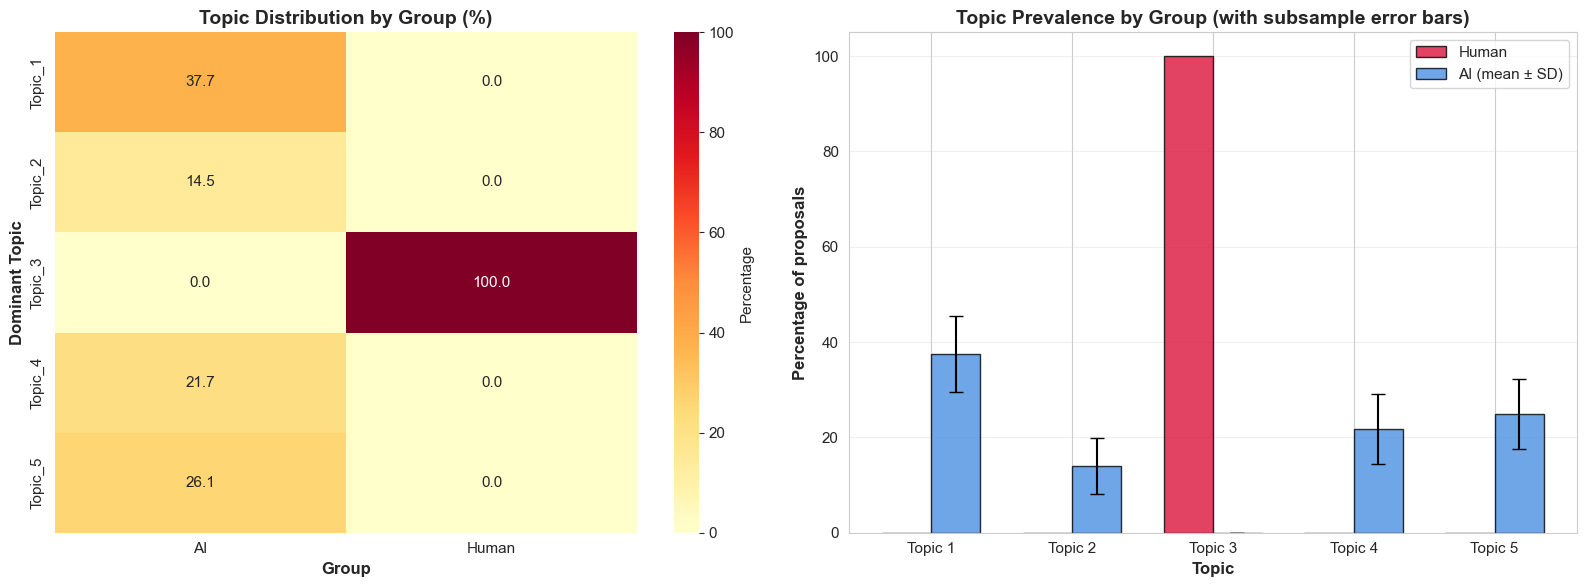

✓ Figure saved to: results/figures/topic_distribution_comparison.png


In [ ]:
# Visualization: Topic distribution by group
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Heatmap of topic × source
ax1 = axes[0]
contingency_pct = pd.crosstab(doc_topic_df['dominant_topic'], doc_topic_df['group'], normalize='columns') * 100
sns.heatmap(contingency_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Percentage'})
ax1.set_title('Topic Distribution by Group (%)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Group', fontsize=12, fontweight='bold')
ax1.set_ylabel('Dominant Topic', fontsize=12, fontweight='bold')

# Panel 2: Bar plot with error bars from subsampling
ax2 = axes[1]
topic_labels = [f'Topic {i+1}' for i in range(n_topics)]
x = np.arange(len(topic_labels))
width = 0.35

# Human percentages
human_counts = contingency_table['Human']
human_pcts = (human_counts / human_counts.sum() * 100).values

# AI percentages with subsample SDs
ai_pcts_mean = []
ai_pcts_std = []

for topic in contingency_table.index:
    ai_subsample_pcts = []
    for _ in range(200):  # 200 subsamples for error bars
        ai_indices = doc_topic_df[doc_topic_df['group'] == 'AI'].index
        sampled = doc_topic_df.loc[np.random.choice(ai_indices, size=len(human_abstracts), replace=False)]
        pct = (sampled['dominant_topic'] == topic).sum() / len(human_abstracts) * 100
        ai_subsample_pcts.append(pct)
    ai_pcts_mean.append(np.mean(ai_subsample_pcts))
    ai_pcts_std.append(np.std(ai_subsample_pcts))

ax2.bar(x - width/2, human_pcts, width, label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
ax2.bar(x + width/2, ai_pcts_mean, width, yerr=ai_pcts_std, label='AI (mean ± SD)', 
        color='#4A90E2', alpha=0.8, edgecolor='black', capsize=5)

ax2.set_xlabel('Topic', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage of proposals', fontsize=12, fontweight='bold')
ax2.set_title('Topic Prevalence by Group (with subsample error bars)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(topic_labels)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/topic_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/topic_distribution_comparison.png")

## Analysis 3.3: Topic Coverage and Entropy

Examine breadth and evenness of topic coverage with sample size corrections.

In [ ]:
from scipy.stats import entropy

print("="*85)
print("TOPIC COVERAGE AND ENTROPY ANALYSIS")
print("="*85)

# Topic coverage: count unique topics per group (threshold: topic probability > 0.20)
threshold = 0.20

def count_topics_covered(doc_topic_probs, threshold=0.20):
    """Count how many topics are represented above threshold"""
    topic_cols = [col for col in doc_topic_probs.columns if col.startswith('Topic_')]
    topics_above_threshold = set()
    for col in topic_cols:
        if (doc_topic_probs[col] > threshold).any():
            topics_above_threshold.add(col)
    return len(topics_above_threshold)

human_doc_topics = doc_topic_df[doc_topic_df['group'] == 'Human']
ai_doc_topics = doc_topic_df[doc_topic_df['group'] == 'AI']

human_coverage = count_topics_covered(human_doc_topics, threshold)
ai_coverage = count_topics_covered(ai_doc_topics, threshold)

print(f"\n1. TOPIC COVERAGE (topics with at least one proposal >{threshold*100:.0f}% probability):")
print(f"  Human: {human_coverage}/{n_topics} topics")
print(f"  AI: {ai_coverage}/{n_topics} topics")

# Exclusive topics
print(f"\n2. EXCLUSIVE TOPICS:")

def get_exclusive_topics(group_df, other_df, threshold=0.20, min_count=5):
    """Find topics exclusive to one group (with minimum count)"""
    topic_cols = [col for col in group_df.columns if col.startswith('Topic_')]
    exclusive = []
    
    for col in topic_cols:
        # Check if topic appears in group with sufficient frequency
        group_has = (group_df[col] > threshold).sum()
        other_has = (other_df[col] > threshold).sum()
        
        if group_has >= min_count and other_has == 0:
            exclusive.append(col)
    
    return exclusive

human_exclusive = get_exclusive_topics(human_doc_topics, ai_doc_topics, threshold, min_count=5)
ai_exclusive = get_exclusive_topics(ai_doc_topics, human_doc_topics, threshold, min_count=5)

print(f"  Human-exclusive topics (≥5 proposals, 0 in AI): {len(human_exclusive)}")
if human_exclusive:
    print(f"    {', '.join(human_exclusive)}")
print(f"  AI-exclusive topics (≥5 proposals, 0 in Human): {len(ai_exclusive)}")
if ai_exclusive:
    print(f"    {', '.join(ai_exclusive)}")

# Permutation test for exclusive topics
print(f"\n  Permutation test for exclusive topics:")
n_perm = 10000
perm_human_exclusive_counts = []
perm_ai_exclusive_counts = []

for _ in range(n_perm):
    # Shuffle group labels
    shuffled = doc_topic_df.copy()
    shuffled['group'] = np.random.permutation(shuffled['group'].values)
    
    human_perm = shuffled[shuffled['group'] == 'Human']
    ai_perm = shuffled[shuffled['group'] == 'AI']
    
    h_excl = len(get_exclusive_topics(human_perm, ai_perm, threshold, min_count=5))
    a_excl = len(get_exclusive_topics(ai_perm, human_perm, threshold, min_count=5))
    
    perm_human_exclusive_counts.append(h_excl)
    perm_ai_exclusive_counts.append(a_excl)

perm_human_exclusive_counts = np.array(perm_human_exclusive_counts)
perm_ai_exclusive_counts = np.array(perm_ai_exclusive_counts)

p_human = np.mean(perm_human_exclusive_counts >= len(human_exclusive))
p_ai = np.mean(perm_ai_exclusive_counts >= len(ai_exclusive))

print(f"    Human: {len(human_exclusive)} observed vs. {perm_human_exclusive_counts.mean():.2f} ± {perm_human_exclusive_counts.std():.2f} expected, p={p_human:.4f}")
print(f"    AI: {len(ai_exclusive)} observed vs. {perm_ai_exclusive_counts.mean():.2f} ± {perm_ai_exclusive_counts.std():.2f} expected, p={p_ai:.4f}")

# Shannon entropy with Miller-Madow correction
print(f"\n3. SHANNON ENTROPY (with Miller-Madow bias correction):")

def calculate_entropy_corrected(topic_distribution, n_topics):
    """Calculate Shannon entropy with Miller-Madow correction"""
    # Get topic counts
    topic_counts = topic_distribution.value_counts()
    
    # Shannon entropy
    h = entropy(topic_counts, base=2)
    
    # Miller-Madow correction: H_corrected = H + (K-1)/(2*N)
    # K = number of categories with non-zero count, N = sample size
    k = len(topic_counts)
    n = topic_counts.sum()
    h_corrected = h + (k - 1) / (2 * n)
    
    # Normalized entropy
    h_max = np.log2(k) if k > 1 else 1
    h_normalized = h_corrected / h_max if h_max > 0 else 0
    
    return h_corrected, h_normalized

human_entropy, human_norm_entropy = calculate_entropy_corrected(
    human_doc_topics['dominant_topic'], n_topics
)
ai_entropy, ai_norm_entropy = calculate_entropy_corrected(
    ai_doc_topics['dominant_topic'], n_topics
)

print(f"  Human: H = {human_entropy:.4f}, H_normalized = {human_norm_entropy:.4f}")
print(f"  AI: H = {ai_entropy:.4f}, H_normalized = {ai_norm_entropy:.4f}")

# Subsample AI to n=23 to account for sample size
print(f"\n  Subsample validation (AI subsampled to n={len(human_abstracts)}, 1000 iterations):")
subsample_entropies = []
subsample_norm_entropies = []

for _ in range(1000):
    ai_indices = ai_doc_topics.index
    sampled = ai_doc_topics.loc[np.random.choice(ai_indices, size=len(human_abstracts), replace=False)]
    h, h_norm = calculate_entropy_corrected(sampled['dominant_topic'], n_topics)
    subsample_entropies.append(h)
    subsample_norm_entropies.append(h_norm)

subsample_entropies = np.array(subsample_entropies)
subsample_norm_entropies = np.array(subsample_norm_entropies)

print(f"    AI (subsampled): H = {subsample_entropies.mean():.4f} ± {subsample_entropies.std():.4f}")
print(f"    AI (subsampled): H_normalized = {subsample_norm_entropies.mean():.4f} ± {subsample_norm_entropies.std():.4f}")

# Compare (subsample/permutation style test)
# We compare Human entropy to the distribution of AI entropies under subsampling.
# NOTE: If Human entropy is *lower* than typical AI, the one-sided p-value is
# P(AI_subsample_entropy <= Human_entropy), not >=.

ai_sub_mean = subsample_entropies.mean()
diff = human_entropy - ai_sub_mean

p_lower = np.mean(subsample_entropies <= human_entropy)  # AI as low-or-lower than Human
p_upper = np.mean(subsample_entropies >= human_entropy)  # AI as high-or-higher than Human
p_two_sided = min(1.0, 2 * min(p_lower, p_upper))

# One-sided in the observed direction
p_one_sided = p_lower if human_entropy < ai_sub_mean else p_upper

print(f"\n  Comparison (subsample test):")
print(f"    Difference (Human - AI_subsample_mean): {diff:.4f}")
print(f"    p_one_sided (observed direction): {p_one_sided:.4f}")
print(f"    p_two_sided: {p_two_sided:.4f}")

if p_two_sided < 0.05:
    if human_entropy > ai_sub_mean:
        print(f"    → Human proposals have significantly HIGHER entropy (more even dominant-topic distribution)")
    else:
        print(f"    → AI proposals have significantly HIGHER entropy (more even dominant-topic distribution)")
else:
    print(f"    → No significant difference in entropy")

print("\n💡 Higher entropy = more even spread across topics = higher thematic diversity")
print("="*85)

TOPIC COVERAGE AND ENTROPY ANALYSIS

1. TOPIC COVERAGE (topics with at least one proposal >20% probability):
  Human: 4/5 topics
  AI: 4/5 topics

2. EXCLUSIVE TOPICS:
  Human-exclusive topics (≥5 proposals, 0 in AI): 1
    Topic_3
  AI-exclusive topics (≥5 proposals, 0 in Human): 1
    Topic_5

  Permutation test for exclusive topics:
    Human: 1 observed vs. 0.00 ± 0.00 expected, p=0.0000
    AI: 1 observed vs. 0.01 ± 0.12 expected, p=0.0135

3. SHANNON ENTROPY (with Miller-Madow bias correction):
  Human: H = 0.0000, H_normalized = 0.0000
  AI: H = 1.9405, H_normalized = 0.9703

  Subsample validation (AI subsampled to n=23, 1000 iterations):
    AI (subsampled): H = 1.9209 ± 0.0981
    AI (subsampled): H_normalized = 0.9623 ± 0.0455

  Comparison (subsample test):
    Difference (Human - AI_subsample_mean): -1.9209
    p_one_sided (observed direction): 0.0000
    p_two_sided: 0.0000
    → AI proposals have significantly HIGHER entropy (more even dominant-topic distribution)

💡 Hig

## Analysis 3.4: Cluster Composition/Segregation Analysis

Examine whether human and AI proposals segregate into distinct clusters in embedding space using Gaussian Mixture Models.

In [ ]:
embeddings_data = retrieve_embeddings('full_proposals')

ai_embeddings = embeddings_data['ai_embeddings']
human_embeddings = embeddings_data['human_embeddings']
ai_metadata = embeddings_data['ai_metadata']
human_metadata = embeddings_data['human_metadata']


CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION

Using embeddings: (92, 1024)
  Human: 23, AI: 69

Testing k = [3, 4, 5, 6, 7, 8]...

k     Silhouette   Davies-Bouldin   BIC         
--------------------------------------------------
3     0.1009       1.9845           6058609.70  
4     0.1197       2.1773           8416661.77  
5     0.1234       1.9119           10787636.03 
6     0.1145       1.7012           13165324.67 
7     0.1160       1.6928           15540335.04 
8     0.1131       1.8885           17915506.25 

✓ Best k by BIC (elbow method): 3
✓ Best k by Silhouette score: 5

→ Selected k = 3 (using BIC)


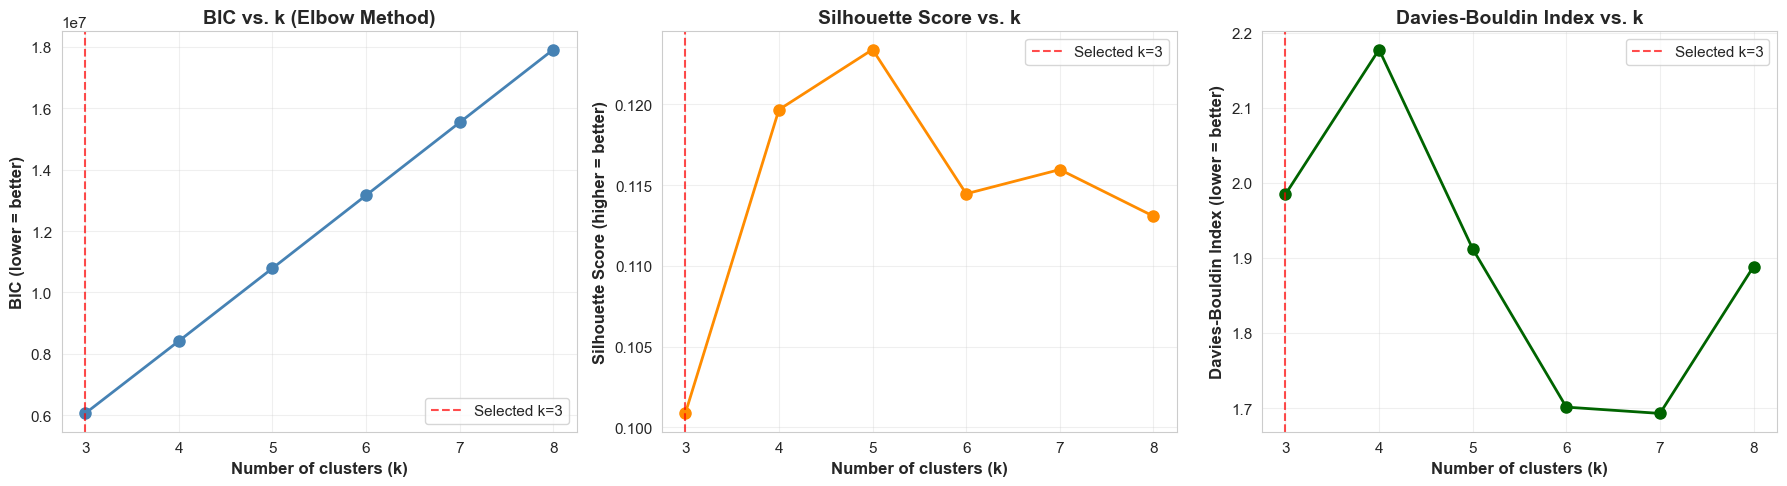

✓ Figure saved to: results/figures/cluster_k_selection.png


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, normalized_mutual_info_score, adjusted_rand_score

print("="*85)
print("CLUSTER ANALYSIS: STEP 1 - OPTIMAL k SELECTION")
print("="*85)

# Use embeddings from diversity analysis (already computed)
all_embeddings_cluster = np.vstack([human_embeddings, ai_embeddings])
source_labels_cluster = np.array(['Human'] * len(human_embeddings) + ['AI'] * len(ai_embeddings))

print(f"\nUsing embeddings: {all_embeddings_cluster.shape}")
print(f"  Human: {len(human_embeddings)}, AI: {len(ai_embeddings)}")

# Test different values of k
k_values = [3, 4, 5, 6, 7, 8]
metrics_results = []

print(f"\nTesting k = {k_values}...")
print(f"\n{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<16} {'BIC':<12}")
print("-"*50)

for k in k_values:
    # Fit GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    cluster_labels = gmm.fit_predict(all_embeddings_cluster)
    
    # Compute metrics
    silhouette = silhouette_score(all_embeddings_cluster, cluster_labels)
    davies_bouldin = davies_bouldin_score(all_embeddings_cluster, cluster_labels)
    bic = gmm.bic(all_embeddings_cluster)
    
    metrics_results.append({
        'k': k,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'bic': bic
    })
    
    print(f"{k:<5} {silhouette:<12.4f} {davies_bouldin:<16.4f} {bic:<12.2f}")

metrics_df = pd.DataFrame(metrics_results)

# Select best k using BIC (lower is better)
best_k_bic = metrics_df.loc[metrics_df['bic'].idxmin(), 'k']
best_k_silhouette = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k']

print(f"\n✓ Best k by BIC (elbow method): {best_k_bic}")
print(f"✓ Best k by Silhouette score: {best_k_silhouette}")

# Use BIC as primary criterion
best_k = int(best_k_bic)
print(f"\n→ Selected k = {best_k} (using BIC)")

# Visualize selection metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: BIC
ax1 = axes[0]
ax1.plot(metrics_df['k'], metrics_df['bic'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax1.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('BIC (lower = better)', fontsize=12, fontweight='bold')
ax1.set_title('BIC vs. k (Elbow Method)', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend()

# Panel 2: Silhouette
ax2 = axes[1]
ax2.plot(metrics_df['k'], metrics_df['silhouette'], 'o-', linewidth=2, markersize=8, color='darkorange')
ax2.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax2.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score (higher = better)', fontsize=12, fontweight='bold')
ax2.set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

# Panel 3: Davies-Bouldin
ax3 = axes[2]
ax3.plot(metrics_df['k'], metrics_df['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='darkgreen')
ax3.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k={best_k}')
ax3.set_xlabel('Number of clusters (k)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Davies-Bouldin Index (lower = better)', fontsize=12, fontweight='bold')
ax3.set_title('Davies-Bouldin Index vs. k', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.savefig('results/figures/cluster_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/cluster_k_selection.png")
print("="*85)

In [ ]:
print("="*85)
print(f"CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k={best_k}")
print("="*85)

# Fit final GMM with best k
gmm_final = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42,
    n_init=10
)

cluster_labels_final = gmm_final.fit_predict(all_embeddings_cluster)
cluster_probs_final = gmm_final.predict_proba(all_embeddings_cluster)

print(f"\n✓ Clustered {len(all_embeddings_cluster)} proposals into {best_k} clusters")
print(f"  Cluster sizes: {np.bincount(cluster_labels_final)}")

# Cluster composition analysis
print(f"\n" + "-"*85)
print("CLUSTER COMPOSITION ANALYSIS")
print("-"*85)

cluster_composition = []

for cluster_id in range(best_k):
    cluster_mask = cluster_labels_final == cluster_id
    cluster_sources = source_labels_cluster[cluster_mask]
    
    n_total = len(cluster_sources)
    n_human = (cluster_sources == 'Human').sum()
    n_ai = (cluster_sources == 'AI').sum()
    
    pct_human = n_human / n_total * 100 if n_total > 0 else 0
    pct_ai = n_ai / n_total * 100 if n_total > 0 else 0
    
    # Classify cluster dominance (baseline: 25% human, 75% AI)
    if pct_human > 60:
        dominance = 'Human-dominated'
    elif pct_human < 15:  # Less than expected given 25% baseline
        dominance = 'AI-dominated'
    else:
        dominance = 'Mixed'
    
    cluster_composition.append({
        'cluster': cluster_id,
        'total': n_total,
        'human': n_human,
        'ai': n_ai,
        'pct_human': pct_human,
        'pct_ai': pct_ai,
        'dominance': dominance
    })

composition_df = pd.DataFrame(cluster_composition)

print(f"\n{'Cluster':<10} {'Total':<8} {'Human':<8} {'AI':<8} {'%Human':<10} {'%AI':<10} {'Dominance'}")
print("-"*85)

for _, row in composition_df.iterrows():
    print(f"{row['cluster']:<10} {row['total']:<8} {row['human']:<8} {row['ai']:<8} "
          f"{row['pct_human']:<10.1f} {row['pct_ai']:<10.1f} {row['dominance']}")

print(f"\n{'Dominance':<20} {'Count'}")
print("-"*30)
dominance_counts = composition_df['dominance'].value_counts()
for dom, count in dominance_counts.items():
    print(f"{dom:<20} {count}")

print(f"\n💡 Baseline: 25% human, 75% AI")
print(f"   Human-dominated: >60% human")
print(f"   AI-dominated: <15% human")
print(f"   Mixed: 15-60% human")
print("="*85)

CLUSTER ANALYSIS: STEP 2 - CLUSTERING WITH k=3

✓ Clustered 92 proposals into 3 clusters
  Cluster sizes: [27  7 58]

-------------------------------------------------------------------------------------
CLUSTER COMPOSITION ANALYSIS
-------------------------------------------------------------------------------------

Cluster    Total    Human    AI       %Human     %AI        Dominance
-------------------------------------------------------------------------------------
0          27       0        27       0.0        100.0      AI-dominated
1          7        0        7        0.0        100.0      AI-dominated
2          58       23       35       39.7       60.3       Mixed

Dominance            Count
------------------------------
AI-dominated         2
Mixed                1

💡 Baseline: 25% human, 75% AI
   Human-dominated: >60% human
   AI-dominated: <15% human
   Mixed: 15-60% human


In [ ]:
print("="*85)
print("CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)")
print("="*85)

# Convert source labels to binary (0 = Human, 1 = AI)
source_binary = (source_labels_cluster == 'AI').astype(int)

# 1. Normalized Mutual Information (NMI)
nmi_observed = normalized_mutual_info_score(cluster_labels_final, source_binary)

print(f"\n1. NORMALIZED MUTUAL INFORMATION (NMI):")
print(f"   Observed NMI: {nmi_observed:.4f}")

# Permutation test for NMI
n_perm_seg = 10000
nmi_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    nmi_perm = normalized_mutual_info_score(cluster_labels_final, shuffled_sources)
    nmi_null.append(nmi_perm)

nmi_null = np.array(nmi_null)
p_nmi = np.mean(nmi_null >= nmi_observed)

print(f"   Null distribution: {nmi_null.mean():.4f} ± {nmi_null.std():.4f}")
print(f"   p-value: {p_nmi:.4f}")

if p_nmi < 0.05:
    print(f"   → Significant segregation: clusters predict source better than chance")
else:
    print(f"   → No significant segregation: clustering independent of source")

# 2. Adjusted Rand Index (ARI)
ari_observed = adjusted_rand_score(cluster_labels_final, source_binary)

print(f"\n2. ADJUSTED RAND INDEX (ARI):")
print(f"   Observed ARI: {ari_observed:.4f}")

# Permutation test for ARI
ari_null = []

for _ in range(n_perm_seg):
    shuffled_sources = np.random.permutation(source_binary)
    ari_perm = adjusted_rand_score(cluster_labels_final, shuffled_sources)
    ari_null.append(ari_perm)

ari_null = np.array(ari_null)
p_ari = np.mean(ari_null >= ari_observed)

print(f"   Null distribution: {ari_null.mean():.4f} ± {ari_null.std():.4f}")
print(f"   p-value: {p_ari:.4f}")

if p_ari < 0.05:
    print(f"   → Significant agreement: cluster assignments correlate with source")
else:
    print(f"   → No significant agreement: random overlap")

# 3. Within-group vs. Between-group distances
print(f"\n3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:")

# Calculate pairwise distances
from sklearn.metrics.pairwise import cosine_distances

distances_all = cosine_distances(all_embeddings_cluster)

# Within-human distances
human_mask = source_labels_cluster == 'Human'
within_human_dists = distances_all[np.ix_(human_mask, human_mask)]
within_human_dists = within_human_dists[np.triu_indices_from(within_human_dists, k=1)]

# Within-AI distances
ai_mask = source_labels_cluster == 'AI'
within_ai_dists = distances_all[np.ix_(ai_mask, ai_mask)]
within_ai_dists = within_ai_dists[np.triu_indices_from(within_ai_dists, k=1)]

# Between human-AI distances
between_dists = distances_all[np.ix_(human_mask, ai_mask)].flatten()

print(f"   Within-human mean distance: {within_human_dists.mean():.4f} ± {within_human_dists.std():.4f}")
print(f"   Within-AI mean distance: {within_ai_dists.mean():.4f} ± {within_ai_dists.std():.4f}")
print(f"   Between human-AI mean distance: {between_dists.mean():.4f} ± {between_dists.std():.4f}")

# Ratio of between to within
within_mean = np.mean([within_human_dists.mean(), within_ai_dists.mean()])
between_within_ratio = between_dists.mean() / within_mean

print(f"\n   Between/Within ratio: {between_within_ratio:.4f}")

# Permutation test for between/within ratio
ratio_null = []

for _ in range(n_perm_seg):
    shuffled = np.random.permutation(source_labels_cluster)
    h_mask = shuffled == 'Human'
    a_mask = shuffled == 'AI'
    
    within_h = distances_all[np.ix_(h_mask, h_mask)]
    within_h = within_h[np.triu_indices_from(within_h, k=1)]
    
    within_a = distances_all[np.ix_(a_mask, a_mask)]
    within_a = within_a[np.triu_indices_from(within_a, k=1)]
    
    between = distances_all[np.ix_(h_mask, a_mask)].flatten()
    
    within_m = np.mean([within_h.mean(), within_a.mean()])
    ratio_perm = between.mean() / within_m
    ratio_null.append(ratio_perm)

ratio_null = np.array(ratio_null)
p_ratio = np.mean(ratio_null >= between_within_ratio)

print(f"   Null distribution: {ratio_null.mean():.4f} ± {ratio_null.std():.4f}")
print(f"   p-value: {p_ratio:.4f}")

if p_ratio < 0.05:
    if between_within_ratio > 1:
        print(f"   → Human and AI proposals are significantly MORE distant from each other than within groups")
    else:
        print(f"   → Human and AI proposals are significantly CLOSER to each other than within groups")
else:
    print(f"   → No significant difference in between vs. within-group distances")

print("\n" + "="*85)
print("INTERPRETATION SUMMARY")
print("="*85)

if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions")
    print("  → They generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ INTEGRATION: Human and AI proposals intermixed in embedding space")
    print("  → Ideas are similar regardless of source")
else:
    print("✓ INTERMEDIATE: Some thematic clustering but not strictly by source")

print("="*85)

CLUSTER ANALYSIS: STEP 3 - SEGREGATION METRICS (with Permutation Tests)

1. NORMALIZED MUTUAL INFORMATION (NMI):
   Observed NMI: 0.1972
   Null distribution: 0.0170 ± 0.0166
   p-value: 0.0000
   → Significant segregation: clusters predict source better than chance

2. ADJUSTED RAND INDEX (ARI):
   Observed ARI: -0.0353
   Null distribution: 0.0003 ± 0.0375
   p-value: 0.8627
   → No significant agreement: random overlap

3. WITHIN-GROUP VS. BETWEEN-GROUP DISTANCES:
   Within-human mean distance: 0.0661 ± 0.0175
   Within-AI mean distance: 0.1733 ± 0.2664
   Between human-AI mean distance: 0.1299 ± 0.1945

   Between/Within ratio: 1.0854
   Null distribution: 1.0007 ± 0.0224
   p-value: 0.0038
   → Human and AI proposals are significantly MORE distant from each other than within groups

INTERPRETATION SUMMARY
✓ SEGREGATION: Human and AI proposals cluster in distinct semantic regions
  → They generate different KINDS of ideas


CLUSTER ANALYSIS: STEP 4 - VISUALIZATION
Reducing to 2D with UMAP for visualization...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


✓ UMAP projection complete: (92, 2)


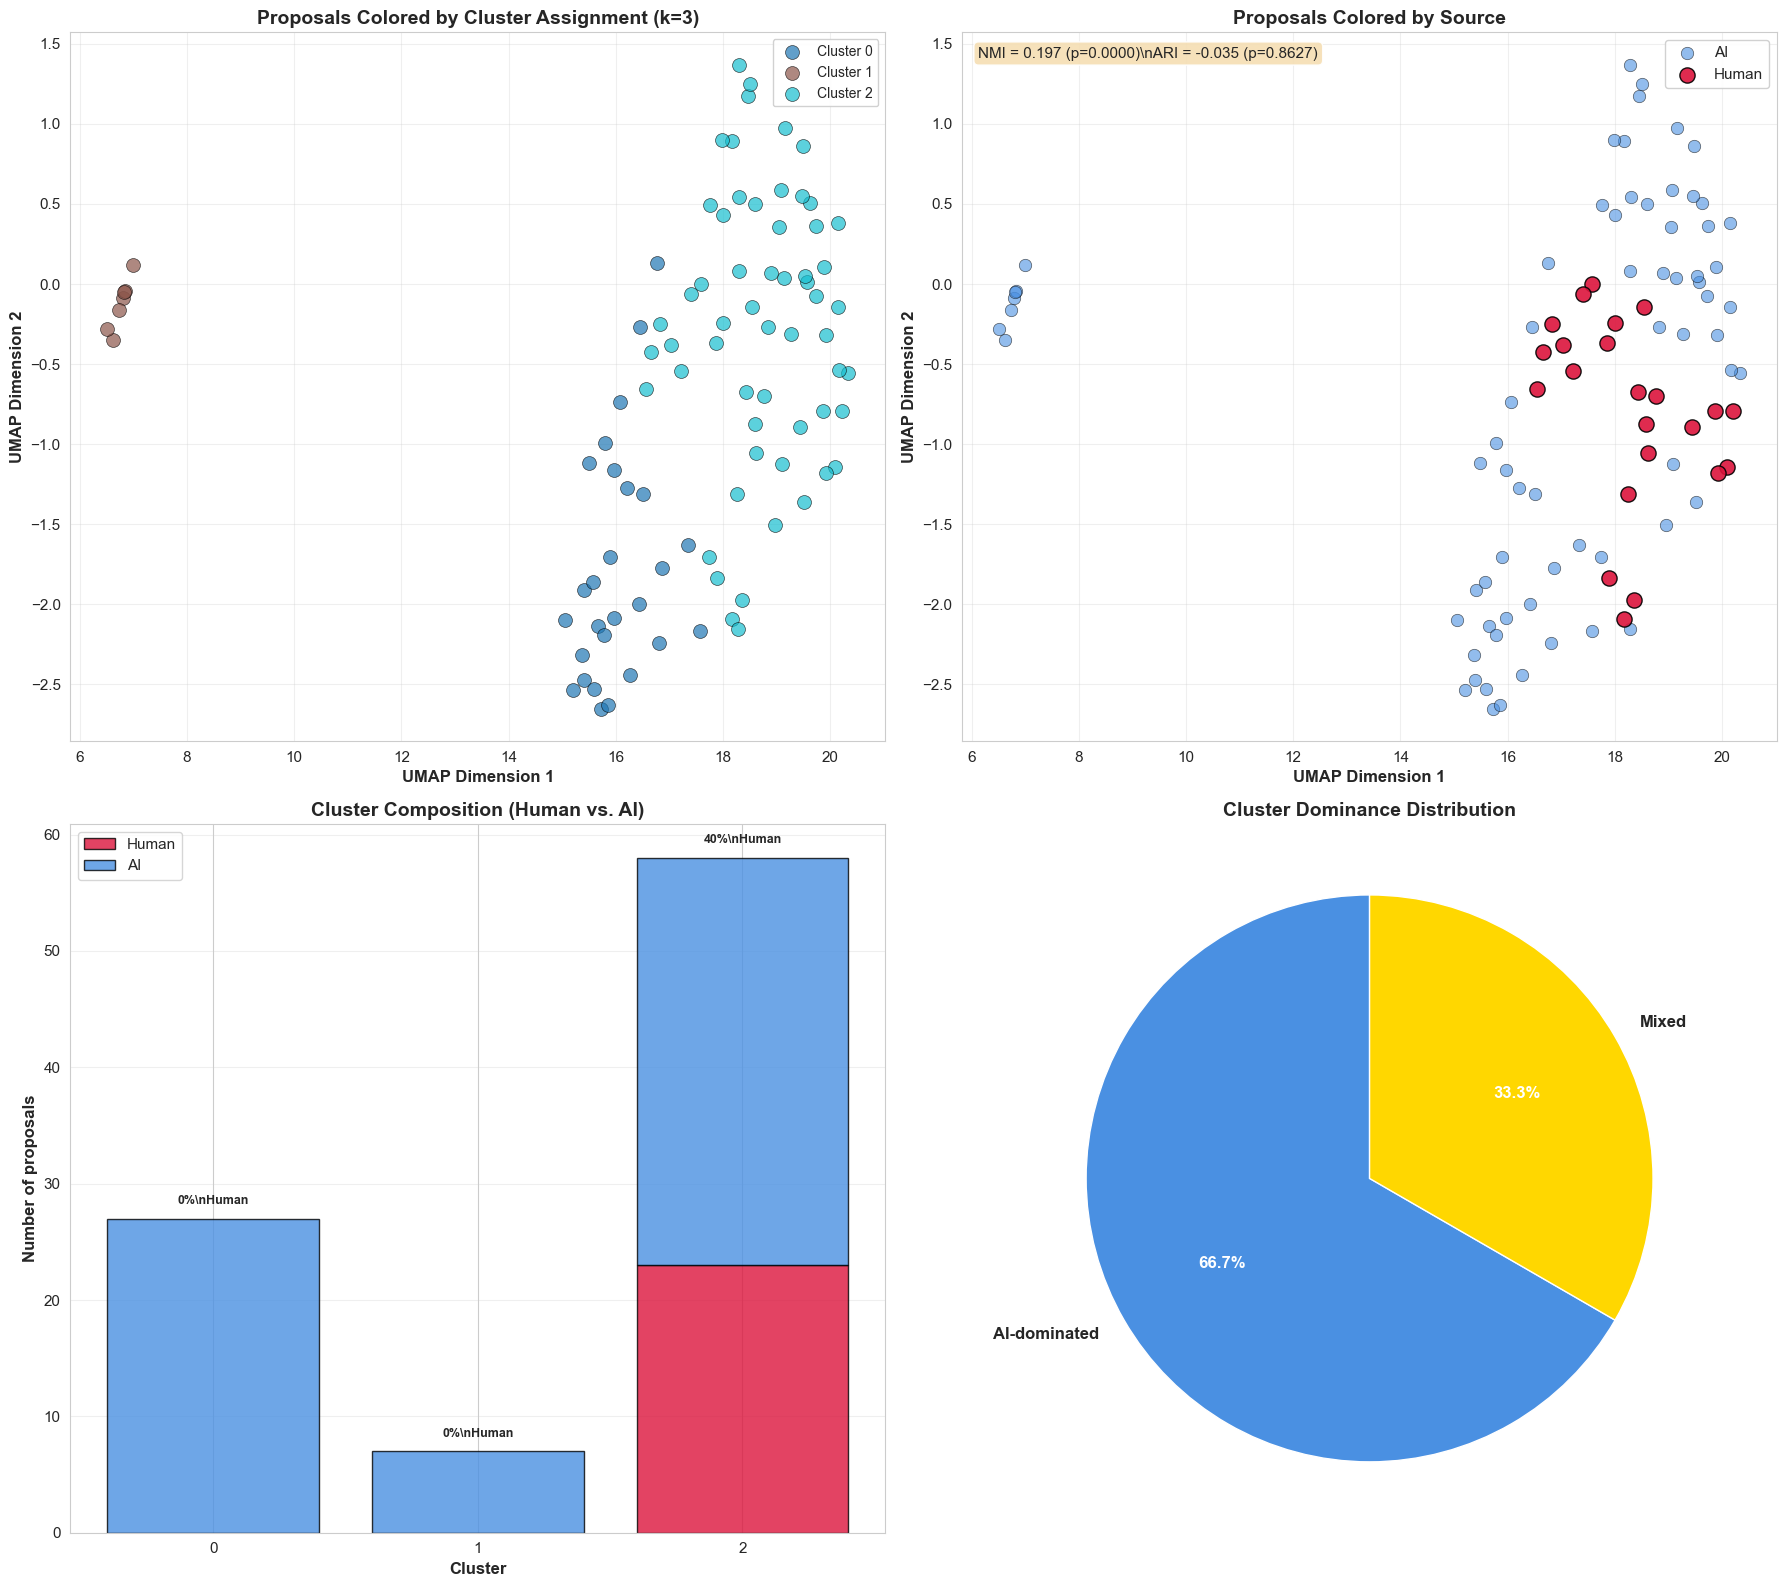

✓ Figure saved to: results/figures/cluster_analysis_visualization.png


In [ ]:
import umap
# Visualization: Cluster analysis in 2D embedding space
print("="*85)
print("CLUSTER ANALYSIS: STEP 4 - VISUALIZATION")
print("="*85)

# Use existing UMAP projection from earlier analysis
# Apply UMAP if not already done for this combined set
print("Reducing to 2D with UMAP for visualization...")

reducer_cluster = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d_cluster = reducer_cluster.fit_transform(all_embeddings_cluster)

print(f"✓ UMAP projection complete: {embeddings_2d_cluster.shape}")

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Color schemes
source_colors = {'Human': '#DC143C', 'AI': '#4A90E2'}
cluster_colors = plt.cm.tab10(np.linspace(0, 1, best_k))

# Panel 1: Colored by cluster assignment
ax1 = axes[0, 0]
for cluster_id in range(best_k):
    mask = cluster_labels_final == cluster_id
    ax1.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=[cluster_colors[cluster_id]], label=f'Cluster {cluster_id}',
               s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax1.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax1.set_title(f'Proposals Colored by Cluster Assignment (k={best_k})', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(alpha=0.3)

# Panel 2: Colored by source (Human vs. AI)
ax2 = axes[0, 1]
for source in ['AI', 'Human']:  # Plot AI first, Human on top
    mask = source_labels_cluster == source
    ax2.scatter(embeddings_2d_cluster[mask, 0], embeddings_2d_cluster[mask, 1],
               c=source_colors[source], label=source,
               s=120 if source == 'Human' else 80, 
               alpha=0.9 if source == 'Human' else 0.6,
               edgecolors='black', linewidth=1.0 if source == 'Human' else 0.5)

ax2.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='bold')
ax2.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='bold')
ax2.set_title('Proposals Colored by Source', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3)

# Add NMI and ARI as text
textstr = f'NMI = {nmi_observed:.3f} (p={p_nmi:.4f})\\nARI = {ari_observed:.3f} (p={p_ari:.4f})'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Panel 3: Cluster composition (stacked bar chart)
ax3 = axes[1, 0]
cluster_ids = composition_df['cluster'].values
human_counts = composition_df['human'].values
ai_counts = composition_df['ai'].values

ax3.bar(cluster_ids, human_counts, label='Human', color='#DC143C', alpha=0.8, edgecolor='black')
ax3.bar(cluster_ids, ai_counts, bottom=human_counts, label='AI', color='#4A90E2', alpha=0.8, edgecolor='black')

ax3.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of proposals', fontsize=12, fontweight='bold')
ax3.set_title('Cluster Composition (Human vs. AI)', fontsize=14, fontweight='bold')
ax3.set_xticks(cluster_ids)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Add percentage labels
for i, cluster_id in enumerate(cluster_ids):
    total = composition_df.loc[i, 'total']
    pct_h = composition_df.loc[i, 'pct_human']
    ax3.text(cluster_id, total + 1, f'{pct_h:.0f}%\\nHuman', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 4: Cluster dominance pie chart
ax4 = axes[1, 1]
dominance_counts = composition_df['dominance'].value_counts()
colors_pie = {'Human-dominated': '#DC143C', 'AI-dominated': '#4A90E2', 'Mixed': '#FFD700'}
pie_colors = [colors_pie.get(d, 'gray') for d in dominance_counts.index]

wedges, texts, autotexts = ax4.pie(dominance_counts.values, labels=dominance_counts.index, 
                                     autopct='%1.1f%%', startangle=90,
                                     colors=pie_colors, textprops={'fontsize': 12, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax4.set_title('Cluster Dominance Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/cluster_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved to: results/figures/cluster_analysis_visualization.png")
print("="*85)

### PART III Summary

In [ ]:
print("="*85)
print("ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY")
print("="*85)

print("\n" + "="*85)
print("1. TOPIC MODELING (LDA with n=5 topics)")
print("="*85)
print(f"  Model: Latent Dirichlet Allocation")
print(f"  Parameters: alpha=0.5, beta=0.5 (strong regularization)")
print(f"  Perplexity: {lda_model.perplexity(doc_term_matrix):.2f}")
print(f"\n  Topics identified:")
for i, topic_words in enumerate(topics):
    print(f"    Topic {i+1}: {', '.join(topic_words[:5])}...")

print("\n" + "="*85)
print("2. TOPIC DISTRIBUTION COMPARISON")
print("="*85)
print(f"  Overall distribution test (permutation):")
print(f"    Chi-square: {observed_chi2:.4f}, p={p_value_perm:.4f}")
if p_value_perm < 0.05:
    print(f"    → Significant difference in topic distributions")
else:
    print(f"    → No significant difference in topic distributions")

print(f"\n  Per-topic tests (Fisher's exact with FDR correction):")
significant_topics = fisher_df[fisher_df['p_value_fdr'] < 0.10]
if len(significant_topics) > 0:
    print(f"    {len(significant_topics)} topics show significant over/under-representation:")
    for _, row in significant_topics.iterrows():
        direction = 'Human' if row['odds_ratio'] > 1 else 'AI'
        print(f"      {row['topic']}: OR={row['odds_ratio']:.2f}, p_fdr={row['p_value_fdr']:.4f} ({direction}↑)")
else:
    print(f"    No topics show significant over/under-representation (FDR q=0.10)")

print("\n" + "="*85)
print("3. TOPIC COVERAGE AND ENTROPY")
print("="*85)
print(f"  Coverage (topics with >20% probability):")
print(f"    Human: {human_coverage}/{n_topics} topics")
print(f"    AI: {ai_coverage}/{n_topics} topics")

print(f"\n  Exclusive topics (≥5 proposals):")
print(f"    Human-exclusive: {len(human_exclusive)} (p={p_human:.4f})")
print(f"    AI-exclusive: {len(ai_exclusive)} (p={p_ai:.4f})")

print(f"\n  Shannon entropy (Miller-Madow corrected):")
print(f"    Human: H={human_entropy:.4f}, H_norm={human_norm_entropy:.4f}")
print(f"    AI (subsampled): H={subsample_entropies.mean():.4f}±{subsample_entropies.std():.4f}")
print(f"    Difference: p={p_entropy:.4f}")

print("\n" + "="*85)
print(f"4. CLUSTER ANALYSIS (GMM with k={best_k})")
print("="*85)
print(f"  Model selection:")
print(f"    Best k by BIC: {best_k}")
print(f"    Silhouette score: {metrics_df.loc[metrics_df['k']==best_k, 'silhouette'].values[0]:.4f}")

print(f"\n  Cluster composition:")
print(f"    Human-dominated clusters: {(composition_df['dominance']=='Human-dominated').sum()}")
print(f"    AI-dominated clusters: {(composition_df['dominance']=='AI-dominated').sum()}")
print(f"    Mixed clusters: {(composition_df['dominance']=='Mixed').sum()}")

print(f"\n  Segregation metrics:")
print(f"    NMI: {nmi_observed:.4f} (null: {nmi_null.mean():.4f}±{nmi_null.std():.4f}, p={p_nmi:.4f})")
print(f"    ARI: {ari_observed:.4f} (null: {ari_null.mean():.4f}±{ari_null.std():.4f}, p={p_ari:.4f})")
print(f"    Between/Within distance ratio: {between_within_ratio:.4f} (p={p_ratio:.4f})")

print("\n" + "="*85)
print("OVERALL INTERPRETATION")
print("="*85)

# Topic distribution
if p_value_perm < 0.05:
    print("✓ Topics: Human and AI differ in topic distributions")
else:
    print("✓ Topics: No significant difference in topic distributions")

# Entropy
if p_entropy < 0.05:
    if diff > 0:
        print("✓ Entropy: Human proposals show higher thematic diversity")
    else:
        print("✓ Entropy: AI proposals show higher thematic diversity")
else:
    print("✓ Entropy: Similar thematic diversity between groups")

# Clustering
if p_nmi < 0.05 or p_ari < 0.05:
    print("✓ Clustering: SEGREGATION - Human and AI occupy distinct semantic regions")
    print("  → Generate different KINDS of ideas")
elif p_nmi > 0.10 and p_ari > 0.10:
    print("✓ Clustering: INTEGRATION - Human and AI ideas are intermixed")
    print("  → Similar ideas regardless of source")
else:
    print("✓ Clustering: INTERMEDIATE - Some thematic patterns but not strict segregation")

print("\n⚠️  LIMITATIONS:")
print("  • Small sample size (n=23 human, n=69 AI)")
print("  • Topic modeling labeled as EXPLORATORY")
print("  • Results should be validated with larger samples")
print("  • Segregation may reflect prompt differences, not inherent ideation differences")

print("\n" + "="*85)
print("📊 FIGURES GENERATED:")
print("="*85)
print("  1. results/figures/cluster_k_selection.png")
print("  2. results/figures/topic_distribution_comparison.png")
print("  3. results/figures/cluster_analysis_visualization.png")
print("="*85)

ANALYSIS 2.3: THEMATIC AND CLUSTER ANALYSIS - COMPREHENSIVE SUMMARY

1. TOPIC MODELING (LDA with n=5 topics)
  Model: Latent Dirichlet Allocation
  Parameters: alpha=0.5, beta=0.5 (strong regularization)
  Perplexity: 1207.75

  Topics identified:
    Topic 1: mechanical, membrane, cryo, seq, ribosome...
    Topic 2: transport, diffusion, imaging, filament, phenotypes...
    Topic 3: sequence, species, allosteric, rna, evolutionary...
    Topic 4: imaging, size, cargo, feature, perturbation...
    Topic 5: sequence, allosteric, splicing, transport, disease...

2. TOPIC DISTRIBUTION COMPARISON
  Overall distribution test (permutation):
    Chi-square: 92.0000, p=0.0000
    → Significant difference in topic distributions

  Per-topic tests (Fisher's exact with FDR correction):
    5 topics show significant over/under-representation:
      Topic_1: OR=0.00, p_fdr=0.0004 (AI↑)
      Topic_2: OR=0.00, p_fdr=0.0612 (AI↑)
      Topic_3: OR=inf, p_fdr=0.0000 (Human↑)
      Topic_4: OR=0.00, p_

----------------------------
# PART IV Style Baseline

Before interpreting embedding distances, clustering segregation (NMI/ARI), or topic separation as “conceptual” differences, quantify how much **purely stylistic** signals can separate Human vs. AI. If a style-only model predicts source well, then a substantial portion of downstream “segregation/diversity” effects may be stylistic rather than conceptual.

### Exract stylistic features

In [ ]:
# =============================================================================
# ANALYSIS 2.3.5–2.3.6: STYLE VS CONTENT (Baseline + Style-Controlled Sensitivity)
# Text scope: full proposals (full_text)
# =============================================================================

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ----------------------------
# Style feature extraction
# ----------------------------

_HEDGE_WORDS = {
    'may','might','could','can','suggest','suggests','suggested','potential','potentially',
    'likely','unlikely','possibly','possible','approximately','estimate','estimated',
    'hypothesize','hypothesis','we propose','we aim','we will','we plan'
}

def _tokenize_words(text: str):
    return re.findall(r"[A-Za-z']+", text.lower())

def _split_sentences(text: str):
    # lightweight sentence split for readability/stylistic counts
    sents = re.split(r"[.!?]+\s+|\n+", text.strip())
    return [s for s in (sent.strip() for sent in sents) if s]

def _count_syllables(word: str) -> int:
    # heuristic syllable counter (good enough for comparative readability proxies)
    w = re.sub(r"[^a-z]", "", word.lower())
    if not w:
        return 0
    w = re.sub(r"e$", "", w)  # silent e
    groups = re.findall(r"[aeiouy]+", w)
    return max(1, len(groups))

def _flesch_kincaid(text: str):
    words = _tokenize_words(text)
    n_words = len(words)
    sents = _split_sentences(text)
    n_sents = len(sents)
    if n_words == 0 or n_sents == 0:
        return np.nan, np.nan
    syllables = sum(_count_syllables(w) for w in words)

    # Flesch Reading Ease & FK Grade Level (English)
    fre = 206.835 - 1.015 * (n_words / n_sents) - 84.6 * (syllables / n_words)
    fkgl = 0.39 * (n_words / n_sents) + 11.8 * (syllables / n_words) - 15.59
    return fre, fkgl

def extract_style_features(text: str) -> dict:
    text = text or ""
    words = _tokenize_words(text)
    n_words = len(words)
    n_chars = len(text)
    sents = _split_sentences(text)
    n_sents = len(sents)

    uniq = len(set(words)) if n_words else 0
    ttr = (uniq / n_words) if n_words else 0.0

    stop_ct = sum(1 for w in words if w in ENGLISH_STOP_WORDS)
    stop_rate = (stop_ct / n_words) if n_words else 0.0

    avg_word_len = (np.mean([len(w) for w in words]) if n_words else 0.0)
    avg_sent_len = (n_words / n_sents) if n_sents else 0.0

    # punctuation / formatting (normalized)
    punct = {
        'comma': text.count(','),
        'semicolon': text.count(';'),
        'colon': text.count(':'),
        'dash': text.count('-') + text.count('–') + text.count('—'),
        'paren': text.count('(') + text.count(')'),
        'quote': text.count('"') + text.count("'"),
        'newline': text.count('\n'),
        'bullet': len(re.findall(r"(^|\n)\s*[-*•]\s+", text))
    }
    punct_rate = {f"{k}_per_1k_chars": (v / max(1, n_chars)) * 1000.0 for k, v in punct.items()}

    # hedging / stance
    low = text.lower()
    hedge_hits = 0
    # count single-token hedges
    hedge_hits += sum(1 for w in words if w in _HEDGE_WORDS)
    # count a few multiword patterns
    hedge_hits += len(re.findall(r"\bwe\s+(propose|aim|plan|will)\b", low))
    hedge_rate = (hedge_hits / n_words) if n_words else 0.0

    # simple headers / sectioning markers (your full_text includes e.g., "Title:", "Abstract:")
    header_lines = 0
    for line in (ln.strip() for ln in text.splitlines()):
        if re.match(r"^[A-Z][A-Za-z0-9 /-]{1,40}:\s+", line):
            header_lines += 1
    header_rate = header_lines

    fre, fkgl = _flesch_kincaid(text)

    feats = {
        'n_words': n_words,
        'n_chars': n_chars,
        'n_sents': n_sents,
        'avg_word_len': avg_word_len,
        'avg_sent_len_words': avg_sent_len,
        'type_token_ratio': ttr,
        'stopword_rate': stop_rate,
        'hedge_rate': hedge_rate,
        'flesch_reading_ease': fre,
        'fk_grade_level': fkgl,
    }
    feats.update(punct_rate)
    return feats

# Build style feature table (full proposals)
human_texts_style = human_df['full_text'].fillna('').tolist()
ai_texts_style = ai_df['full_text'].fillna('').tolist()
all_texts_style = human_texts_style + ai_texts_style

style_rows = [extract_style_features(t) for t in all_texts_style]
style_df = pd.DataFrame(style_rows)
style_df['group'] = (['Human'] * len(human_texts_style)) + (['AI'] * len(ai_texts_style))
style_df['is_ai'] = (style_df['group'] == 'AI').astype(int)

print("="*85)
print("STYLE FEATURES: EXTRACTED")
print("="*85)
print(f"✓ Built style feature table: {style_df.shape[0]} docs × {style_df.shape[1]-2} features")
print(style_df.groupby('group')[['avg_sent_len_words','stopword_rate','hedge_rate','fk_grade_level']].mean().round(3))


STYLE FEATURES: EXTRACTED
✓ Built style feature table: 92 docs × 18 features
       avg_sent_len_words  stopword_rate  hedge_rate  fk_grade_level
group                                                               
AI                 18.786          0.268       0.012          17.755
Human              22.741          0.336       0.014          18.189


#### Visualization: Style feature distributions by group (Human vs each AI model)

**How to read:** Each subplot is one style feature.
- The **box** shows median (center line) and IQR (25th–75th percentile).
- The **black diamond** is the mean, and the **error bar** is ±1 standard deviation.

This makes it easy to compare **median vs mean** (skew/outliers) and overall spread across Human and each AI model.

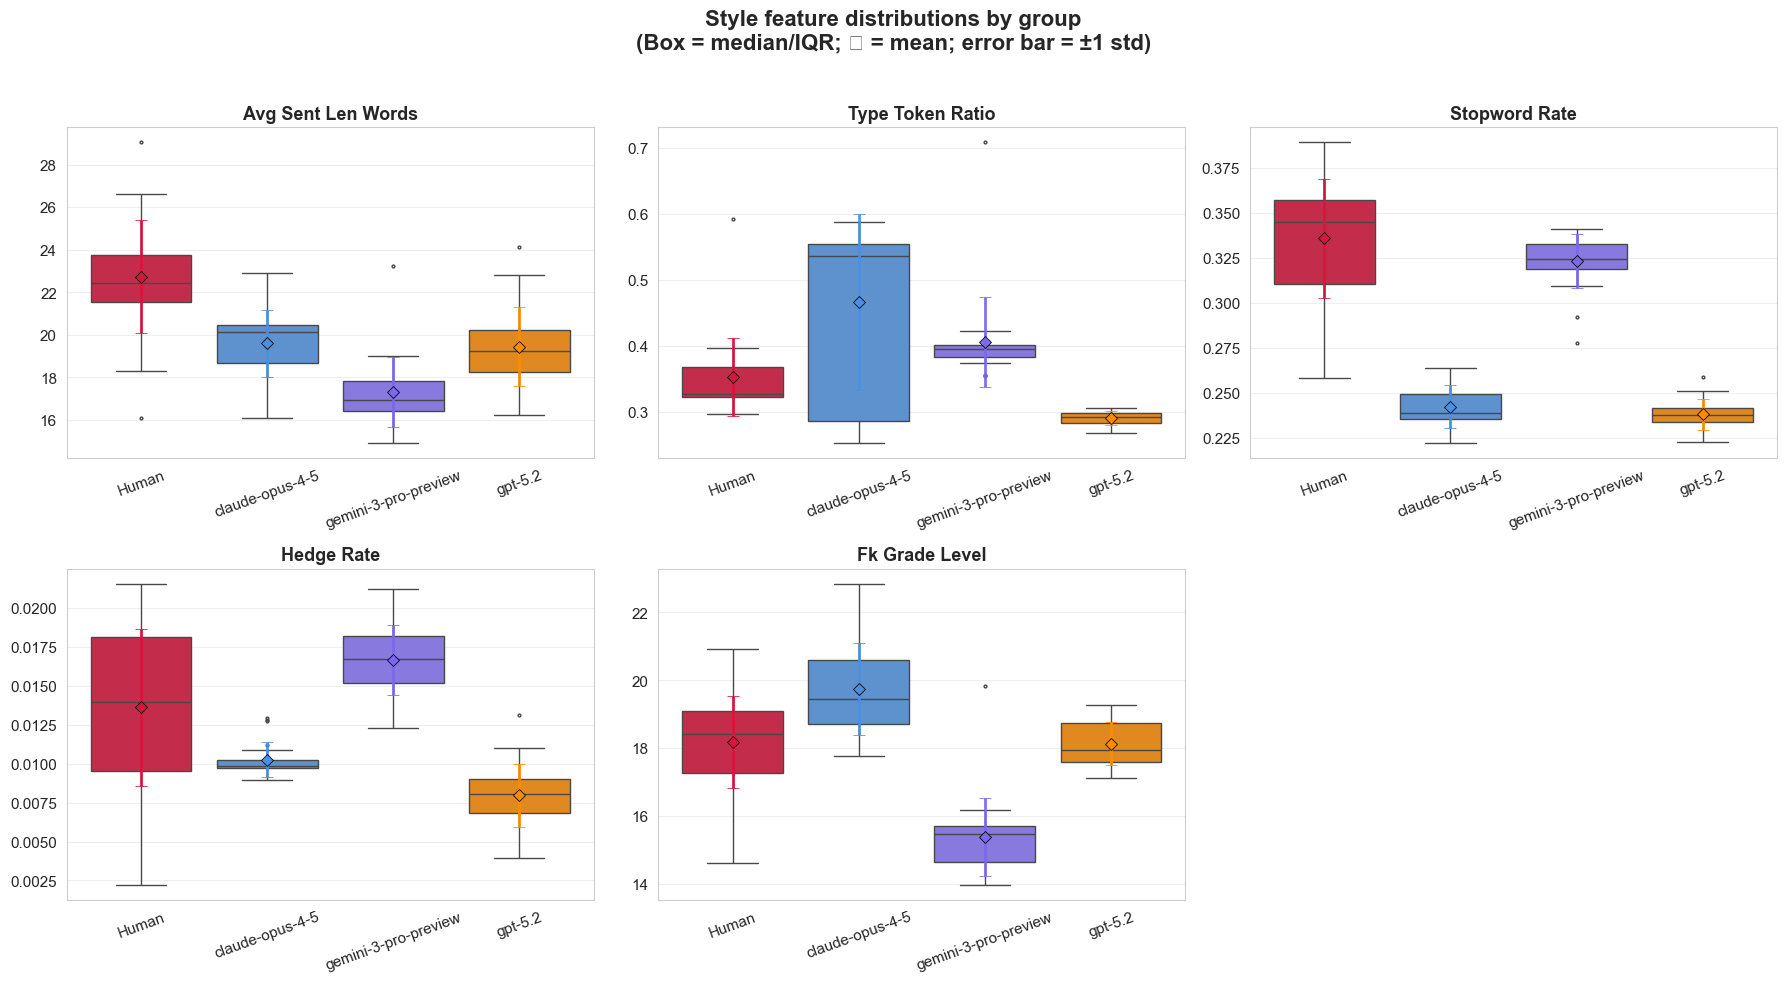

✓ Figure saved to: results/figures/style_features_by_model_boxplots.png

Summary (mean / median / std) by group:
                     avg_sent_len_words                type_token_ratio               stopword_rate               hedge_rate               fk_grade_level               
                                   mean  median    std             mean median    std          mean median    std       mean median    std           mean  median    std
group_model                                                                                                                                                             
Human                            22.741  22.448  2.667            0.353  0.328  0.060         0.336  0.345  0.033      0.014  0.014  0.005         18.189  18.429  1.347
claude-opus-4-5                  19.614  20.125  1.573            0.467  0.536  0.133         0.242  0.239  0.012      0.010  0.010  0.001         19.744  19.461  1.356
gemini-3-pro-preview             17.306  1

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots per feature across Human and each AI model
# Box = median/IQR, whiskers = spread, ◆ = mean, error bar = ±1 std

if 'style_df' not in globals():
    raise RuntimeError("style_df not found. Run the style feature extraction cell first.")
if 'ai_df' not in globals():
    raise RuntimeError("ai_df not found. Run the AI proposal loading cell first.")

# Reconstruct per-model labels aligned to style_df construction order: Human rows first, then AI rows
n_h = int((style_df['group'] == 'Human').sum()) if 'group' in style_df.columns else 0
if n_h == 0:
    n_h = len(human_df)

ai_model_labels = ai_df['model'].tolist()
expected_ai = len(style_df) - n_h
if len(ai_model_labels) != expected_ai:
    raise ValueError(
        f"Alignment error: style_df has {len(style_df)} rows with n_h={n_h}, expected {expected_ai} AI rows, "
        f"but ai_df['model'] has {len(ai_model_labels)} labels."
    )

style_plot = style_df.copy()
style_plot['group_model'] = (['Human'] * n_h) + ai_model_labels

# Compact, interpretable features for quick comparison
features_to_plot = [
    'avg_sent_len_words',
    'type_token_ratio',
    'stopword_rate',
    'hedge_rate',
    'fk_grade_level',
    'header_lines'
]
features_to_plot = [f for f in features_to_plot if f in style_plot.columns]

# Prepare long DF
long_df = style_plot[['group_model'] + features_to_plot].replace([np.inf, -np.inf], np.nan)
for f in features_to_plot:
    long_df[f] = long_df[f].fillna(long_df[f].median())
long_df = long_df.melt(id_vars='group_model', var_name='feature', value_name='value')

# Group order (Human first, then models)
if 'ai_models' in globals():
    group_order = ['Human'] + [m for m in ai_models if m in set(style_plot['group_model'])]
else:
    group_order = ['Human'] + sorted([m for m in style_plot['group_model'].unique() if m != 'Human'])

# Plot subplots
n_feat = len(features_to_plot)
ncols = 3
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

# Use consistent group colors if defined earlier in the notebook
if 'colors' in globals() and isinstance(colors, dict):
    colors_local = dict(colors)
else:
    colors_local = {}

# Ensure every group has a color (fallback for any missing keys)
for idx, g in enumerate(group_order):
    colors_local.setdefault(g, f"C{idx % 10}")

palette_dict = {g: colors_local[g] for g in group_order}

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    df_f = long_df[long_df['feature'] == feat]

    # Boxes colored by group
    sns.boxplot(
        data=df_f, x='group_model', y='value', order=group_order,
        ax=ax, palette=palette_dict, fliersize=2
    )

    # Overlay mean ± std as colored diamonds (matches group color)
    stats = df_f.groupby('group_model')['value'].agg(['mean', 'std']).reindex(group_order)
    for xpos, g in enumerate(group_order):
        if g not in stats.index or pd.isna(stats.loc[g, 'mean']):
            continue
        m = float(stats.loc[g, 'mean'])
        s = float(stats.loc[g, 'std']) if not pd.isna(stats.loc[g, 'std']) else 0.0
        ax.errorbar(
            xpos, m, yerr=s,
            fmt='D',
            color=colors_local[g], ecolor=colors_local[g],
            elinewidth=2, capsize=4,
            markersize=6,
            markeredgecolor='black', markeredgewidth=0.6,
            alpha=0.95,
            zorder=10
        )

    ax.set_title(feat.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Style feature distributions by group\n(Box = median/IQR; ◆ = mean; error bar = ±1 std)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

out_path = 'results/figures/style_features_by_model_boxplots.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")

# Print a compact table of mean/median/std
summary = style_plot.groupby('group_model')[features_to_plot].agg(['mean', 'median', 'std']).round(3)
print("\nSummary (mean / median / std) by group:")
print(summary.to_string())

### Analysis 2.3.5: Style-only baseline (can style predict source?)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("="*85)
print("STYLE-ONLY BASELINE: HUMAN VS AI")
print("="*85)

# Use all numeric style features
feature_cols = [c for c in style_df.columns if c not in {'group','is_ai'}]
X = style_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[feature_cols].median()).values
y = style_df['is_ai'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    )
)

auc_scores = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
bal_scores = cross_val_score(clf, X, y, cv=cv, scoring='balanced_accuracy')

print(f"CV AUROC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
print(f"CV balanced accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}")

# Permutation test for AUROC (style-only)
# (Keep permutations moderate for notebook runtime; increase if needed.)
obs_score, perm_scores, p_value = permutation_test_score(
    clf, X, y,
    cv=cv,
    scoring='roc_auc',
    n_permutations=1000,
    n_jobs=-1,
    random_state=42
)

print("\nPermutation test (AUROC, 1,000 label shuffles):")
print(f"  Observed AUROC: {obs_score:.3f}")
print(f"  Null mean AUROC: {perm_scores.mean():.3f} ± {perm_scores.std():.3f}")
print(f"  p-value: {p_value:.4f}")

if obs_score >= 0.80:
    print("  → Strong evidence that style alone separates Human vs AI.")
elif obs_score >= 0.60:
    print("  → Moderate evidence that style contributes to separation.")
else:
    print("  → Style-only separation is weak; downstream separation is less likely to be purely stylistic.")


STYLE-ONLY BASELINE: HUMAN VS AI
CV AUROC: 0.980 ± 0.028
CV balanced accuracy: 0.894 ± 0.093

Permutation test (AUROC, 1,000 label shuffles):
  Observed AUROC: 0.980
  Null mean AUROC: 0.509 ± 0.099
  p-value: 0.0010
  → Strong evidence that style alone separates Human vs AI.


#### Visualization: Style-only baseline results (CV + permutation test)

**How to read:** Left panel shows cross-validation fold performance (each dot = one CV fold; box = distribution). Right panel shows the permutation-test *null* distribution of AUROC when Human/AI labels are shuffled; the vertical red line is the observed AUROC—if it sits far in the right tail, style alone separates groups beyond chance (small p-value).

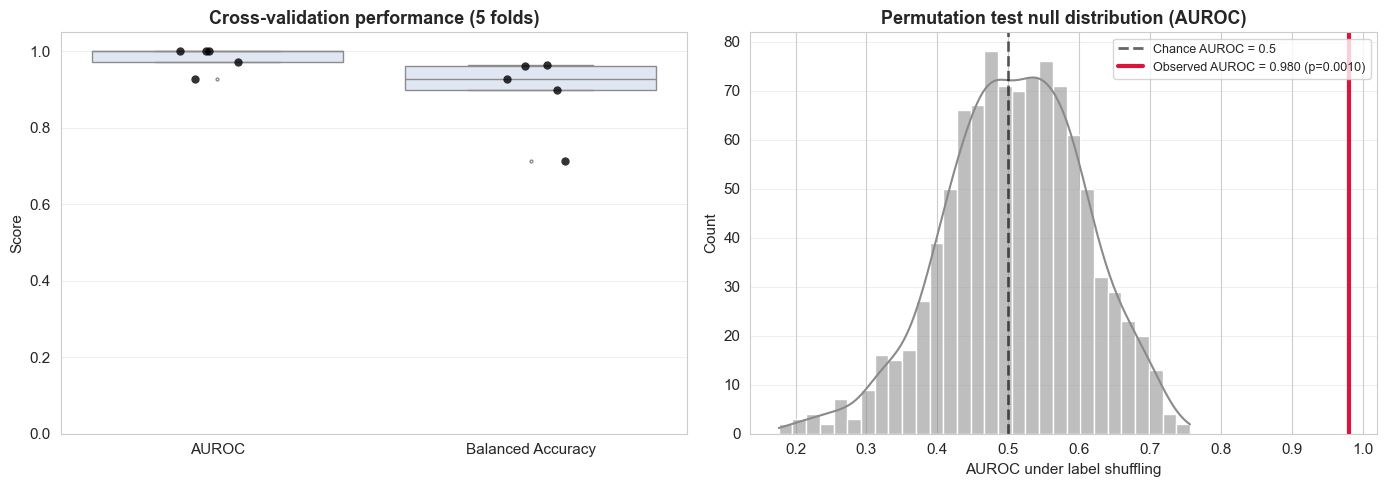

✓ Figure saved to: results/figures/style_only_baseline_viz.png

Interpretation:
- Left: tighter boxes/points = stable CV estimates; higher = better separation.
- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).


In [ ]:
# Visualization for style-only baseline results
import matplotlib.pyplot as plt

# 1) CV fold distributions (AUROC + balanced accuracy)
cv_plot_df = pd.DataFrame({
    'Fold': np.arange(1, len(auc_scores) + 1),
    'AUROC': auc_scores,
    'Balanced Accuracy': bal_scores,
})
cv_long = cv_plot_df.melt(id_vars='Fold', var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV score distributions
ax = axes[0]
sns.boxplot(data=cv_long, x='Metric', y='Score', ax=ax, color='#DDE6F5', fliersize=2)
sns.stripplot(data=cv_long, x='Metric', y='Score', ax=ax, color='black', size=6, jitter=0.12, alpha=0.8)
ax.set_title('Cross-validation performance (5 folds)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0.0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Right: permutation null distribution
ax = axes[1]
sns.histplot(perm_scores, bins=30, kde=True, ax=ax, color='#8A8A8A', alpha=0.55)
ax.axvline(0.5, color='black', linestyle='--', linewidth=2, alpha=0.6, label='Chance AUROC = 0.5')
ax.axvline(obs_score, color='crimson', linestyle='-', linewidth=3,
           label=f'Observed AUROC = {obs_score:.3f} (p={p_value:.4f})')
ax.set_title('Permutation test null distribution (AUROC)', fontsize=13, fontweight='bold')
ax.set_xlabel('AUROC under label shuffling')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()

out_path = 'results/figures/style_only_baseline_viz.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Figure saved to: {out_path}")
print("\nInterpretation:")
print("- Left: tighter boxes/points = stable CV estimates; higher = better separation.")
print("- Right: if the red line is far to the right of the gray histogram, the result is unlikely under chance (small p).")

### Analysis 2.3.6A: Style-controlled sensitivity via residualization

In [ ]:
from sklearn.metrics.pairwise import cosine_distances

print("="*85)
print("STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)")
print("="*85)

if 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found in workspace variables (expected `human_embeddings` and `ai_embeddings`).")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    group = np.array([0] * len(E_h) + [1] * len(E_a))  # 0=Human, 1=AI

    # Style covariates (compact set)
    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    cov = StandardScaler().fit_transform(cov)

    # Outcomes from embeddings
    centroid_all = E.mean(axis=0, keepdims=True)
    dist_to_all = cosine_distances(E, centroid_all).ravel()

    centroid_h = E_h.mean(axis=0, keepdims=True)
    centroid_a = E_a.mean(axis=0, keepdims=True)
    dist_to_group = np.where(group == 0,
                             cosine_distances(E, centroid_h).ravel(),
                             cosine_distances(E, centroid_a).ravel())

    def _ols_group_coef(y, g, covariates):
        X = np.column_stack([np.ones(len(y)), g.astype(float), covariates])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta[1], beta

    def perm_test_group_coef(y, g, covariates, n_perm=5000, seed=42):
        rng = np.random.default_rng(seed)
        obs_coef, _ = _ols_group_coef(y, g, covariates)
        null = np.zeros(n_perm, dtype=float)
        for i in range(n_perm):
            g_perm = rng.permutation(g)
            null[i], _ = _ols_group_coef(y, g_perm, covariates)
        p_two = (np.mean(np.abs(null) >= abs(obs_coef)) + 1) / (n_perm + 1)
        return obs_coef, null, p_two

    def summarize_outcome(name, y):
        mean_h = float(np.mean(y[group == 0]))
        mean_a = float(np.mean(y[group == 1]))
        print(f"\nOutcome: {name}")
        print(f"  Unadjusted means: Human={mean_h:.4f}, AI={mean_a:.4f}, (AI-Human)={mean_a-mean_h:+.4f}")
        coef, null, p = perm_test_group_coef(y, group, cov, n_perm=5000, seed=42)
        print(f"  Style-adjusted group coef (AI indicator): {coef:+.6f}")
        print(f"  Permutation p (two-sided, 5,000 shuffles): {p:.4f}")

    summarize_outcome('Cosine distance to overall centroid', dist_to_all)
    summarize_outcome('Cosine distance to own-group centroid', dist_to_group)


STYLE-CONTROLLED EMBEDDING OUTCOMES (RESIDUALIZATION)

Outcome: Cosine distance to overall centroid
  Unadjusted means: Human=0.0393, AI=0.0901, (AI-Human)=+0.0508
  Style-adjusted group coef (AI indicator): +0.043093
  Permutation p (two-sided, 5,000 shuffles): 0.0002

Outcome: Cosine distance to own-group centroid
  Unadjusted means: Human=0.0321, AI=0.0894, (AI-Human)=+0.0573
  Style-adjusted group coef (AI indicator): +0.048566
  Permutation p (two-sided, 5,000 shuffles): 0.0002


### Style-adjusted centroid dispersion (All Groups vs Human)


These tests repeat the same Mann–Whitney U, Cliff’s delta, and permutation test comparisons as the unadjusted centroid-dispersion section, but using **style-adjusted (residualized)** distances-to-own-group-centroid.

Compute each proposal’s distance-to-its-group-centroid (y_raw).
Fit a simple linear model: y_raw ~ (style features).
Subtract the model’s prediction from y_raw to get a residual.
Add back the overall mean (just to keep numbers on a similar scale).
Result: y_adj = “dispersion after removing what style can explain”.
Statistical tests on style-adjusted dispersion:
Same tests, just run on y_adj instead of y_raw.
So your MW / Cliff’s delta / permutation test become: “Are groups still different in dispersion after removing style effects?”

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("\n" + "="*85)
print("STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)")
print("="*85)

# ---- helpers (define if not already in notebook) ----
if 'cliffs_delta' not in globals():
    def cliffs_delta(x, y):
        """Cliff's delta: P(x>y) - P(x<y)."""
        x = np.asarray(x)
        y = np.asarray(y)
        gt = 0
        lt = 0
        for xi in x:
            gt += np.sum(xi > y)
            lt += np.sum(xi < y)
        return (gt - lt) / (len(x) * len(y))

if 'interpret_cliffs_delta' not in globals():
    def interpret_cliffs_delta(d):
        ad = abs(d)
        if ad < 0.147:
            return 'negligible'
        if ad < 0.33:
            return 'small'
        if ad < 0.474:
            return 'medium'
        return 'large'

def _perm_test_mean_diff(x, y, n_perm=10000, seed=42):
    """Two-sided permutation test on mean difference: mean(x)-mean(y).

    Named uniquely to avoid conflicts with any earlier `permutation_test()` defined elsewhere in the notebook.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    obs = float(np.mean(x) - np.mean(y))
    pooled = np.concatenate([x, y])
    n_x = len(x)
    null = np.empty(n_perm, dtype=float)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        null[i] = float(np.mean(perm[:n_x]) - np.mean(perm[n_x:]))
    p = (np.mean(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)
    return p, obs, null

# ---- compute y_adj robustly (don’t assume previous cell variables exist) ----
if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
elif 'ai_df' not in globals() or 'model_embeddings_dict' not in globals():
    print("⚠️ ai_df/model_embeddings_dict not found. Run the proposal loading/embedding setup cells first.")
else:
    # Align document order: Human first, then AI (matches style_df build above)
    E_h = np.asarray(human_embeddings)
    E_a = np.asarray(ai_embeddings)
    E = np.vstack([E_h, E_a])
    n_h, n_a = len(E_h), len(E_a)

    # Labels (Human first, then AI per-model)
    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"
    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Group order consistent with earlier analyses
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    # Raw distance-to-own-group-centroid
    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization on y_raw
    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()

    # Split adjusted distances
    human_adj = y_adj[labels == 'Human']
    ai_adj = y_adj[labels != 'Human']

    model_adj = {m: y_adj[labels == m] for m in group_order if m != 'Human'}

    # ---- tests ----
    adj_comparison_results = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]")
    print("-"*85)

    u_stat, p_mw = mannwhitneyu(ai_adj, human_adj, alternative='two-sided')
    d = cliffs_delta(ai_adj, human_adj)
    d_interp = interpret_cliffs_delta(d)
    p_perm, obs_diff, _ = _perm_test_mean_diff(ai_adj, human_adj, n_perm=10000, seed=42)

    print("\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat:,.0f}, p-value: {p_mw:.4e}")
    print("\nCliff's Delta:")
    print(f"  δ = {d:.4f} ({d_interp} effect)")
    if d > 0:
        print("  → All AI proposals are MORE dispersed from center (after style adjustment)")
    else:
        print("  → Human proposals are MORE dispersed from center (after style adjustment)")
    print("\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference (mean AI - mean Human): {obs_diff:.4f}, p-value: {p_perm:.4f}")

    adj_comparison_results.append({
        'group': 'All AI',
        'u_stat': u_stat,
        'p_value_mw': p_mw,
        'delta': d,
        'delta_interp': d_interp,
        'p_value_perm': p_perm
    })

    for model in group_order:
        if model == 'Human':
            continue
        vals = model_adj.get(model)
        if vals is None or len(vals) == 0:
            continue

        print("\n" + "-"*85)
        print(f"Comparison: {model} vs Human [STYLE-ADJUSTED]")
        print("-"*85)

        u_stat_m, p_mw_m = mannwhitneyu(vals, human_adj, alternative='two-sided')
        d_m = cliffs_delta(vals, human_adj)
        d_interp_m = interpret_cliffs_delta(d_m)
        p_perm_m, obs_diff_m, _ = _perm_test_mean_diff(vals, human_adj, n_perm=10000, seed=42)

        print("\nMann-Whitney U Test:")
        print(f"  U-statistic: {u_stat_m:,.0f}, p-value: {p_mw_m:.4e}")
        print("\nCliff's Delta:")
        print(f"  δ = {d_m:.4f} ({d_interp_m} effect)")
        if d_m > 0:
            print(f"  → {model} proposals are MORE dispersed from center (after style adjustment)")
        else:
            print("  → Human proposals are MORE dispersed from center (after style adjustment)")
        print("\nPermutation Test (10,000 permutations):")
        print(f"  Observed difference (mean {model} - mean Human): {obs_diff_m:.4f}, p-value: {p_perm_m:.4f}")

        adj_comparison_results.append({
            'group': model,
            'u_stat': u_stat_m,
            'p_value_mw': p_mw_m,
            'delta': d_m,
            'delta_interp': d_interp_m,
            'p_value_perm': p_perm_m
        })

    # Summary table
    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - Style-adjusted Centroid Dispersion")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for r in adj_comparison_results:
        print(f"{r['group']:<30} {r['delta']:<12.4f} {r['delta_interp']:<20} {r['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more dispersed; Negative δ = Human more dispersed (style-adjusted)")
    print("="*85)



STATISTICAL TESTS: Style-adjusted Centroid Dispersion (All Groups vs Human)

-------------------------------------------------------------------------------------
Comparison: All AI (combined) vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 619, p-value: 1.1666e-01

Cliff's Delta:
  δ = -0.2199 (small effect)
  → Human proposals are MORE dispersed from center (after style adjustment)

Permutation Test (10,000 permutations):
  Observed difference (mean AI - mean Human): 0.0049, p-value: 0.0002

-------------------------------------------------------------------------------------
Comparison: claude-opus-4-5 vs Human [STYLE-ADJUSTED]
-------------------------------------------------------------------------------------

Mann-Whitney U Test:
  U-statistic: 297, p-value: 4.8205e-01

Cliff's Delta:
  δ = 0.1229 (negligible effect)
  → claude-opus-4-5 proposals are MORE dispersed from center (

CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)


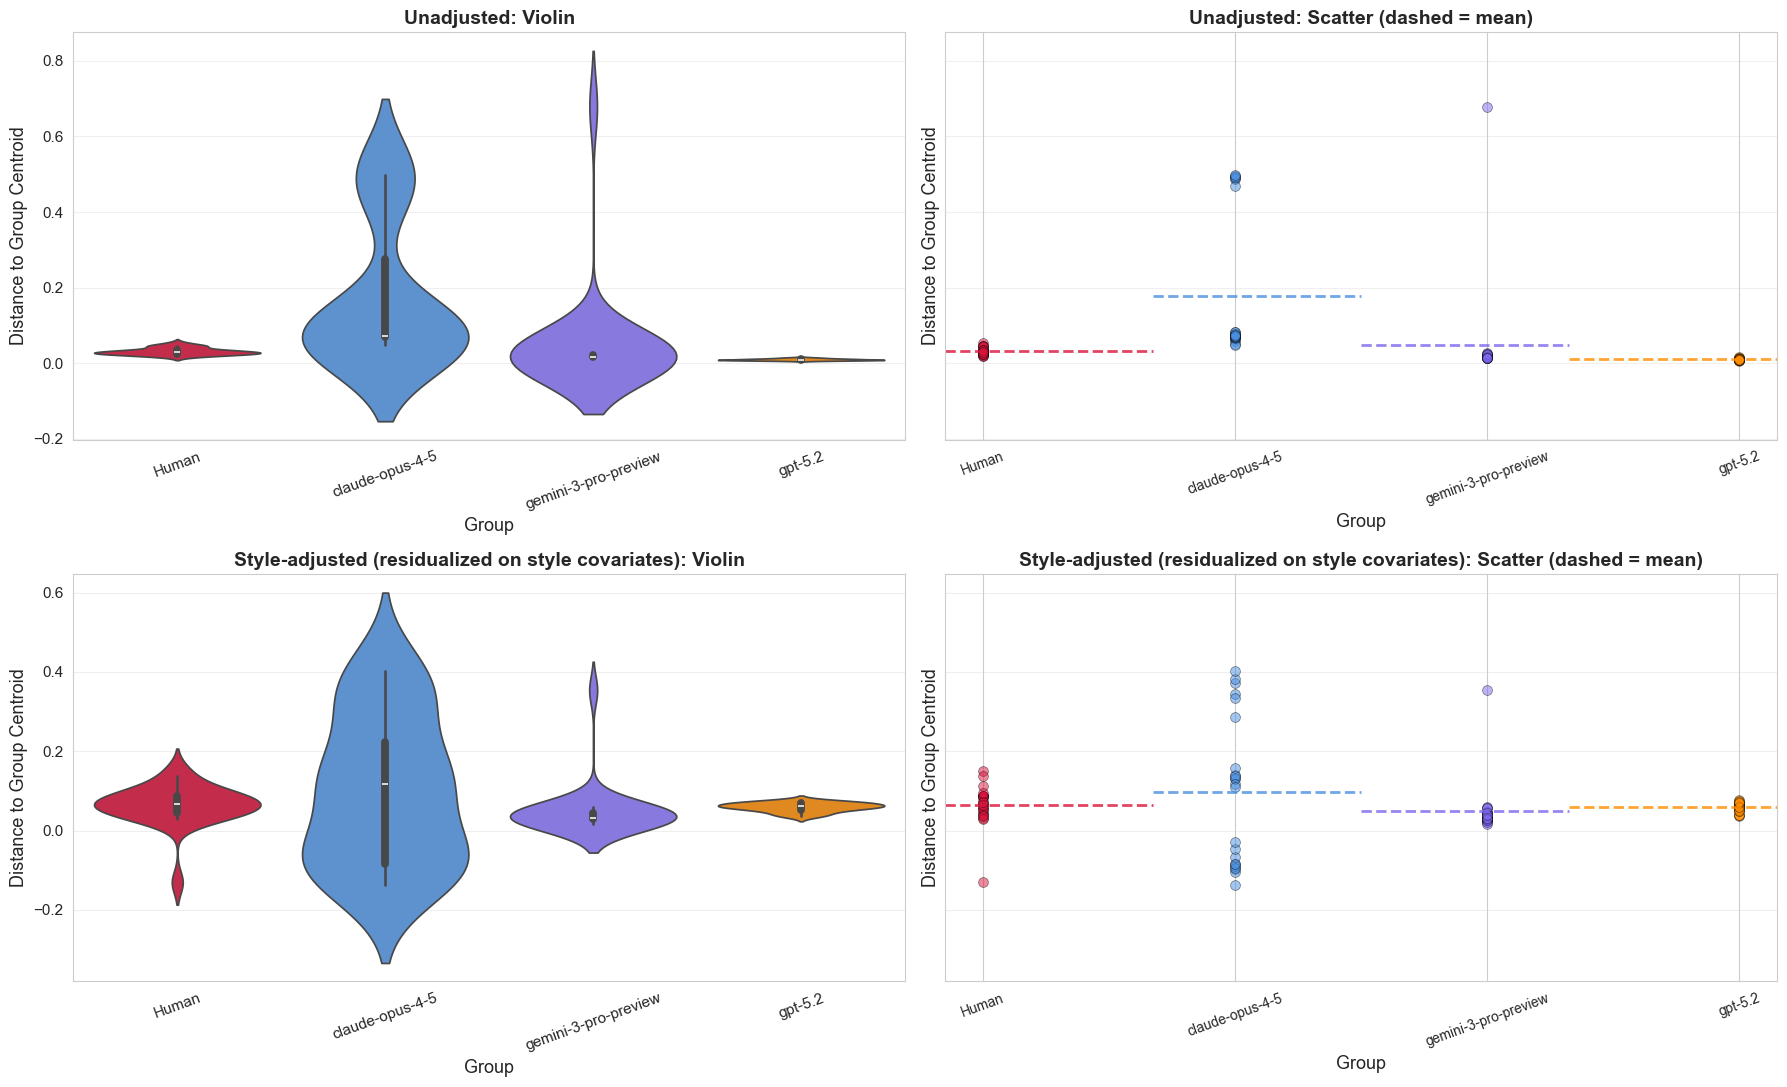

✓ Figure saved to: results/figures/centroid_dispersion_style_adjusted.png

Note: 'Style-adjusted' removes linear effects of selected style covariates (not group).


In [ ]:
# ----------------------------
# Visualization: centroid dispersion before vs after style residualization
# ----------------------------

from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

print("="*85)
print("CENTROID DISPERSION: UNADJUSTED vs STYLE-ADJUSTED (RESIDUALIZED)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # Labels (Human first, then AI) — match the style_df construction order
    n_h = len(human_embeddings)
    n_a = len(ai_embeddings)

    # Prefer the notebook's model list if available; otherwise derive from ai_df
    if 'ai_models' in globals():
        ai_models_local = list(ai_models)
    else:
        ai_models_local = sorted(ai_df['model'].dropna().unique().tolist())

    ai_model_labels = ai_df['model'].tolist()
    assert len(ai_model_labels) == n_a, "ai_df['model'] length must match ai_embeddings"

    labels = np.array((['Human'] * n_h) + ai_model_labels)

    # Embeddings matrix
    E = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    # Compute distance-to-own-group-centroid for each proposal (Human + each AI model)
    group_order = ['Human'] + [m for m in ai_models_local if m in set(ai_model_labels)]

    y_raw = np.zeros(len(labels), dtype=float)
    for g in group_order:
        idx = np.where(labels == g)[0]
        if len(idx) == 0:
            continue
        centroid = E[idx].mean(axis=0, keepdims=True)
        y_raw[idx] = cosine_distances(E[idx], centroid).ravel()

    # Style residualization (remove linear effect of style covariates; keep scale comparable)
    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(y_raw)), X_cov])
    beta, *_ = np.linalg.lstsq(X, y_raw, rcond=None)
    y_pred = X @ beta
    y_adj = (y_raw - y_pred) + y_raw.mean()  # residuals shifted back to original mean

    # Colors: reuse if present, else define a fallback
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = colors
    else:
        colors_local = {'Human': '#DC143C'}
        for i, m in enumerate(group_order[1:]):
            colors_local[m] = f"C{(i+1)%10}"

    def _plot_row(ax_violin, ax_scatter, y, row_title):
        # Build long DF
        plot_df = pd.DataFrame({'Group': labels, 'Distance to Centroid': y})

        palette_list = [colors_local.get(g, 'gray') for g in group_order]

        sns.violinplot(
            data=plot_df, x='Group', y='Distance to Centroid',
            order=group_order, palette=palette_list, ax=ax_violin
        )
        ax_violin.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_violin.set_xlabel('Group', fontsize=13)
        ax_violin.set_title(f'{row_title}: Violin', fontsize=14, fontweight='bold')
        ax_violin.tick_params(axis='x', rotation=20)
        ax_violin.grid(alpha=0.3, axis='y')

        # Scatter with per-group mean lines
        for xpos, g in enumerate(group_order):
            vals = plot_df.loc[plot_df['Group'] == g, 'Distance to Centroid'].values
            if len(vals) == 0:
                continue
            ax_scatter.scatter(
                [xpos] * len(vals), vals,
                alpha=0.5, color=colors_local.get(g, 'gray'),
                s=50, edgecolors='black', linewidth=0.5
            )
            ax_scatter.axhline(
                np.mean(vals),
                xmin=xpos/len(group_order), xmax=(xpos+1)/len(group_order),
                color=colors_local.get(g, 'gray'), linestyle='--', linewidth=2, alpha=0.8
            )

        ax_scatter.set_xticks(range(len(group_order)))
        ax_scatter.set_xticklabels(group_order, rotation=20, fontsize=10)
        ax_scatter.set_ylabel('Distance to Group Centroid', fontsize=13)
        ax_scatter.set_xlabel('Group', fontsize=13)
        ax_scatter.set_title(f'{row_title}: Scatter (dashed = mean)', fontsize=14, fontweight='bold')
        ax_scatter.grid(alpha=0.3, axis='y')

    fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharey='row')
    _plot_row(axes[0, 0], axes[0, 1], y_raw, 'Unadjusted')
    _plot_row(axes[1, 0], axes[1, 1], y_adj, 'Style-adjusted (residualized on style covariates)')

    plt.tight_layout()
    out_path = 'results/figures/centroid_dispersion_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Figure saved to: {out_path}")
    print("\nNote: 'Style-adjusted' removes linear effects of selected style covariates (not group).")


### Style-adjust nearest-neighbor (NN) distances by residualizing embeddings


This removes the *linear* contribution of selected style covariates from the embedding vectors (dimension-wise OLS), then recomputes cosine NN distances on the residual embeddings (renormalized).

STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)

COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS

GROUP                               N        Mean       Median     Min        Max       
-------------------------------------------------------------------------------------
Human                               23       0.5306     0.5353     0.1873     0.6765    

claude-opus-4-5                     23       0.2973     0.2266     0.1129     0.5995    
gemini-3-pro-preview                23       0.4117     0.3944     0.2784     0.6000    
gpt-5.2                             23       0.5667     0.6000     0.3527     0.7583    

All AI (combined)                   69       0.4252     0.4096     0.1129     0.7583    

💡 INTERPRETATION:
   - Higher mean NN distance = more isolated proposals (outliers)
   - Lower mean NN distance = proposals cluster together
   - Distances are computed AFTER removing linear embedding variation explained by style covariates

O

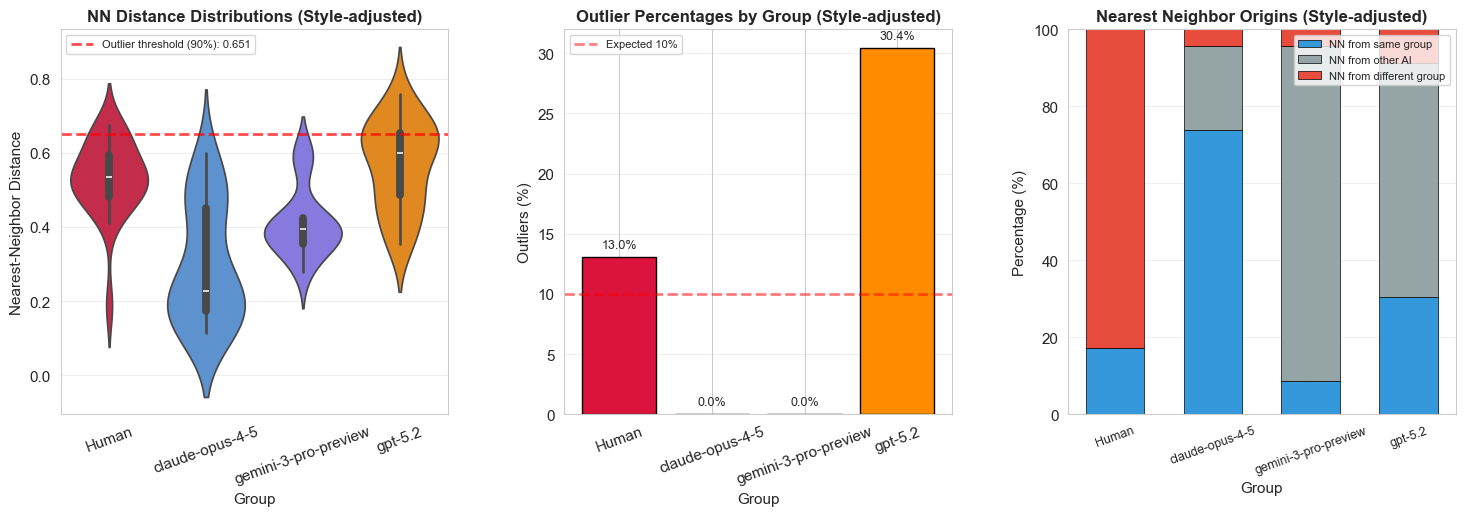


✓ Figure saved to: results/figures/nearest_neighbor_by_model_style_adjusted.png

Note: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.


In [ ]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

print("="*85)
print("STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS (Metadata-aligned)")
print("="*85)

if 'style_df' not in globals():
    print("⚠️ style_df not found. Run the style feature extraction cell first.")
elif 'human_embeddings' not in globals() or 'ai_embeddings' not in globals():
    print("⚠️ Embeddings not found (`human_embeddings`, `ai_embeddings`). Run embedding generation first.")
else:
    # ----------------------------
    # 0) Build per-row labels that match embedding order
    # ----------------------------
    n_human = len(human_embeddings)
    n_ai = len(ai_embeddings)

    if 'ai_metadata' in globals() and isinstance(ai_metadata, list) and len(ai_metadata) == n_ai:
        ai_model_labels = [str(r.get('model', 'AI')) for r in ai_metadata]
    elif 'ai_df' in globals() and len(ai_df) == n_ai and 'model' in ai_df.columns:
        print("⚠️ ai_metadata not available; falling back to ai_df['model'] order (may misalign if embeddings were shuffled).")
        ai_model_labels = [str(x) for x in ai_df['model'].tolist()]
    else:
        raise RuntimeError("Cannot infer AI model labels aligned to ai_embeddings. Need ai_metadata (preferred) or ai_df with matching order.")

    labels = np.array((['Human'] * n_human) + ai_model_labels)

    # Stable group order
    if 'ai_models' in globals():
        ai_models_local = [m for m in list(ai_models) if m in set(ai_model_labels)]
    else:
        ai_models_local = sorted(list(dict.fromkeys(ai_model_labels)))

    group_order = ['Human'] + ai_models_local

    # ----------------------------
    # 1) Build embedding matrix (Human first, then AI) and residualize on style
    # ----------------------------
    all_embeddings = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])

    cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
    X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
    X_cov = StandardScaler().fit_transform(X_cov)
    X = np.column_stack([np.ones(len(X_cov)), X_cov])

    B, *_ = np.linalg.lstsq(X, all_embeddings, rcond=None)
    all_embeddings_resid = all_embeddings - (X @ B)
    all_embeddings_resid = all_embeddings_resid / (np.linalg.norm(all_embeddings_resid, axis=1, keepdims=True) + 1e-12)

    # ----------------------------
    # 2) Compute full distance matrix + NN distances (STYLE-ADJUSTED)
    # ----------------------------
    print("\n" + "="*85)
    print("COMPUTING STYLE-ADJUSTED NEAREST-NEIGHBOR DISTANCES FOR ALL GROUPS")
    print("="*85)

    all_distances_adj = cosine_distances(all_embeddings_resid)
    np.fill_diagonal(all_distances_adj, np.inf)
    nn_distances_adj = all_distances_adj.min(axis=1)

    # Group-wise NN distances
    human_nn_dists_adj = nn_distances_adj[labels == 'Human']
    ai_nn_dists_adj = nn_distances_adj[labels != 'Human']

    model_nn_dists_adj = {g: nn_distances_adj[labels == g] for g in ai_models_local}

    # Print statistics table
    print(f"\n{'GROUP':<35} {'N':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10}")
    print("-"*85)
    print(f"{'Human':<35} {len(human_nn_dists_adj):<8} {human_nn_dists_adj.mean():<10.4f} {np.median(human_nn_dists_adj):<10.4f} {human_nn_dists_adj.min():<10.4f} {human_nn_dists_adj.max():<10.4f}")
    print()
    for model in ai_models_local:
        dists = model_nn_dists_adj[model]
        print(f"{model:<35} {len(dists):<8} {dists.mean():<10.4f} {np.median(dists):<10.4f} {dists.min():<10.4f} {dists.max():<10.4f}")
    print()
    print(f"{'All AI (combined)':<35} {len(ai_nn_dists_adj):<8} {ai_nn_dists_adj.mean():<10.4f} {np.median(ai_nn_dists_adj):<10.4f} {ai_nn_dists_adj.min():<10.4f} {ai_nn_dists_adj.max():<10.4f}")

    print("="*85)
    print("\n💡 INTERPRETATION:")
    print("   - Higher mean NN distance = more isolated proposals (outliers)")
    print("   - Lower mean NN distance = proposals cluster together")
    print("   - Distances are computed AFTER removing linear embedding variation explained by style covariates")
    print("="*85)

    # ----------------------------
    # 3) Outlier detection (top 10% NN distances) - STYLE-ADJUSTED
    # ----------------------------
    threshold_adj = np.percentile(nn_distances_adj, 90)
    outliers_adj = nn_distances_adj > threshold_adj

    human_outliers_adj = int(outliers_adj[labels == 'Human'].sum())
    ai_outliers_adj = int(outliers_adj[labels != 'Human'].sum())
    model_outliers_adj = {g: int(outliers_adj[labels == g].sum()) for g in ai_models_local}

    print("\n" + "="*85)
    print("OUTLIER DETECTION (Top 10% NN distance) — STYLE-ADJUSTED")
    print("="*85)
    print(f"Threshold distance: {threshold_adj:.4f}")
    print()
    print(f"{'GROUP':<35} {'Outliers':<15} {'Total':<10} {'Percentage':<15}")
    print("-"*85)
    print(f"{'Human':<35} {human_outliers_adj:<15} {n_human:<10} {human_outliers_adj/n_human*100:<15.1f}%")
    print()
    for model in ai_models_local:
        n_model = int((labels == model).sum())
        print(f"{model:<35} {model_outliers_adj[model]:<15} {n_model:<10} {model_outliers_adj[model]/n_model*100:<15.1f}%")
    print()
    print(f"{'All AI (combined)':<35} {ai_outliers_adj:<15} {n_ai:<10} {ai_outliers_adj/n_ai*100:<15.1f}%")
    print("="*85)

    # ----------------------------
    # 4) Nearest-neighbor origin analysis — STYLE-ADJUSTED
    # ----------------------------
    nn_indices_adj = all_distances_adj.argmin(axis=1)
    nn_labels_adj = labels[nn_indices_adj]

    human_nn_same_group_adj = int((nn_labels_adj[labels == 'Human'] == 'Human').sum())
    human_nn_diff_group_adj = int(n_human - human_nn_same_group_adj)

    ai_nn_same_group_adj = int((nn_labels_adj[labels != 'Human'] != 'Human').sum())
    ai_nn_diff_group_adj = int(n_ai - ai_nn_same_group_adj)

    model_nn_analysis_adj = {}
    for model in ai_models_local:
        mask = labels == model
        total = int(mask.sum())
        nn_from_human = int((nn_labels_adj[mask] == 'Human').sum())
        nn_from_same_model = int((nn_labels_adj[mask] == model).sum())
        nn_from_other_ai = int(total - nn_from_human - nn_from_same_model)
        model_nn_analysis_adj[model] = {
            'from_human': nn_from_human,
            'from_same_model': nn_from_same_model,
            'from_other_ai': nn_from_other_ai,
            'total': total
        }

    print("\n" + "="*85)
    print("NEAREST NEIGHBOR GROUP ANALYSIS — STYLE-ADJUSTED")
    print("="*85)

    print(f"\n{'Human proposals:':<50}")
    print(f"  NN from same group (human): {human_nn_same_group_adj} ({human_nn_same_group_adj/n_human*100:.1f}%)")
    print(f"  NN from different group (AI): {human_nn_diff_group_adj} ({human_nn_diff_group_adj/n_human*100:.1f}%)")

    print(f"\n{'All AI proposals (combined):':<50}")
    print(f"  NN from same group (AI): {ai_nn_same_group_adj} ({ai_nn_same_group_adj/n_ai*100:.1f}%)")
    print(f"  NN from different group (human): {ai_nn_diff_group_adj} ({ai_nn_diff_group_adj/n_ai*100:.1f}%)")

    print("\n" + "-"*85)
    print("Per-Model NN Group Breakdown:")
    print("-"*85)

    for model in ai_models_local:
        data = model_nn_analysis_adj[model]
        print(f"\n{model}:")
        print(f"  NN from Human: {data['from_human']} ({data['from_human']/data['total']*100:.1f}%)")
        print(f"  NN from same model: {data['from_same_model']} ({data['from_same_model']/data['total']*100:.1f}%)")
        print(f"  NN from other AI models: {data['from_other_ai']} ({data['from_other_ai']/data['total']*100:.1f}%)")

    print("\n" + "="*85)
    print("\n💡 INTERPRETATION:")
    print("   - High 'NN from same model' = model produces similar proposals")
    print("   - High 'NN from Human' = model proposals resemble human work")
    print("   - All computed in style-adjusted residual embedding space")
    print("="*85)

    # ----------------------------
    # 5) Statistical tests vs Human (same tests) — STYLE-ADJUSTED
    # ----------------------------
    print("\n" + "="*85)
    print("STATISTICAL TESTS: NN Distances (All Groups vs Human) — STYLE-ADJUSTED")
    print("="*85)

    nn_comparison_results_adj = []

    print("\n" + "-"*85)
    print("Comparison: All AI (combined) vs Human")
    print("-"*85)

    u_stat_nn, p_value_nn = mannwhitneyu(ai_nn_dists_adj, human_nn_dists_adj, alternative='two-sided')
    delta_nn = cliffs_delta(ai_nn_dists_adj, human_nn_dists_adj)
    delta_nn_interp = interpret_cliffs_delta(delta_nn)
    p_value_perm_nn, obs_diff_nn, _ = permutation_test(ai_nn_dists_adj, human_nn_dists_adj)

    print(f"\nMann-Whitney U Test:")
    print(f"  U-statistic: {u_stat_nn:,.0f}, p-value: {p_value_nn:.4e}")
    print(f"\nCliff's Delta:")
    print(f"  δ = {delta_nn:.4f} ({delta_nn_interp} effect)")
    if delta_nn > 0:
        print(f"  → All AI proposals have MORE unique/outlier ideas (style-adjusted)")
    else:
        print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
    print(f"\nPermutation Test (10,000 permutations):")
    print(f"  Observed difference: {obs_diff_nn:.4f}, p-value: {p_value_perm_nn:.4f}")

    nn_comparison_results_adj.append({
        'group': 'All AI',
        'u_stat': u_stat_nn,
        'p_value_mw': p_value_nn,
        'delta': delta_nn,
        'delta_interp': delta_nn_interp,
        'p_value_perm': p_value_perm_nn
    })

    for model in ai_models_local:
        if model in model_nn_dists_adj:
            print("\n" + "-"*85)
            print(f"Comparison: {model} vs Human")
            print("-"*85)

            u_stat_model, p_value_mw_model = mannwhitneyu(model_nn_dists_adj[model], human_nn_dists_adj, alternative='two-sided')
            delta_model = cliffs_delta(model_nn_dists_adj[model], human_nn_dists_adj)
            delta_interp_model = interpret_cliffs_delta(delta_model)
            p_value_perm_model, obs_diff_model, _ = permutation_test(model_nn_dists_adj[model], human_nn_dists_adj)

            print(f"\nMann-Whitney U Test:")
            print(f"  U-statistic: {u_stat_model:,.0f}, p-value: {p_value_mw_model:.4e}")
            print(f"\nCliff's Delta:")
            print(f"  δ = {delta_model:.4f} ({delta_interp_model} effect)")
            if delta_model > 0:
                print(f"  → {model} proposals have MORE unique/outlier ideas (style-adjusted)")
            else:
                print(f"  → Human proposals have MORE unique/outlier ideas (style-adjusted)")
            print(f"\nPermutation Test (10,000 permutations):")
            print(f"  Observed difference: {obs_diff_model:.4f}, p-value: {p_value_perm_model:.4f}")

            nn_comparison_results_adj.append({
                'group': model,
                'u_stat': u_stat_model,
                'p_value_mw': p_value_mw_model,
                'delta': delta_model,
                'delta_interp': delta_interp_model,
                'p_value_perm': p_value_perm_model
            })

    print("\n" + "="*85)
    print("SUMMARY: Effect Sizes (Cliff's Delta) - NN Distances (Style-adjusted)")
    print("="*85)
    print(f"{'Group':<30} {'δ':<12} {'Effect Size':<20} {'p-value (MW)':<15}")
    print("-"*85)
    for result in nn_comparison_results_adj:
        print(f"{result['group']:<30} {result['delta']:<12.4f} {result['delta_interp']:<20} {result['p_value_mw']:<15.4e}")
    print("="*85)
    print("\n💡 Positive δ = AI more outlier-prone; Negative δ = Human more outlier-prone (style-adjusted)")
    print("="*85)

    # ----------------------------
    # 6) Visualization (same 3-panel layout) — STYLE-ADJUSTED
    # ----------------------------
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

    # Colors (reuse global mapping)
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = dict(colors)
    else:
        colors_local = {'Human': 'steelblue'}

    # 1. NN distance distributions by group
    ax1 = fig.add_subplot(gs[0, 0])
    nn_data = []
    for dist, label in [(human_nn_dists_adj, 'Human')] + [(model_nn_dists_adj[m], m) for m in ai_models_local if m in model_nn_dists_adj]:
        for val in dist:
            nn_data.append({'NN Distance': val, 'Group': label})

    nn_df = pd.DataFrame(nn_data)
    group_order_viz = ['Human'] + [m for m in ai_models_local if m in model_nn_dists_adj]
    palette_list = [colors_local.get(g, 'gray') for g in group_order_viz]

    sns.violinplot(data=nn_df, x='Group', y='NN Distance', ax=ax1, palette=palette_list, order=group_order_viz)
    ax1.axhline(threshold_adj, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Outlier threshold (90%): {threshold_adj:.3f}')
    ax1.set_ylabel('Nearest-Neighbor Distance', fontsize=11)
    ax1.set_xlabel('Group', fontsize=11)
    ax1.set_title('NN Distance Distributions (Style-adjusted)', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='x', rotation=20)
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3, axis='y')

    # 2. Outlier counts by group
    ax2 = fig.add_subplot(gs[0, 1])
    outlier_data = []
    outlier_data.append({'Group': 'Human', 'Outliers': human_outliers_adj, 'Total': n_human, 'Percentage': human_outliers_adj/n_human*100})
    for model in ai_models_local:
        if model in model_outliers_adj:
            n_model = len(model_embeddings_dict.get(model, []))
            outlier_data.append({'Group': model, 'Outliers': model_outliers_adj[model], 'Total': n_model, 'Percentage': model_outliers_adj[model]/n_model*100})

    outlier_df = pd.DataFrame(outlier_data)
    bars = ax2.bar(outlier_df['Group'], outlier_df['Percentage'], color=[colors_local.get(g, 'gray') for g in outlier_df['Group']], edgecolor='black', linewidth=1)
    ax2.axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Expected 10%')
    ax2.set_ylabel('Outliers (%)', fontsize=11)
    ax2.set_xlabel('Group', fontsize=11)
    ax2.set_title('Outlier Percentages by Group (Style-adjusted)', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=20)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3, axis='y')

    for bar, pct in zip(bars, outlier_df['Percentage']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    # 3. NN origins (stacked bar)
    ax3 = fig.add_subplot(gs[0, 2])

    groups = ['Human'] + [m for m in ai_models_local if m in model_nn_analysis_adj]
    nn_from_human_pcts = [human_nn_diff_group_adj/n_human*100]
    nn_from_same_pcts = [human_nn_same_group_adj/n_human*100]
    nn_from_other_ai_pcts = [0]

    for model in [m for m in ai_models_local if m in model_nn_analysis_adj]:
        data = model_nn_analysis_adj[model]
        nn_from_human_pcts.append(data['from_human']/data['total']*100)
        nn_from_same_pcts.append(data['from_same_model']/data['total']*100)
        nn_from_other_ai_pcts.append(data['from_other_ai']/data['total']*100)

    x_pos = np.arange(len(groups))
    width = 0.6

    p1 = ax3.bar(x_pos, nn_from_same_pcts, width, label='NN from same group', color='#3498db', edgecolor='black', linewidth=0.5)
    p2 = ax3.bar(x_pos, nn_from_other_ai_pcts, width, bottom=nn_from_same_pcts, label='NN from other AI', color='#95a5a6', edgecolor='black', linewidth=0.5)
    bottom = np.array(nn_from_same_pcts) + np.array(nn_from_other_ai_pcts)
    p3 = ax3.bar(x_pos, nn_from_human_pcts, width, bottom=bottom, label='NN from different group', color='#e74c3c', edgecolor='black', linewidth=0.5)

    ax3.set_ylabel('Percentage (%)', fontsize=11)
    ax3.set_xlabel('Group', fontsize=11)
    ax3.set_title('Nearest Neighbor Origins (Style-adjusted)', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(groups, rotation=20, fontsize=9)
    ax3.legend(fontsize=8, loc='upper right')
    ax3.grid(alpha=0.3, axis='y')
    ax3.set_ylim([0, 100])

    plt.tight_layout()
    out_fig = 'results/figures/nearest_neighbor_by_model_style_adjusted.png'
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Figure saved to: {out_fig}")
    print("\nNote: This mirrors the unadjusted NN pipeline, but all distances are computed in residual (style-adjusted) embedding space.")

### Visualization: Style-adjusted NN analysis in 2D (UMAP on residual embeddings)

This mirrors the unadjusted UMAP plot, but uses **style-residualized embeddings** (the same ones used to compute style-adjusted NN distances/outliers). It also prints a small diagnostic showing that style covariates have much weaker linear association with the embedding coordinates after residualization.


STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS

Style-adjustment diagnostic (lower is better):
  Mean |corr(style covariate, PC score)| (raw embeddings):  0.2036
  Mean |corr(style covariate, PC score)| (residual embeddings): 0.0405

Reducing residual embeddings to 2D using UMAP...
✓ UMAP completed: 92 proposals reduced to 2D


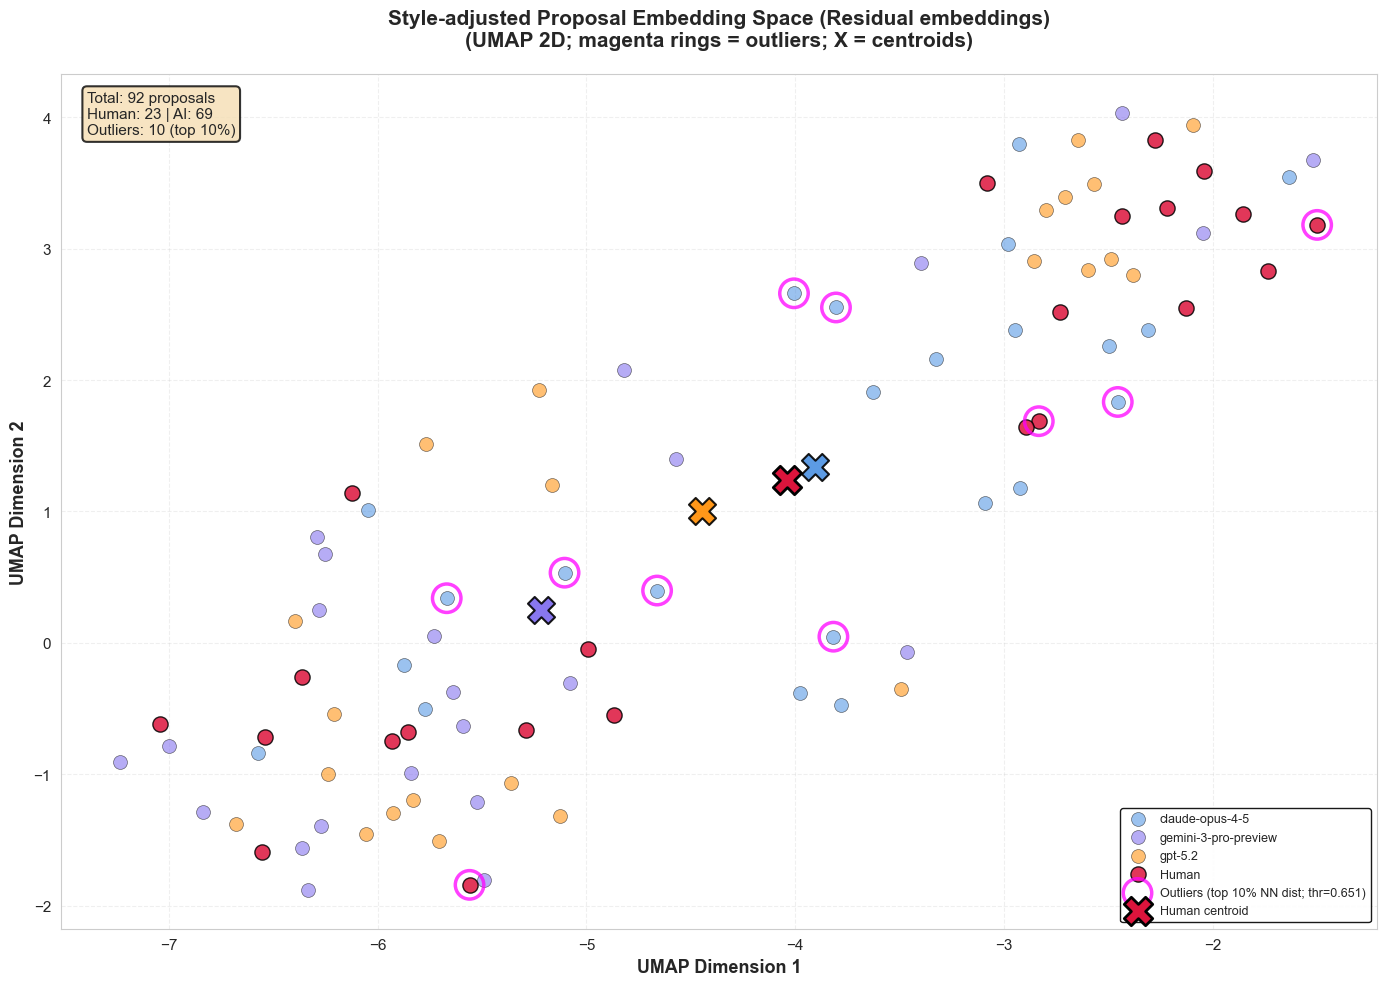


✓ Figure saved to: results/figures/embedding_space_2d_style_adjusted.png

💡 INTERPRETATION:
   - Clusters = similar proposals in style-adjusted residual space
   - Magenta rings = outliers by NN distance in residual space
   - X markers = group centroids in residual space


In [ ]:
import umap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("\n" + "="*85)
print("STYLE-ADJUSTED: UMAP PROJECTION FOR NN/OUTLIER ANALYSIS")
print("="*85)

# This cell expects you to have run the style-adjusted NN analysis cell above.
required_vars = ['all_embeddings_resid', 'outliers_adj', 'threshold_adj', 'n_human', 'n_ai', 'ai_models_local', 'model_embeddings_dict']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print(f"⚠️ Missing variables from prior style-adjusted NN cell: {missing}")
    print("Run the 'STYLE-ADJUSTED NEAREST-NEIGHBOR (NN) ANALYSIS' cell first.")
else:
    # ----------------------------
    # Sanity check: style signal reduction in embeddings (linear association)
    # ----------------------------
    try:
        cov_cols = ['n_words','avg_sent_len_words','type_token_ratio','hedge_rate','fk_grade_level']
        X_cov = style_df[cov_cols].replace([np.inf, -np.inf], np.nan).fillna(style_df[cov_cols].median()).values
        X_cov = StandardScaler().fit_transform(X_cov)

        E_raw = np.vstack([np.asarray(human_embeddings), np.asarray(ai_embeddings)])
        E_raw = E_raw / (np.linalg.norm(E_raw, axis=1, keepdims=True) + 1e-12)
        E_adj = np.asarray(all_embeddings_resid)  # already normalized in the NN cell

        pca = PCA(n_components=10, random_state=42)
        Z_raw = pca.fit_transform(E_raw)
        Z_adj = pca.fit_transform(E_adj)

        def _mean_abs_corr(Z, X):
            # mean absolute correlation across PCs × covariates
            corrs = []
            for i in range(Z.shape[1]):
                zi = Z[:, i]
                for j in range(X.shape[1]):
                    xj = X[:, j]
                    c = np.corrcoef(zi, xj)[0, 1]
                    if np.isfinite(c):
                        corrs.append(abs(c))
            return float(np.mean(corrs)) if corrs else np.nan

        raw_corr = _mean_abs_corr(Z_raw, X_cov)
        adj_corr = _mean_abs_corr(Z_adj, X_cov)

        print("\nStyle-adjustment diagnostic (lower is better):")
        print(f"  Mean |corr(style covariate, PC score)| (raw embeddings):  {raw_corr:.4f}")
        print(f"  Mean |corr(style covariate, PC score)| (residual embeddings): {adj_corr:.4f}")
    except Exception as e:
        print(f"\n⚠️ Diagnostic skipped due to error: {e}")

    # ----------------------------
    # UMAP on residual embeddings
    # ----------------------------
    print("\nReducing residual embeddings to 2D using UMAP...")
    reducer_adj = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric='cosine',
        random_state=42
    )

    embeddings_2d_adj = reducer_adj.fit_transform(all_embeddings_resid)

    # Split back into groups
    human_2d_adj = embeddings_2d_adj[:n_human]
    ai_2d_adj = embeddings_2d_adj[n_human:]

    print(f"✓ UMAP completed: {len(embeddings_2d_adj)} proposals reduced to 2D")

    # Outlier coords
    outlier_indices_adj = np.where(outliers_adj)[0]
    outlier_coords_adj = embeddings_2d_adj[outlier_indices_adj]

    # Colors
    if 'colors' in globals() and isinstance(colors, dict):
        colors_local = dict(colors)
    else:
        colors_local = {'Human': '#DC143C'}

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    # AI first (use labels from the NN cell; do NOT assume contiguous model blocks)
    for model in ai_models_local:
        mask = labels == model
        if mask.any():
            pts = embeddings_2d_adj[mask]
            ax.scatter(
                pts[:, 0], pts[:, 1],
                c=colors_local.get(model, '#808080'),
                label=model,
                s=100,
                alpha=0.55,
                edgecolors='black',
                linewidth=0.5
            )

    # Human on top
    ax.scatter(
        human_2d_adj[:, 0], human_2d_adj[:, 1],
        c=colors_local.get('Human', '#DC143C'),
        label='Human',
        s=120,
        alpha=0.85,
        edgecolors='black',
        linewidth=1.0,
        marker='o',
        zorder=10
    )

    # Outliers
    ax.scatter(
        outlier_coords_adj[:, 0], outlier_coords_adj[:, 1],
        s=420,
        facecolors='none',
        edgecolors='magenta',
        linewidth=2.5,
        alpha=0.75,
        label=f'Outliers (top 10% NN dist; thr={threshold_adj:.3f})',
        zorder=12
    )

    # Centroids (in 2D)
    human_centroid_2d = human_2d_adj.mean(axis=0)
    ax.scatter(
        human_centroid_2d[0], human_centroid_2d[1],
        c=colors_local.get('Human', '#DC143C'),
        s=420,
        marker='X',
        edgecolors='black',
        linewidth=2,
        alpha=1.0,
        zorder=15,
        label='Human centroid'
    )

    for model in ai_models_local:
        if model in model_2d_adj:
            c2d = model_2d_adj[model].mean(axis=0)
            ax.scatter(
                c2d[0], c2d[1],
                c=colors_local.get(model, '#808080'),
                s=380,
                marker='X',
                edgecolors='black',
                linewidth=1.5,
                alpha=0.9,
                zorder=14
            )

    ax.set_xlabel('UMAP Dimension 1', fontsize=13, fontweight='bold')
    ax.set_ylabel('UMAP Dimension 2', fontsize=13, fontweight='bold')
    ax.set_title('Style-adjusted Proposal Embedding Space (Residual embeddings)\n(UMAP 2D; magenta rings = outliers; X = centroids)',
                 fontsize=15, fontweight='bold', pad=20)

    ax.legend(loc='best', fontsize=9, framealpha=0.9, edgecolor='black')
    ax.grid(True, alpha=0.3, linestyle='--')

    # Annotation
    textstr = f'Total: {len(embeddings_2d_adj)} proposals\n'
    textstr += f'Human: {n_human} | AI: {n_ai}\n'
    textstr += f'Outliers: {len(outlier_indices_adj)} (top 10%)'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=props)

    plt.tight_layout()
    out_path = 'results/figures/embedding_space_2d_style_adjusted.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Figure saved to: {out_path}")
    print("\n💡 INTERPRETATION:")
    print("   - Clusters = similar proposals in style-adjusted residual space")
    print("   - Magenta rings = outliers by NN distance in residual space")
    print("   - X markers = group centroids in residual space")
    print("="*85)

#### Outlier proposals (style-adjusted NN)

Print the titles of proposals flagged as **outliers** in the style-adjusted NN analysis (top 10% NN distance), along with whether they are Human or which AI model generated them.

In [ ]:
import pandas as pd
import numpy as np

print("\n" + "="*85)
print("STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR")
print("="*85)

required = ['outliers_adj', 'threshold_adj', 'n_human']
missing = [v for v in required if v not in globals()]
if missing:
    print(f"⚠️ Missing variables: {missing}")
    print("Run the style-adjusted NN analysis cell first.")
else:
    outlier_indices = np.where(outliers_adj)[0]
    n_total = int(len(outliers_adj))
    n_ai = int(n_total - n_human)

    # Get style-adjusted NN distances if available; otherwise recompute quickly
    if 'nn_distances_adj' in globals():
        nn_d = np.asarray(nn_distances_adj)
    elif 'all_distances_adj' in globals():
        nn_d = np.min(np.asarray(all_distances_adj), axis=1)
    elif 'all_embeddings_resid' in globals():
        from sklearn.metrics.pairwise import cosine_distances
        D = cosine_distances(np.asarray(all_embeddings_resid))
        np.fill_diagonal(D, np.inf)
        nn_d = D.min(axis=1)
    else:
        nn_d = None

    # Prefer metadata saved alongside embeddings (guaranteed to match embedding order)
    use_metadata = ('ai_metadata' in globals()) and ('human_metadata' in globals())
    if use_metadata:
        if len(human_metadata) != n_human or len(ai_metadata) != n_ai:
            print("⚠️ Metadata lengths do not match embedding counts; falling back to df-based lookup.")
            use_metadata = False

    rows = []
    for idx in outlier_indices:
        if idx < n_human:
            who = 'Human'
            model = 'Human'
            if use_metadata:
                rec = human_metadata[idx]
                title = rec.get('proposal_title', rec.get('title', ''))
            else:
                title = human_df.iloc[idx].get('proposal_title', human_df.iloc[idx].get('title', '')) if 'human_df' in globals() else ''
        else:
            ai_idx = idx - n_human
            who = 'AI'
            if use_metadata:
                rec = ai_metadata[ai_idx]
                model = str(rec.get('model', 'AI'))
                title = str(rec.get('title', ''))
            else:
                model = str(ai_df.iloc[ai_idx].get('model', '')) if 'ai_df' in globals() else 'AI'
                title = str(ai_df.iloc[ai_idx].get('title', '')) if 'ai_df' in globals() else ''

        rows.append({
            'global_index': int(idx),
            'who': who,
            'model': model,
            'nn_distance_style_adj': float(nn_d[idx]) if nn_d is not None else np.nan,
            'title': title
        })

    out_df = pd.DataFrame(rows).sort_values('nn_distance_style_adj', ascending=False)

    print(f"Outlier threshold (90th percentile): {threshold_adj:.4f}")
    print(f"Total outliers: {len(out_df)} / {n_total} ({len(out_df)/n_total*100:.1f}%)")
    print("Outliers by source (model):")
    print(out_df['model'].value_counts().to_string())

    with pd.option_context('display.max_colwidth', 140):
        display(out_df.reset_index(drop=True))



STYLE-ADJUSTED NN OUTLIERS: TITLES + AUTHOR
Outlier threshold (90th percentile): 0.6509
Total outliers: 10 / 92 (10.9%)
Outliers by source (model):
model
gpt-5.2    7
Human      3


,global_index,who,model,nn_distance_style_adj,title
0,27,AI,gpt-5.2,0.758288,"Protein Crowding as an Emergent Mesoscale Regulator: A Pan-Proteome Synthesis of Cytoplasmic Viscosity, Diffusion, and Reaction Rates"
1,43,AI,gpt-5.2,0.724806,"Mesoscale Emergence in DNA Damage Repair Foci: Integrating Live Imaging, Proteomics, and 3D Genome Context"
2,33,AI,gpt-5.2,0.700161,"Mesoscale Proteasome and Autophagy Hub Organization: Integrating Spatial Proteomics, Imaging, and Ubiquitinome Data to Explain Proteosta..."
3,32,AI,gpt-5.2,0.681226,"Emergent Cell Wall Nanomechanics: Synthesizing Fungal and Plant Cell Wall Composition, Ultrastructure, and Growth Patterns"
4,13,Human,Human,0.676526,From Protein Knots to Pierced Lassos: Unraveling the Evolutionary Origin of Complex Topologies
5,3,Human,Human,0.659495,Synthesizing gene expression data to create an atlas of bacterial cell states
6,25,AI,gpt-5.2,0.653094,Mesoscale Cytoskeletal Percolation: A Synthesis of Actin/Microtubule Network Architecture and Emergent Intracellular Transport Efficiency
7,40,AI,gpt-5.2,0.653094,Emergent Endocytic Pit Nanoscale Heterogeneity: Integrating Single-Molecule Imaging and Proteomics to Explain Uptake Variability
8,28,AI,gpt-5.2,0.652111,"Emergent Ribosome Assembly Landscapes: Integrating Cryo-EM Intermediates, rRNA Processing Maps, and Proteomics to Explain Assembly Robus..."
9,16,Human,Human,0.651200,Integrative Multi-Omics Synthesis to Identify Shared Molecular Mechanisms of Mammalian Hibernation
